# Решающие деревья в задачах машинного обучения

## Курсовая работа | Методы машинного обучения

**Датасет**: Prudential Life Insurance Assessment (Kaggle)  
**Задача**: Бинарная классификация — наивысший страховой риск (класс 8 vs 1–7)  
**Ключевые метрики**: ROC-AUC (основная), Accuracy, F1, Precision, Recall, Log Loss

### Рассматриваемые модели

1. **Decision Tree** — одиночное дерево, базовая линия
2. **Random Forest** — бэггинг деревьев
3. **Logistic Regression** — линейная базовая линия
4. **XGBoost** — градиентный бустинг (Tianqi Chen)
5. **Gradient Boosting** — sklearn реализация
6. **CatBoost** — бустинг от Яндекса
7. **NODE** — Neural Oblivious Decision Ensembles (гибридная нейросеть)
8. **VotingClassifier** — мягкое голосование лучших древесных моделей
9. **Stacked Model** — мета-обучение поверх базовых моделей


## 0. Импорты и настройка окружения


In [1]:
import os
import glob
import warnings
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    IsolationForest,
)
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve,
    validation_curve,
    cross_val_score,
    StratifiedKFold,
)
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    log_loss,
)
from sklearn.calibration import CalibrationDisplay

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from deeptab.models import NODEClassifier
from lightning.pytorch.loggers import CSVLogger

from mlxtend.classifier import StackingClassifier

import shap

shap.initjs()

warnings.simplefilter("ignore")
plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
np.random.seed(42)

# Глобальные регистры метрик — заполняются через compute_metrics()
RESULTS = {}  # {model_name: dict_of_metrics}
ROC_CURVES = {}  # {model_name: (fpr, tpr, roc_auc)}
PR_CURVES = {}  # {model_name: (precision_arr, recall_arr, avg_precision)}
PROBA_CACHE = {}  # {model_name: test_proba_1d}

print("Все библиотеки успешно загружены.")

c:\Users\natio\projects\decision-trees\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Все библиотеки успешно загружены.


## 1. Загрузка данных и описание задачи

Датасет **Prudential Life Insurance Assessment** содержит медицинские и демографические сведения о
клиентах страховой компании.  
**Целевая переменная `Response`**: 8 классов страхового риска (1 — минимальный, 8 — максимальный).

Мы преобразуем задачу в **бинарную классификацию**: _класс 8 → 1_ (наивысший риск) против
_классов 1–7 → 0_.

**Обоснование выбора метрик:**

- **ROC-AUC** — устойчива к дисбалансу классов, показывает разделимость.
- **Log Loss** — штрафует уверенные, но ошибочные предсказания.
- **F1 / Precision / Recall** — анализ баланса точности и полноты.
- **Accuracy** — для ориентира, ненадёжна при дисбалансе.


In [6]:
insurance_df = pd.read_csv(
    "./prudential-life-insurance-assessment/train.csv.zip", index_col="Id"
)
print(f"Размерность датасета: {insurance_df.shape}")
insurance_df.head()

Размерность датасета: (59381, 127)


,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,Wt,BMI,Employment_Info_1,Employment_Info_2,Employment_Info_3,Employment_Info_4,Employment_Info_5,Employment_Info_6,InsuredInfo_1,InsuredInfo_2,InsuredInfo_3,InsuredInfo_4,InsuredInfo_5,InsuredInfo_6,InsuredInfo_7,Insurance_History_1,Insurance_History_2,Insurance_History_3,Insurance_History_4,Insurance_History_5,Insurance_History_7,Insurance_History_8,Insurance_History_9,Family_Hist_1,Family_Hist_2,Family_Hist_3,Family_Hist_4,Family_Hist_5,Medical_History_1,Medical_History_2,Medical_History_3,Medical_History_4,Medical_History_5,Medical_History_6,Medical_History_7,Medical_History_8,Medical_History_9,Medical_History_10,Medical_History_11,Medical_History_12,Medical_History_13,Medical_History_14,Medical_History_15,Medical_History_16,Medical_History_17,Medical_History_18,Medical_History_19,Medical_History_20,Medical_History_21,Medical_History_22,Medical_History_23,Medical_History_24,Medical_History_25,Medical_History_26,Medical_History_27,Medical_History_28,Medical_History_29,Medical_History_30,Medical_History_31,Medical_History_32,Medical_History_33,Medical_History_34,Medical_History_35,Medical_History_36,Medical_History_37,Medical_History_38,Medical_History_39,Medical_History_40,Medical_History_41,Medical_Keyword_1,Medical_Keyword_2,Medical_Keyword_3,Medical_Keyword_4,Medical_Keyword_5,Medical_Keyword_6,Medical_Keyword_7,Medical_Keyword_8,Medical_Keyword_9,Medical_Keyword_10,Medical_Keyword_11,Medical_Keyword_12,Medical_Keyword_13,Medical_Keyword_14,Medical_Keyword_15,Medical_Keyword_16,Medical_Keyword_17,Medical_Keyword_18,Medical_Keyword_19,Medical_Keyword_20,Medical_Keyword_21,Medical_Keyword_22,Medical_Keyword_23,Medical_Keyword_24,Medical_Keyword_25,Medical_Keyword_26,Medical_Keyword_27,Medical_Keyword_28,Medical_Keyword_29,Medical_Keyword_30,Medical_Keyword_31,Medical_Keyword_32,Medical_Keyword_33,Medical_Keyword_34,Medical_Keyword_35,Medical_Keyword_36,Medical_Keyword_37,Medical_Keyword_38,Medical_Keyword_39,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,1,D3,10,0.076923,2,1,1,0.641791,0.581818,0.148536,0.323008,0.028,12,1,0.0,3,NaN,1,2,6,3,1,2,1,1,1,3,1,0.000667,1,1,2,2,NaN,0.598039,NaN,0.526786,4.0,112,2,1,1,3,2,2,1,NaN,3,2,3,3,240.0,3,3,1,1,2,1,2,3,NaN,1,3,3,1,3,2,3,NaN,1,3,1,2,2,1,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8
5,1,A1,26,0.076923,2,3,1,0.059701,0.600000,0.131799,0.272288,0.000,1,3,0.0,2,0.0018,1,2,6,3,1,2,1,2,1,3,1,0.000133,1,3,2,2,0.188406,NaN,0.084507,NaN,5.0,412,2,1,1,3,2,2,1,NaN,3,2,3,3,0.0,1,3,1,1,2,1,2,3,NaN,1,3,3,1,3,2,3,NaN,3,1,1,2,2,1,3,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4
6,1,E1,26,0.076923,2,3,1,0.029851,0.745455,0.288703,0.428780,0.030,9,1,0.0,2,0.0300,1,2,8,3,1,1,1,2,1,1,3,NaN,3,2,3,3,0.304348,NaN,0.225352,NaN,10.0,3,2,2,1,3,2,2,2,NaN,3,2,3,3,NaN,1,3,1,1,2,1,2,3,NaN,2,2,3,1,3,2,3,NaN,3,3,1,3,2,1,3,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8
7,1,D4,10,0.487179,2,3,1,0.164179,0.672727,0.205021,0.352438,0.042,9,1,0.0,3,0.2000,2,2,8,3,1,2,1,2,1,1,3,NaN,3,2,3,3,0.420290,NaN,0.352113,NaN,0.0,350,2,2,1,3,2,2,2,NaN,3,2,3,3,NaN,1,3,1,1,2,2,2,3,NaN,1,3,3,1,3,2,3,NaN,3,3,1,2,2,1,3,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8
8,1,D2,26,0.230769,2,3,1,0.417910,0.654545,0.234310,0.424046,0.027,9,1,0.0,2,0.0500,1,2,6,3,1,2,1,2,1,1,3,NaN,3,2,3,2,0.463768,NaN,0.408451,NaN,NaN,162,2,2,1,3,2,2,2,NaN,3,2,3,3,NaN,1,3,1,1,2,1,2,3,NaN,2,2,3,1,3,2,3,NaN,3,3,1,3,2,1,3,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [7]:
print(insurance_df.info())
print()
insurance_df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 59381 entries, 2 to 79146
Columns: 127 entries, Product_Info_1 to Response
dtypes: float64(18), int64(108), object(1)
memory usage: 58.0+ MB
None



,Product_Info_1,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,Wt,BMI,Employment_Info_1,Employment_Info_2,Employment_Info_3,Employment_Info_4,Employment_Info_5,Employment_Info_6,InsuredInfo_1,InsuredInfo_2,InsuredInfo_3,InsuredInfo_4,InsuredInfo_5,InsuredInfo_6,InsuredInfo_7,Insurance_History_1,Insurance_History_2,Insurance_History_3,Insurance_History_4,Insurance_History_5,Insurance_History_7,Insurance_History_8,Insurance_History_9,Family_Hist_1,Family_Hist_2,Family_Hist_3,Family_Hist_4,Family_Hist_5,Medical_History_1,Medical_History_2,Medical_History_3,Medical_History_4,Medical_History_5,Medical_History_6,Medical_History_7,Medical_History_8,Medical_History_9,Medical_History_10,Medical_History_11,Medical_History_12,Medical_History_13,Medical_History_14,Medical_History_15,Medical_History_16,Medical_History_17,Medical_History_18,Medical_History_19,Medical_History_20,Medical_History_21,Medical_History_22,Medical_History_23,Medical_History_24,Medical_History_25,Medical_History_26,Medical_History_27,Medical_History_28,Medical_History_29,Medical_History_30,Medical_History_31,Medical_History_32,Medical_History_33,Medical_History_34,Medical_History_35,Medical_History_36,Medical_History_37,Medical_History_38,Medical_History_39,Medical_History_40,Medical_History_41,Medical_Keyword_1,Medical_Keyword_2,Medical_Keyword_3,Medical_Keyword_4,Medical_Keyword_5,Medical_Keyword_6,Medical_Keyword_7,Medical_Keyword_8,Medical_Keyword_9,Medical_Keyword_10,Medical_Keyword_11,Medical_Keyword_12,Medical_Keyword_13,Medical_Keyword_14,Medical_Keyword_15,Medical_Keyword_16,Medical_Keyword_17,Medical_Keyword_18,Medical_Keyword_19,Medical_Keyword_20,Medical_Keyword_21,Medical_Keyword_22,Medical_Keyword_23,Medical_Keyword_24,Medical_Keyword_25,Medical_Keyword_26,Medical_Keyword_27,Medical_Keyword_28,Medical_Keyword_29,Medical_Keyword_30,Medical_Keyword_31,Medical_Keyword_32,Medical_Keyword_33,Medical_Keyword_34,Medical_Keyword_35,Medical_Keyword_36,Medical_Keyword_37,Medical_Keyword_38,Medical_Keyword_39,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response
count,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59362.000000,59381.000000,59381.000000,52602.000000,59381.000000,48527.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,33985.000000,59381.000000,59381.000000,59381.000000,59381.000000,30725.000000,25140.000000,40197.000000,17570.000000,50492.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,557.000000,59381.000000,59381.000000,59381.000000,59381.000000,14785.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,3801.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,1107.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000,59381.000000
mean,1.026355,24.415655,0.328952,2.006955,2.673599,1.043583,0.405567,0.707283,0.292587,0.469462,0.077582,8.641821,1.300904,0.006283,2

## 2. Первичный анализ: пропуски, типы данных

На этом этапе выявляем колонки с пропусками, оцениваем их долю и визуализируем паттерн пропусков.


In [8]:
missing_values = insurance_df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(f"Всего колонок с пропусками: {len(missing_values)} из {insurance_df.shape[1]}")
print()
print("Топ-20 колонок по числу пропусков:")
print(missing_values.head(20))

Всего колонок с пропусками: 13 из 127

Топ-20 колонок по числу пропусков:
Medical_History_10     58824
Medical_History_32     58274
Medical_History_24     55580
Medical_History_15     44596
Family_Hist_5          41811
Family_Hist_3          34241
Family_Hist_2          28656
Insurance_History_5    25396
Family_Hist_4          19184
Employment_Info_6      10854
Medical_History_1       8889
Employment_Info_4       6779
Employment_Info_1         19
dtype: int64


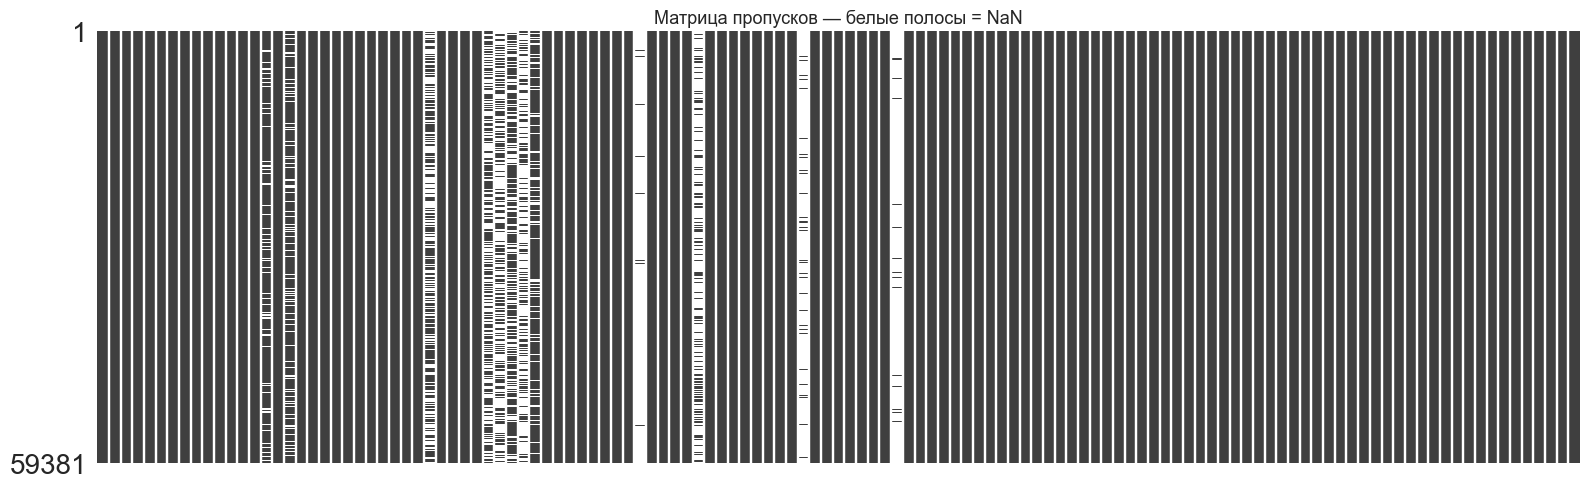

In [9]:
# Матрица пропусков (missingno)
msno.matrix(insurance_df, figsize=(16, 5), sparkline=False)
plt.title("Матрица пропусков — белые полосы = NaN", fontsize=13)
plt.tight_layout()
plt.show()

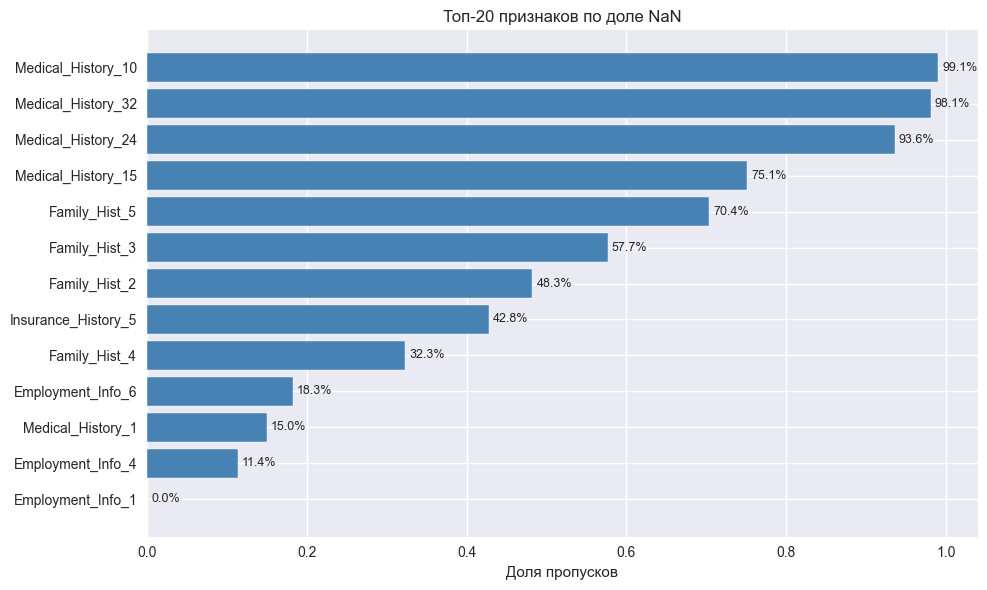

In [10]:
# Топ-20 колонок по доле NaN — горизонтальный bar chart
nan_frac = insurance_df.isnull().sum() / len(insurance_df)
nan_frac = nan_frac[nan_frac > 0].sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
bars = plt.barh(nan_frac.index, nan_frac.values, color="steelblue", edgecolor="white")
plt.xlabel("Доля пропусков")
plt.title("Топ-20 признаков по доле NaN")
plt.gca().invert_yaxis()
for bar, val in zip(bars, nan_frac.values):
    plt.text(
        val + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1%}",
        va="center",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

## 3. Преобразование атрибутов

Категориальные признаки (тип `object`) преобразуем через **One-Hot Encoding** с удалением первой
категории (`drop_first=True`) для устранения мультиколлинеарности.


In [11]:
categorical_cols = insurance_df.select_dtypes(include=["object"]).columns
print(
    f"Категориальные признаки ({len(categorical_cols)} шт.): {list(categorical_cols)}"
)

Категориальные признаки (1 шт.): ['Product_Info_2']


In [12]:
insurance_df_original = insurance_df.copy()
insurance_df = pd.get_dummies(insurance_df, columns=categorical_cols, drop_first=True)
print(f"Размерность после OHE: {insurance_df.shape}")
insurance_df.head()

Размерность после OHE: (59381, 144)


,Product_Info_1,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,Wt,BMI,Employment_Info_1,Employment_Info_2,Employment_Info_3,Employment_Info_4,Employment_Info_5,Employment_Info_6,InsuredInfo_1,InsuredInfo_2,InsuredInfo_3,InsuredInfo_4,InsuredInfo_5,InsuredInfo_6,InsuredInfo_7,Insurance_History_1,Insurance_History_2,Insurance_History_3,Insurance_History_4,Insurance_History_5,Insurance_History_7,Insurance_History_8,Insurance_History_9,Family_Hist_1,Family_Hist_2,Family_Hist_3,Family_Hist_4,Family_Hist_5,Medical_History_1,Medical_History_2,Medical_History_3,Medical_History_4,Medical_History_5,Medical_History_6,Medical_History_7,Medical_History_8,Medical_History_9,Medical_History_10,Medical_History_11,Medical_History_12,Medical_History_13,Medical_History_14,Medical_History_15,Medical_History_16,Medical_History_17,Medical_History_18,Medical_History_19,Medical_History_20,Medical_History_21,Medical_History_22,Medical_History_23,Medical_History_24,Medical_History_25,Medical_History_26,Medical_History_27,Medical_History_28,Medical_History_29,Medical_History_30,Medical_History_31,Medical_History_32,Medical_History_33,Medical_History_34,Medical_History_35,Medical_History_36,Medical_History_37,Medical_History_38,Medical_History_39,Medical_History_40,Medical_History_41,Medical_Keyword_1,Medical_Keyword_2,Medical_Keyword_3,Medical_Keyword_4,Medical_Keyword_5,Medical_Keyword_6,Medical_Keyword_7,Medical_Keyword_8,Medical_Keyword_9,Medical_Keyword_10,Medical_Keyword_11,Medical_Keyword_12,Medical_Keyword_13,Medical_Keyword_14,Medical_Keyword_15,Medical_Keyword_16,Medical_Keyword_17,Medical_Keyword_18,Medical_Keyword_19,Medical_Keyword_20,Medical_Keyword_21,Medical_Keyword_22,Medical_Keyword_23,Medical_Keyword_24,Medical_Keyword_25,Medical_Keyword_26,Medical_Keyword_27,Medical_Keyword_28,Medical_Keyword_29,Medical_Keyword_30,Medical_Keyword_31,Medical_Keyword_32,Medical_Keyword_33,Medical_Keyword_34,Medical_Keyword_35,Medical_Keyword_36,Medical_Keyword_37,Medical_Keyword_38,Medical_Keyword_39,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response,Product_Info_2_A2,Product_Info_2_A3,Product_Info_2_A4,Product_Info_2_A5,Product_Info_2_A6,Product_Info_2_A7,Product_Info_2_A8,Product_Info_2_B1,Product_Info_2_B2,Product_Info_2_C1,Product_Info_2_C2,Product_Info_2_C3,Product_Info_2_C4,Product_Info_2_D1,Product_Info_2_D2,Product_Info_2_D3,Product_Info_2_D4,Product_Info_2_E1
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,1,10,0.076923,2,1,1,0.641791,0.581818,0.148536,0.323008,0.028,12,1,0.0,3,NaN,1,2,6,3,1,2,1,1,1,3,1,0.000667,1,1,2,2,NaN,0.598039,NaN,0.526786,4.0,112,2,1,1,3,2,2,1,NaN,3,2,3,3,240.0,3,3,1,1,2,1,2,3,NaN,1,3,3,1,3,2,3,NaN,1,3,1,2,2,1,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
5,1,26,0.076923,2,3,1,0.059701,0.600000,0.131799,0.272288,0.000,1,3,0.0,2,0.0018,1,2,6,3,1,2,1,2,1,3,1,0.000133,1,3,2,2,0.188406,NaN,0.084507,NaN,5.0,412,2,1,1,3,2,2,1,NaN,3,2,3,3,0.0,1,3,1,1,2,1,2,3,NaN,1,3,3,1,3,2,3,NaN,3,1,1,2,2,1,3,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,1,26,0.076923,2,3,1,0.029851,0.745455,0.288703,0.428780,0.030,9,1,0.0,2,0.0300,1,2,8,3,1,1,1,2,1,1,3,NaN,3,2,3,3,0.304348,NaN,0.225352,NaN,10.0,3,2,2,1,3,2,2,2,NaN,3,2,3,3,NaN,1,3,1,1,2,1,2,3,NaN,2,2,3,1,3,2,3,NaN,3,3,1,3,2,1,3,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,False,False,False,False,False,False,False,False,False,False,False,False,False,F

## 4. Описательный анализ и корреляции

### 4.1 Целевая переменная

Смотрим на распределение исходного таргета и его бинаризованной версии.  
Дисбаланс классов влияет на выбор метрики (ROC-AUC предпочтительнее Accuracy).


Класс 0 (риск 1-7): 39892 (67.2%)
Класс 1 (наивысший, 8): 19489 (32.8%)
Дисбаланс: 2.0:1


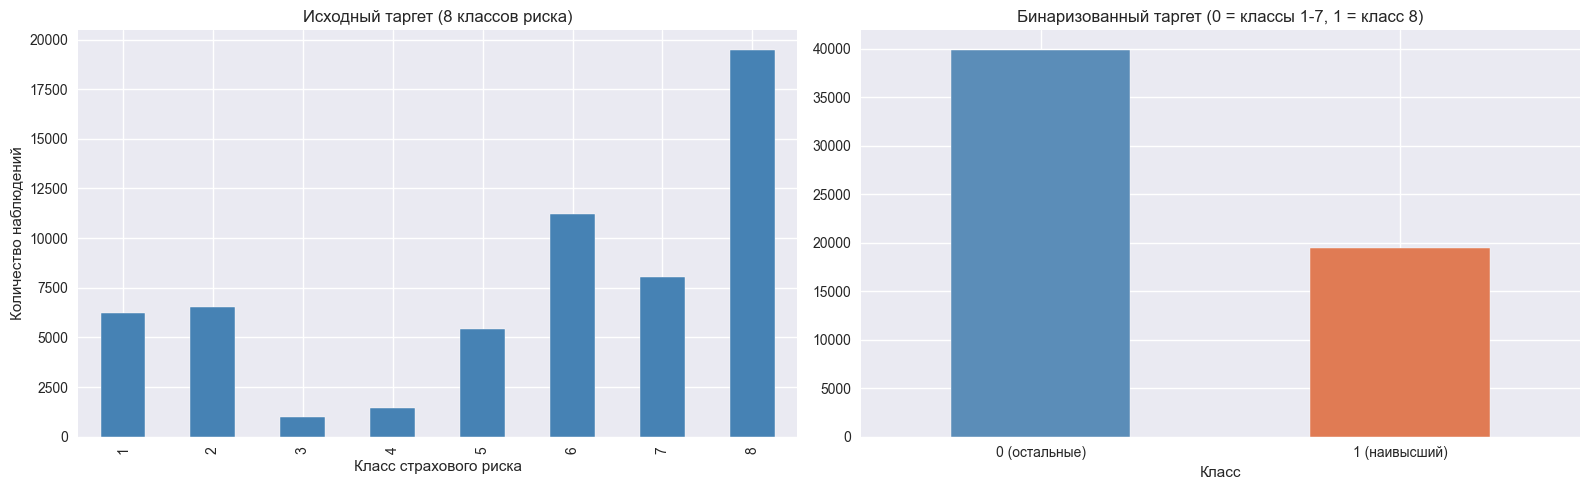

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

insurance_df_original["Response"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Исходный таргет (8 классов риска)")
axes[0].set_xlabel("Класс страхового риска")
axes[0].set_ylabel("Количество наблюдений")

resp_binary = insurance_df_original["Response"].apply(lambda x: 0 if x <= 7 else 1)
resp_binary.value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=["#5b8db8", "#e07b54"], edgecolor="white"
)
axes[1].set_title("Бинаризованный таргет (0 = классы 1-7, 1 = класс 8)")
axes[1].set_xlabel("Класс")
axes[1].set_xticklabels(["0 (остальные)", "1 (наивысший)"], rotation=0)

n0 = (resp_binary == 0).sum()
n1 = (resp_binary == 1).sum()
print(f"Класс 0 (риск 1-7): {n0} ({n0/len(resp_binary):.1%})")
print(f"Класс 1 (наивысший, 8): {n1} ({n1/len(resp_binary):.1%})")
print(f"Дисбаланс: {n0/n1:.1f}:1")

plt.tight_layout()
plt.show()

In [14]:
# Бинаризуем целевую переменную
insurance_df["Modified_Response"] = insurance_df["Response"].apply(
    lambda x: 0 if 0 <= x <= 7 else (1 if x == 8 else -1)
)
insurance_df.drop("Response", axis=1, inplace=True)
print("Modified_Response создан, Response удалён.")
print(insurance_df["Modified_Response"].value_counts())

Modified_Response создан, Response удалён.
Modified_Response
0    39892
1    19489
Name: count, dtype: int64


### 4.2 Распределение числовых признаков по классам

Ключевые числовые признаки (`Ins_Age`, `Ht`, `Wt`, `BMI`) анализируем раздельно для каждого класса —
это помогает понять, какие признаки наиболее информативны.


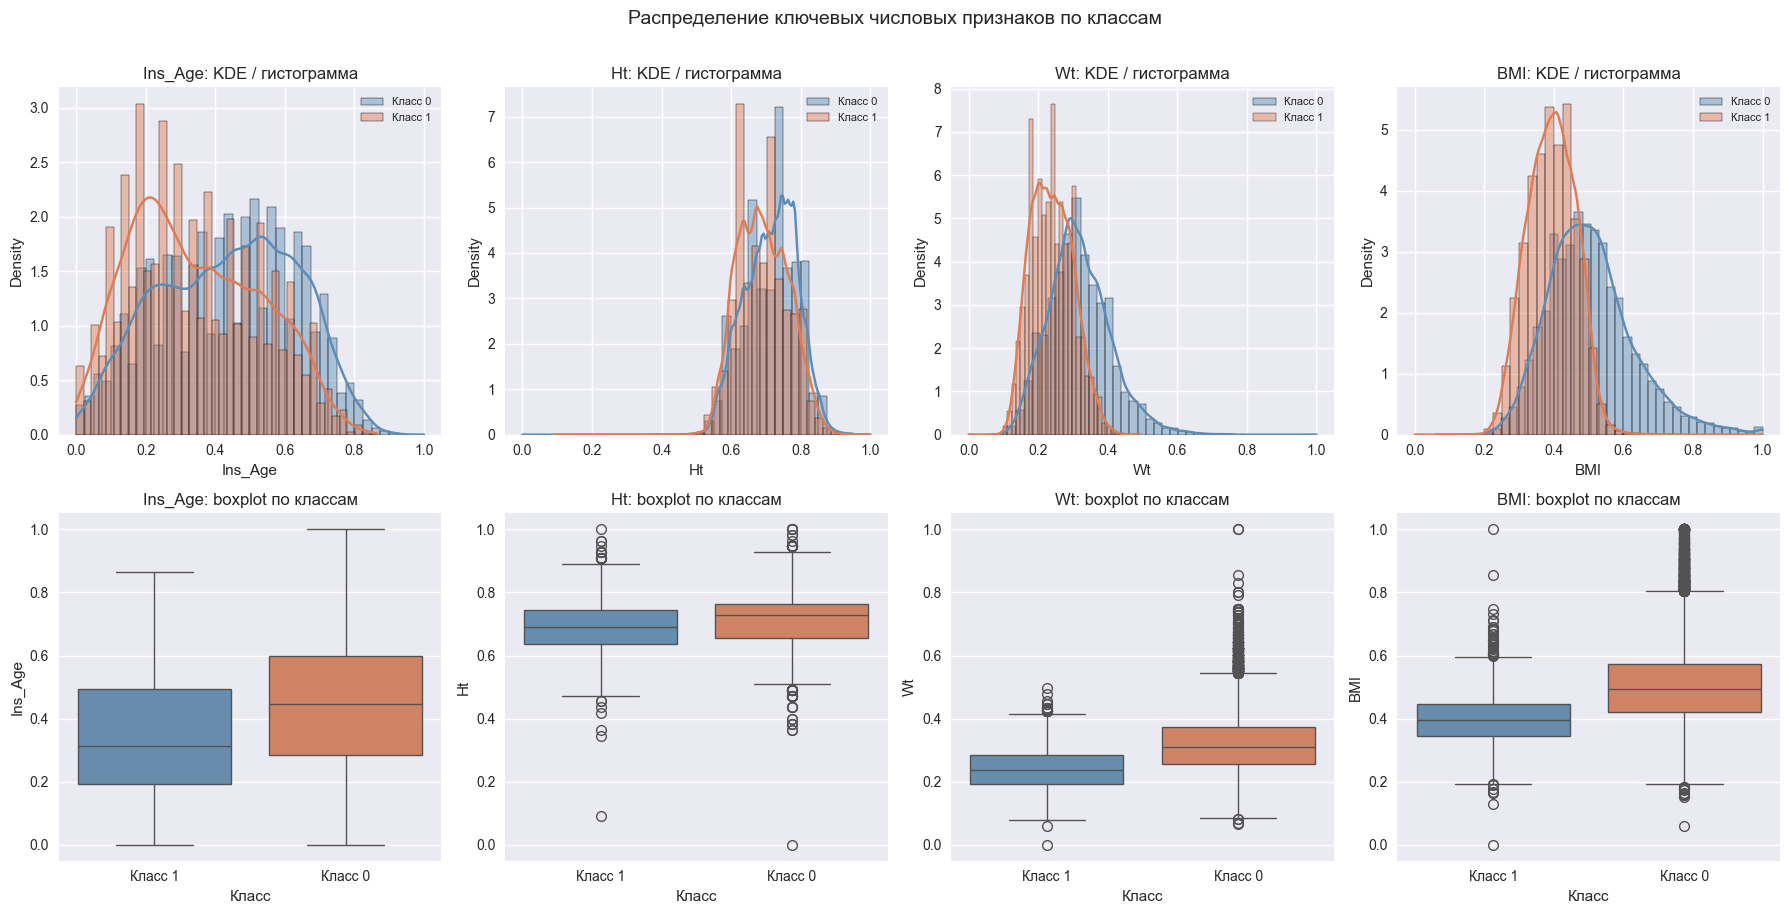

In [15]:
numerical_features = ["Ins_Age", "Ht", "Wt", "BMI"]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, feat in enumerate(numerical_features):
    if feat not in insurance_df.columns:
        continue

    # KDE + гистограмма
    ax_top = axes[0, i]
    for cls, color, label in [(0, "#5b8db8", "Класс 0"), (1, "#e07b54", "Класс 1")]:
        mask = insurance_df["Modified_Response"] == cls
        data = insurance_df.loc[mask, feat].dropna()
        sns.histplot(
            data,
            kde=True,
            ax=ax_top,
            color=color,
            label=label,
            stat="density",
            alpha=0.45,
            bins=40,
        )
    ax_top.set_title(f"{feat}: KDE / гистограмма")
    ax_top.legend(fontsize=8)

    # Boxplot
    ax_bot = axes[1, i]
    plot_data = insurance_df[[feat, "Modified_Response"]].dropna()
    plot_data = plot_data.copy()
    plot_data["Класс"] = plot_data["Modified_Response"].map(
        {0: "Класс 0", 1: "Класс 1"}
    )
    sns.boxplot(
        data=plot_data, x="Класс", y=feat, ax=ax_bot, palette=["#5b8db8", "#e07b54"]
    )
    ax_bot.set_title(f"{feat}: boxplot по классам")

plt.suptitle(
    "Распределение ключевых числовых признаков по классам", y=1.01, fontsize=14
)
plt.tight_layout()
plt.show()

### 4.3 Корреляции


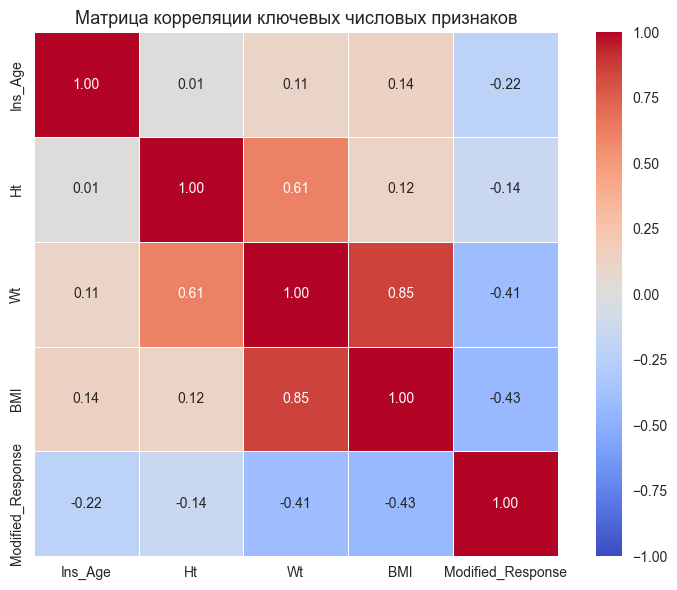

In [16]:
numerical_features_ext = ["Ins_Age", "Ht", "Wt", "BMI", "Modified_Response"]
corr_matrix = insurance_df[numerical_features_ext].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    vmin=-1,
    vmax=1,
)
plt.title("Матрица корреляции ключевых числовых признаков", fontsize=13)
plt.tight_layout()
plt.show()

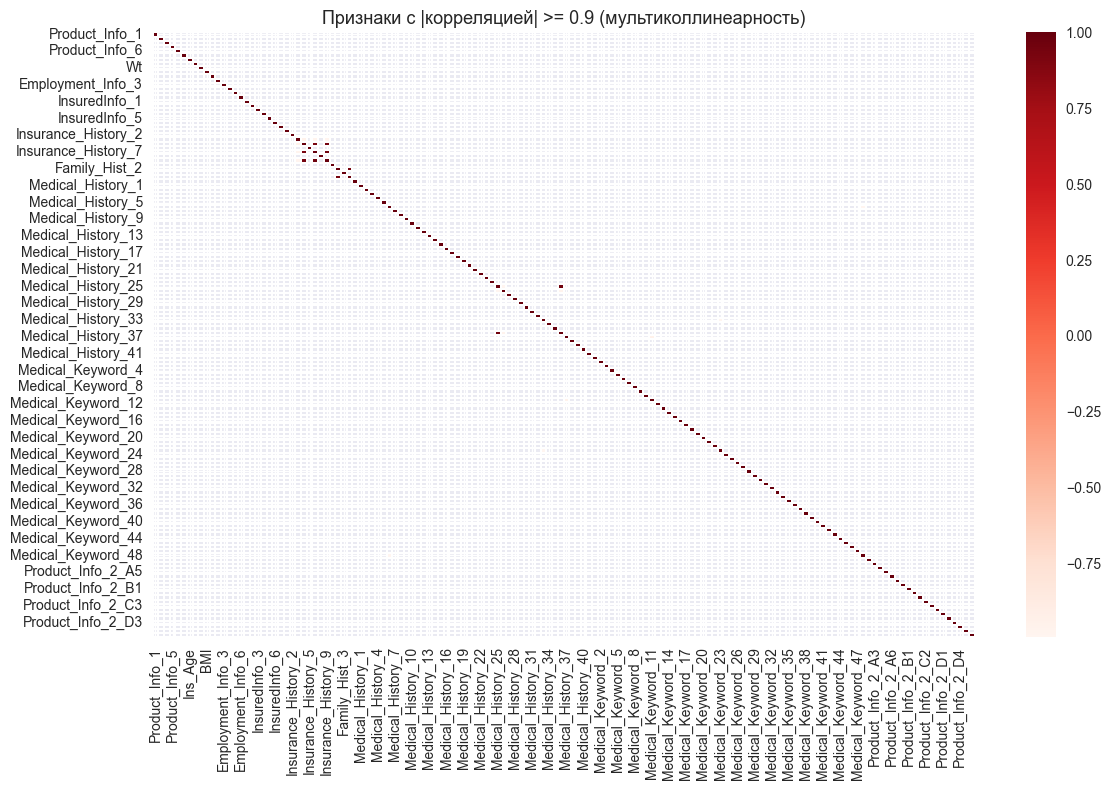

In [17]:
# Признаки с высокой корреляцией (>=0.9) — потенциальная мультиколлинеарность
corr_full = insurance_df.corr(numeric_only=True)
corr_high = corr_full[(corr_full.abs() >= 0.9)]

plt.figure(figsize=(12, 8))
sns.heatmap(corr_high, cmap="Reds", linewidths=0.1)
plt.title("Признаки с |корреляцией| >= 0.9 (мультиколлинеарность)", fontsize=13)
plt.tight_layout()
plt.show()

### 4.4 Обработка пропусков и очистка


In [18]:
missing_val_frac = insurance_df.isnull().sum() / len(insurance_df)
high_missing = missing_val_frac[missing_val_frac > 0.4].sort_values(ascending=False)
print("Колонки с >40% пропусков (удаляем):")
print(high_missing)

limit = int(insurance_df.shape[0] * 0.4)
insurance_df_cleaned = insurance_df.dropna(thresh=limit, axis=1)
print(f"\nУдалено колонок: {insurance_df.shape[1] - insurance_df_cleaned.shape[1]}")
print(f"Оставшаяся размерность: {insurance_df_cleaned.shape}")
insurance_df = insurance_df_cleaned

Колонки с >40% пропусков (удаляем):
Medical_History_10     0.990620
Medical_History_32     0.981358
Medical_History_24     0.935990
Medical_History_15     0.751015
Family_Hist_5          0.704114
Family_Hist_3          0.576632
Family_Hist_2          0.482579
Insurance_History_5    0.427679
dtype: float64

Удалено колонок: 5
Оставшаяся размерность: (59381, 139)


In [19]:
X = insurance_df.drop(columns=["Modified_Response"], errors="ignore")
Y = insurance_df["Modified_Response"]

# Заполняем оставшиеся пропуски медианой (устойчиво к выбросам)
X = X.fillna(X.median())

print(f"X: {X.shape} | Y: {Y.shape}")
print(f"Пропуски в X после заполнения медианой: {X.isnull().sum().sum()}")

X: (59381, 138) | Y: (59381,)
Пропуски в X после заполнения медианой: 0


## 5. Методы без учителя: аномалии и понижение размерности

### 5.1 Обнаружение аномалий — Isolation Forest

`IsolationForest` изолирует аномальные наблюдения путём случайного разбиения признаков.  
Задаём `contamination=0.02` — ожидаем ≈2% аномалий.


In [20]:
iso_forest = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)
anomaly_labels = iso_forest.fit_predict(X)

X_clean = X[anomaly_labels == 1]
Y_clean = Y[anomaly_labels == 1]

print(f"Исходных строк:    {X.shape[0]}")
print(
    f"Удалено аномалий:  {X.shape[0] - X_clean.shape[0]}  ({(X.shape[0] - X_clean.shape[0])/X.shape[0]:.1%})"
)
print(f"Осталось строк:    {X_clean.shape[0]}")

Исходных строк:    59381
Удалено аномалий:  1188  (2.0%)
Осталось строк:    58193


### 5.2 Снижение размерности — PCA

**PCA** проецирует данные на главные компоненты с максимальной дисперсией.  
Визуализация в 2D позволяет оценить, насколько классы линейно разделимы.


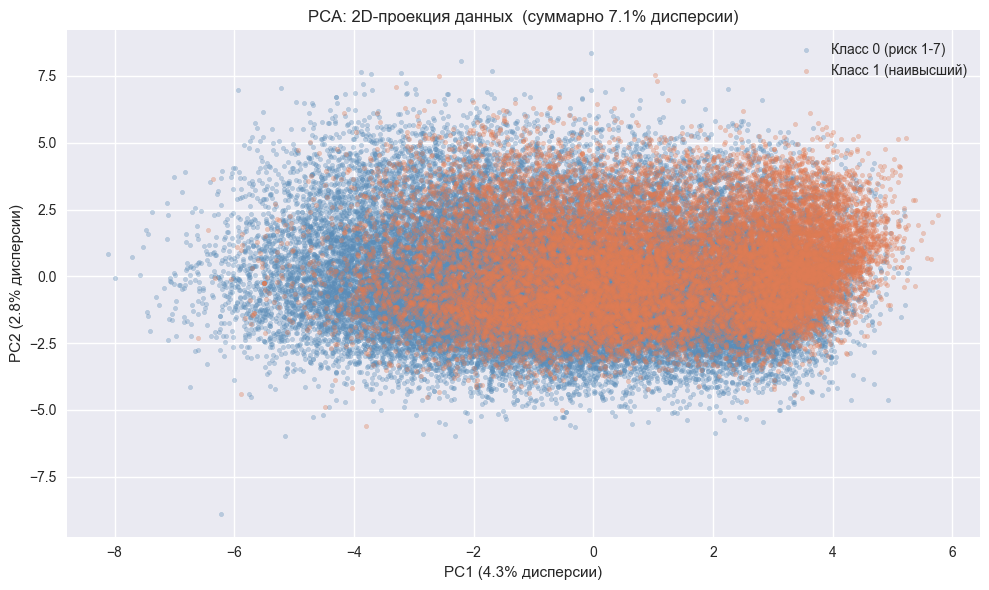

Вывод: классы частично перекрываются — задача нелинейная, деревья предпочтительны.


In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
for cls, color, label in [
    (0, "#5b8db8", "Класс 0 (риск 1-7)"),
    (1, "#e07b54", "Класс 1 (наивысший)"),
]:
    mask = Y_clean.values == cls
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, alpha=0.35, s=10, label=label)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} дисперсии)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} дисперсии)")
total_var = pca.explained_variance_ratio_.sum()
plt.title(f"PCA: 2D-проекция данных  (суммарно {total_var:.1%} дисперсии)")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Вывод: классы частично перекрываются — задача нелинейная, деревья предпочтительны."
)

### 5.3 Снижение размерности — t-SNE

**t-SNE** сохраняет локальную структуру данных, визуализируя нелинейные кластеры.  
Для скорости работаем на случайном сэмпле 2000 точек.


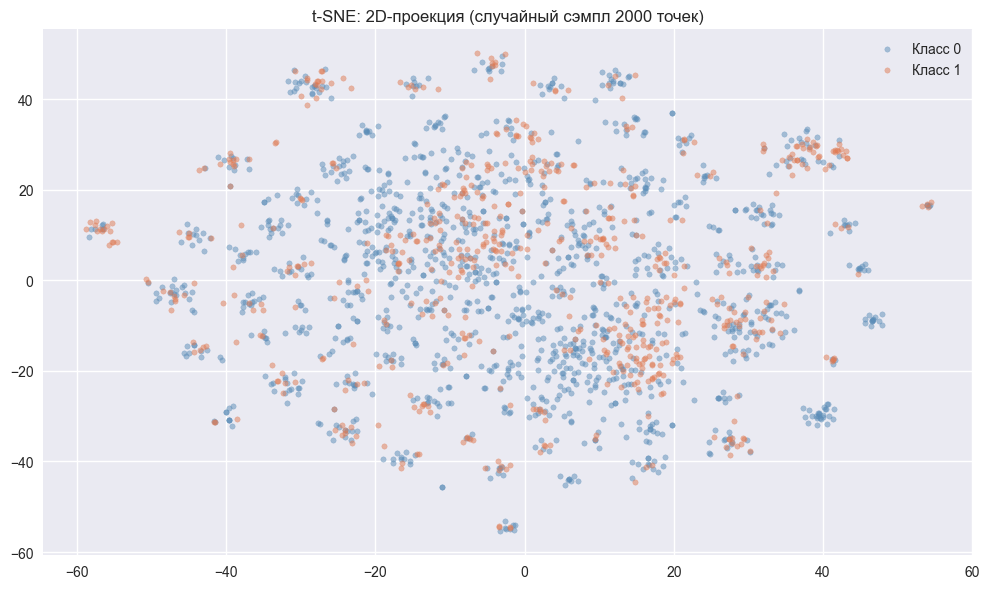

In [22]:
sample_idx = np.random.choice(len(X_clean), size=min(2000, len(X_clean)), replace=False)
X_sample = X_scaled[sample_idx]
Y_sample = Y_clean.values[sample_idx]

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    n_iter_without_progress=500,
    init="pca",
)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10, 6))
for cls, color, label in [(0, "#5b8db8", "Класс 0"), (1, "#e07b54", "Класс 1")]:
    mask = Y_sample == cls
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, alpha=0.5, s=15, label=label)
plt.title("t-SNE: 2D-проекция (случайный сэмпл 2000 точек)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Разделение на обучающую и тестовую выборки

Стратегия: **случайное стратифицированное разделение** 75 / 25.  
`stratify=Y_clean` гарантирует одинаковое соотношение классов в обеих выборках.


In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_clean, Y_clean, test_size=0.25, random_state=1, stratify=Y_clean
)

# Numpy-версии Y для совместимости со sklearn и NODE
Y_train_np = Y_train.values.astype(np.int64)
Y_test_np = Y_test.values.astype(np.int64)

print(f"Train: X={X_train.shape}, Y={Y_train.shape}")
print(f"Test:  X={X_test.shape},  Y={Y_test.shape}")
print()
print(
    f"Баланс классов в train: {dict(zip(*np.unique(Y_train_np, return_counts=True)))}"
)
print(
    f"Баланс классов в test:  {dict(zip(*np.unique(Y_test_np,  return_counts=True)))}"
)

Train: X=(43644, 138), Y=(43644,)
Test:  X=(14549, 138),  Y=(14549,)

Баланс классов в train: {np.int64(0): np.int64(29079), np.int64(1): np.int64(14565)}
Баланс классов в test:  {np.int64(0): np.int64(9694), np.int64(1): np.int64(4855)}


## Утилиты (вспомогательные функции)

Набор функций используется во всех разделах:

| Функция                   | Назначение                                           |
| ------------------------- | ---------------------------------------------------- |
| `compute_metrics`         | Вычисляет метрики, заполняет глобальные регистры     |
| `plot_confusion_matrices` | Тепловые карты матриц ошибок train/test              |
| `plot_roc_pr_for_model`   | ROC + PR кривые для одной модели                     |
| `plot_proba_distribution` | Гистограмма предсказанных вероятностей по классам    |
| `plot_feature_importance` | Горизонтальный bar chart важности признаков          |
| `plot_learning_curve_for` | Learning curve (train/val ROC-AUC vs размер выборки) |
| `shap_summary`            | SHAP summary + dependence plots                      |
| `interpret`               | Оркестрирует весь pipeline интерпретации             |


In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# UTILITY FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════


def _get_proba(model, X, proba_col=1):
    """Универсальное извлечение P(class=1) для бинарной задачи.
    Обрабатывает: sklearn (n,2), CatBoost (n,2), NODE (n,1), 1-D arrays.
    """
    raw = model.predict_proba(X)
    if raw.ndim == 2 and raw.shape[1] == 1:
        return raw[:, 0]  # NODE: sigmoid output, 1 столбец = P(class=1)
    if raw.ndim == 1:
        return raw
    return raw[:, proba_col]  # sklearn/XGB/CatBoost: нужен столбец 1


def compute_metrics(model, X_train, X_test, Y_train, Y_test, name, proba_col=1):
    """
    Вычисляет полный набор метрик и регистрирует их в глобальных словарях.
    Возвращает словарь метрик.
    """
    train_proba = _get_proba(model, X_train, proba_col)
    test_proba = _get_proba(model, X_test, proba_col)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    m = {
        "train_roc": roc_auc_score(Y_train, train_proba),
        "test_roc": roc_auc_score(Y_test, test_proba),
        "train_accuracy": accuracy_score(Y_train, train_pred),
        "test_accuracy": accuracy_score(Y_test, test_pred),
        "train_logloss": log_loss(Y_train, train_proba),
        "test_logloss": log_loss(Y_test, test_proba),
        "f1": f1_score(Y_test, test_pred, zero_division=0),
        "precision": precision_score(Y_test, test_pred, zero_division=0),
        "recall": recall_score(Y_test, test_pred, zero_division=0),
    }

    fpr, tpr, _ = roc_curve(Y_test, test_proba)
    prec_arr, rec_arr, _ = precision_recall_curve(Y_test, test_proba)
    ap = average_precision_score(Y_test, test_proba)

    RESULTS[name] = m
    ROC_CURVES[name] = (fpr, tpr, m["test_roc"])
    PR_CURVES[name] = (prec_arr, rec_arr, ap)
    PROBA_CACHE[name] = test_proba

    sep = "=" * 57
    print(sep)
    print("  Модель: " + name)
    print(sep)
    print("  {:<26} {:>9} {:>9}".format("Метрика", "Train", "Test"))
    print("  " + "-" * 45)
    print("  {:<26} {:>9.4f} {:>9.4f}".format("ROC-AUC", m["train_roc"], m["test_roc"]))
    print(
        "  {:<26} {:>9.4f} {:>9.4f}".format(
            "Accuracy", m["train_accuracy"], m["test_accuracy"]
        )
    )
    print(
        "  {:<26} {:>9.4f} {:>9.4f}".format(
            "Log Loss", m["train_logloss"], m["test_logloss"]
        )
    )
    print("  " + "-" * 45)
    print("  {:<26} {:>9.4f}".format("F1-score (test)", m["f1"]))
    print("  {:<26} {:>9.4f}".format("Precision (test)", m["precision"]))
    print("  {:<26} {:>9.4f}".format("Recall (test)", m["recall"]))
    print(sep)
    return m


def plot_confusion_matrices(model, X_train, X_test, Y_train, Y_test, name):
    """Тепловые карты матриц ошибок (train и test).
    Каждая ячейка показывает: абсолютное число + процент строки (нормировка по факту).
    """
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, y_true, y_pred, split in [
        (axes[0], Y_train, train_pred, "Train"),
        (axes[1], Y_test, test_pred, "Test"),
    ]:
        cm = confusion_matrix(y_true, y_pred)
        cm_norm = confusion_matrix(y_true, y_pred, normalize="true")
        labels = [
            ["{}({:.1%})".format(v, p) for v, p in zip(row_c, row_n)]
            for row_c, row_n in zip(cm, cm_norm)
        ]
        sns.heatmap(
            cm,
            annot=labels,
            fmt="",
            cmap="Blues",
            ax=ax,
            xticklabels=["0", "1"],
            yticklabels=["0", "1"],
            linewidths=0.5,
        )
        ax.set_xlabel("Предсказанный класс")
        ax.set_ylabel("Истинный класс")
        acc = accuracy_score(y_true, y_pred)
        ax.set_title("{} — {}   Acc: {:.4f}".format(name, split, acc))

    plt.suptitle("Confusion Matrix: " + name, y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_roc_pr_for_model(name):
    """Per-model: ROC-кривая + Precision-Recall кривая на тестовой выборке."""
    fpr, tpr, roc_auc_val = ROC_CURVES[name]
    prec_arr, rec_arr, ap = PR_CURVES[name]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(
        fpr, tpr, lw=2, color="#2c7bb6", label="AUC = {:.4f}".format(roc_auc_val)
    )
    axes[0].plot(
        [0, 1], [0, 1], "--", color="gray", alpha=0.5, label="Случайная модель"
    )
    axes[0].fill_between(fpr, tpr, alpha=0.08, color="#2c7bb6")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC-кривая: " + name)
    axes[0].legend()

    axes[1].plot(
        rec_arr, prec_arr, lw=2, color="#d7191c", label="AP = {:.4f}".format(ap)
    )
    baseline = np.asarray(list(PROBA_CACHE.get(name, [0.5]))).mean()
    axes[1].axhline(
        np.mean(Y_test_np), ls="--", color="gray", alpha=0.5, label="Baseline"
    )
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall: " + name)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_proba_distribution(name):
    """Гистограмма предсказанных вероятностей по классам — визуализирует разделимость."""
    test_proba = PROBA_CACHE[name]
    y_arr = Y_test_np

    plt.figure(figsize=(9, 4))
    for cls, color, label in [(0, "#5b8db8", "Класс 0"), (1, "#e07b54", "Класс 1")]:
        mask = y_arr == cls
        sns.histplot(
            test_proba[mask],
            bins=50,
            stat="density",
            alpha=0.5,
            color=color,
            label=label,
            kde=True,
        )
    plt.axvline(0.5, ls="--", color="black", alpha=0.7, label="Порог = 0.5")
    plt.xlabel("Предсказанная вероятность P(класс=1)")
    plt.ylabel("Плотность")
    plt.title("Распределение предсказанных вероятностей: " + name)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_feature_importance(values, features, title, top_n=20):
    """Горизонтальный bar chart важности признаков (top_n)."""
    imp_df = pd.DataFrame({"Feature": list(features), "Importance": np.asarray(values)})
    imp_df = (
        imp_df[imp_df["Importance"] > 0]
        .sort_values("Importance", ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(10, max(4, len(imp_df) * 0.38)))
    sns.barplot(data=imp_df, y="Feature", x="Importance", orient="h", palette="Blues_d")
    plt.title(title, fontsize=13)
    plt.xlabel("Важность")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
    return imp_df


def plot_learning_curve_for(model, name, X, Y, cv=3, n_points=5):
    """Learning curve: Train / Val ROC-AUC vs размер обучающей выборки."""
    train_sizes, train_sc, val_sc = learning_curve(
        model,
        X,
        Y,
        train_sizes=np.linspace(0.1, 1.0, n_points),
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        shuffle=True,
        random_state=42,
    )
    plt.figure(figsize=(9, 5))
    plt.plot(
        train_sizes, train_sc.mean(1), "o-", color="#2c7bb6", label="Train ROC-AUC"
    )
    plt.fill_between(
        train_sizes,
        train_sc.mean(1) - train_sc.std(1),
        train_sc.mean(1) + train_sc.std(1),
        alpha=0.12,
        color="#2c7bb6",
    )
    plt.plot(
        train_sizes, val_sc.mean(1), "s-", color="#d7191c", label="Val ROC-AUC (CV)"
    )
    plt.fill_between(
        train_sizes,
        val_sc.mean(1) - val_sc.std(1),
        val_sc.mean(1) + val_sc.std(1),
        alpha=0.12,
        color="#d7191c",
    )
    plt.xlabel("Размер обучающей выборки")
    plt.ylabel("ROC-AUC")
    plt.title("Learning Curve: " + name)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def shap_summary(model, X_train, top_feature_names):
    """SHAP summary plot + dependence plots для топ признаков (TreeExplainer)."""
    try:
        X_train = pd.DataFrame(X_train).sample(n=1500, random_state=42)

        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_train, check_additivity=False)

        if len(shap_values.values.shape) == 3:
            plot_values = shap_values[:, :, 1]
            dep_values = shap_values[..., 1].values
        else:
            plot_values = shap_values
            dep_values = shap_values.values

        plt.figure(figsize=(10, 6))
        shap.summary_plot(plot_values, X_train, max_display=15, show=False)
        plt.title("SHAP Summary — " + type(model).__name__, fontsize=13, pad=15)
        plt.tight_layout()
        plt.show()

        for feat in list(top_feature_names)[:3]:
            if feat in list(X_train.columns):
                shap.dependence_plot(
                    feat,
                    dep_values,
                    X_train,
                    feature_names=list(X_train.columns),
                    show=False,
                )
                plt.title("SHAP Dependence: " + feat)
                plt.tight_layout()
                plt.show()
    except Exception as exc:
        print("SHAP недоступен: " + str(exc))


def interpret(
    model,
    name,
    X_train,
    X_test,
    Y_train,
    Y_test,
    proba_col=1,
    skip_shap=False,
    skip_importance=False,
):
    """
    Полная интерпретация модели:
    compute_metrics → confusion matrix → ROC/PR → proba distribution
    → feature importance → SHAP.
    """
    compute_metrics(model, X_train, X_test, Y_train, Y_test, name, proba_col)
    plot_confusion_matrices(model, X_train, X_test, Y_train, Y_test, name)
    plot_roc_pr_for_model(name)
    plot_proba_distribution(name)

    if not skip_importance:
        if hasattr(model, "feature_importances_"):
            imp_df = plot_feature_importance(
                model.feature_importances_,
                X_train.columns,
                "Важность признаков: " + name,
            )
            if not skip_shap:
                shap_summary(model, X_train, imp_df["Feature"].head(5).values)
        elif hasattr(model, "coef_"):
            coef_abs = np.abs(model.coef_[0])
            plot_feature_importance(
                coef_abs,
                X_train.columns,
                "|Коэффициенты| Logistic Regression: " + name,
            )


print("Утилиты загружены.")

Утилиты загружены.


## 7. Обучение моделей и интерпретация

### 7.1 Decision Tree

**Решающее дерево** — базовая линия. Легко интерпретируется, но склонно к переобучению.  
`max_depth=8` — ограничиваем глубину для контроля сложности.


In [26]:
dt_model = DecisionTreeClassifier(max_depth=8, min_samples_leaf=30, random_state=1)
dt_model.fit(X_train, Y_train)
print("Decision Tree обучено.")
print(f"Глубина: {dt_model.get_depth()}, листьев: {dt_model.get_n_leaves()}")

Decision Tree обучено.
Глубина: 8, листьев: 156


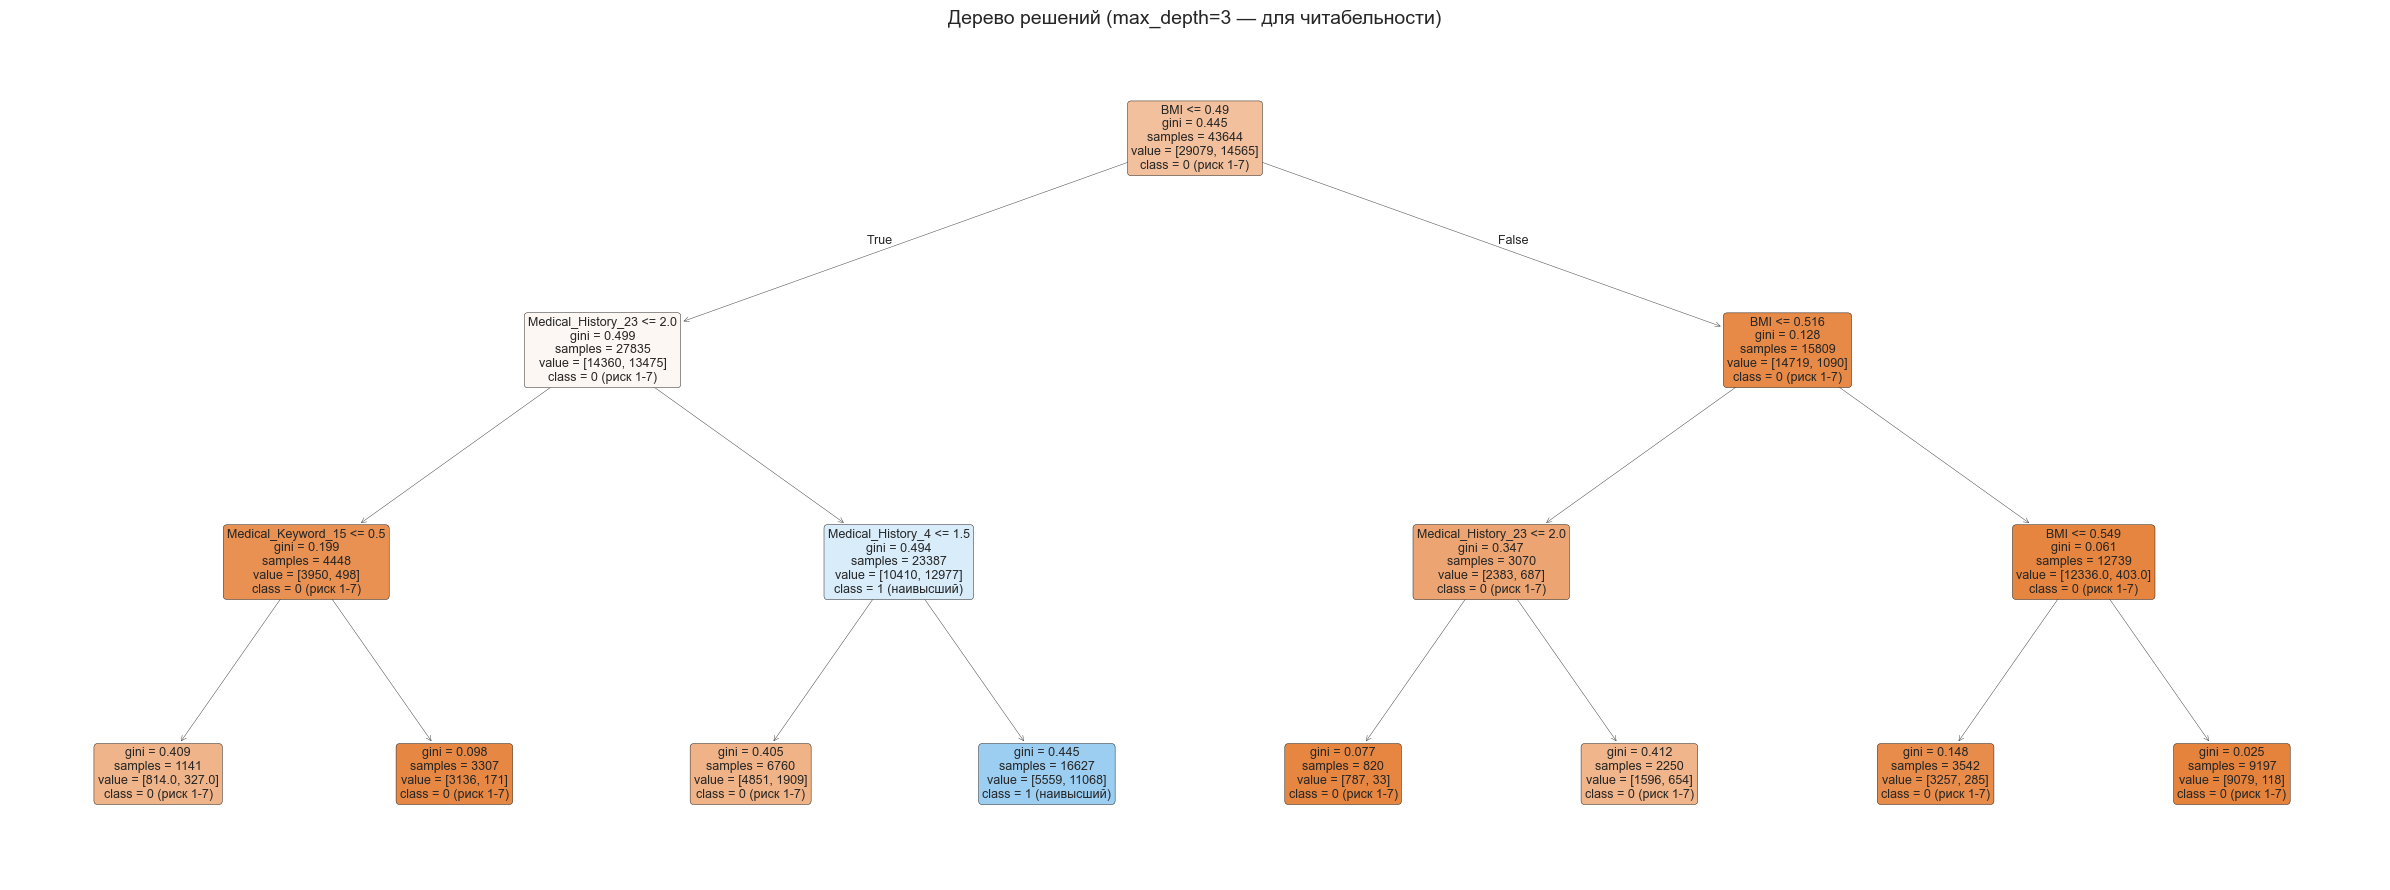

In [27]:
# Визуализируем дерево, ограниченное глубиной 3, для наглядности
dt_shallow = DecisionTreeClassifier(max_depth=3, min_samples_leaf=30, random_state=1)
dt_shallow.fit(X_train, Y_train)

fig, ax = plt.subplots(figsize=(24, 9))
plot_tree(
    dt_shallow,
    feature_names=list(X_train.columns),
    class_names=["0 (риск 1-7)", "1 (наивысший)"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
)
plt.title("Дерево решений (max_depth=3 — для читабельности)", fontsize=14)
plt.tight_layout()
plt.show()

  Модель: Decision Tree
  Метрика                        Train      Test
  ---------------------------------------------
  ROC-AUC                       0.8887    0.8791
  Accuracy                      0.8134    0.8098
  Log Loss                      0.3805    0.4488
  ---------------------------------------------
  F1-score (test)               0.7293
  Precision (test)              0.6946
  Recall (test)                 0.7677


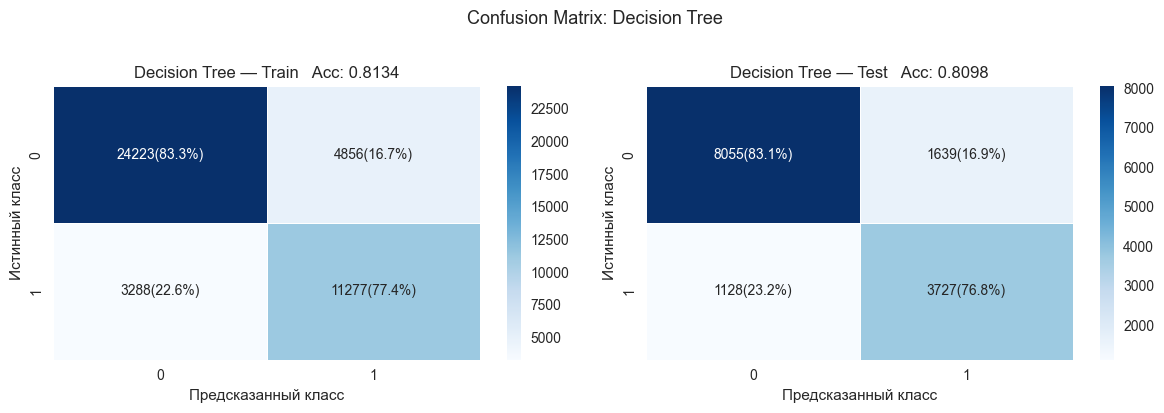

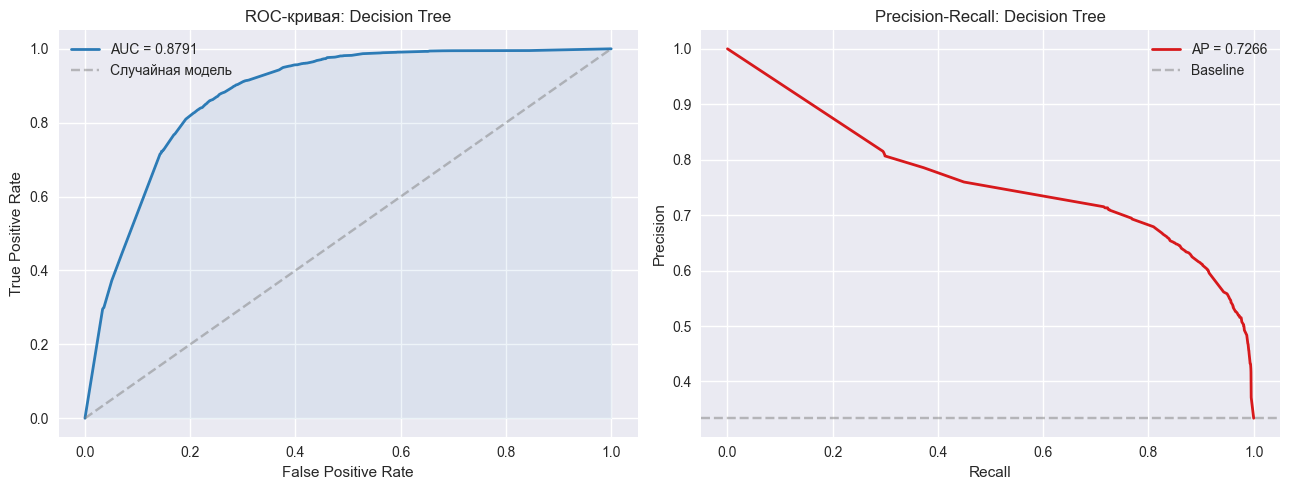

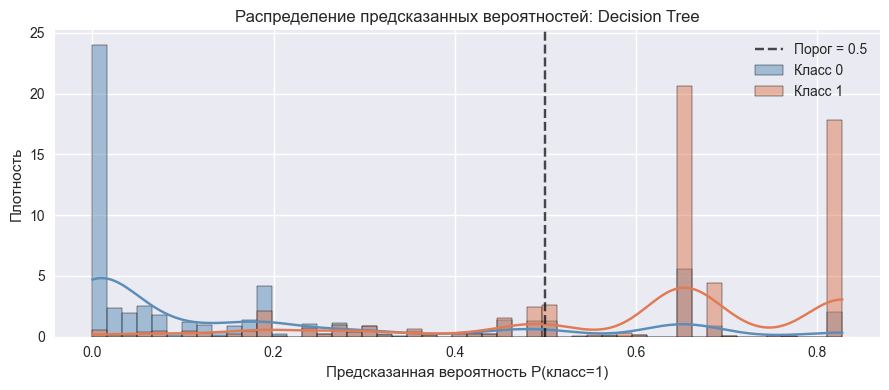

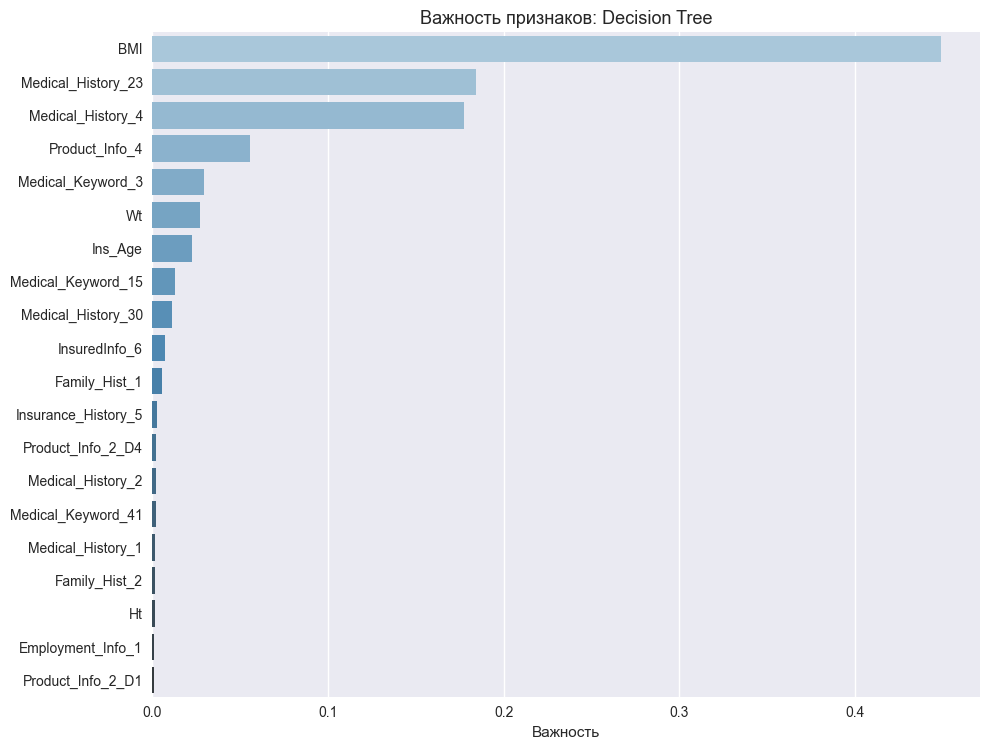

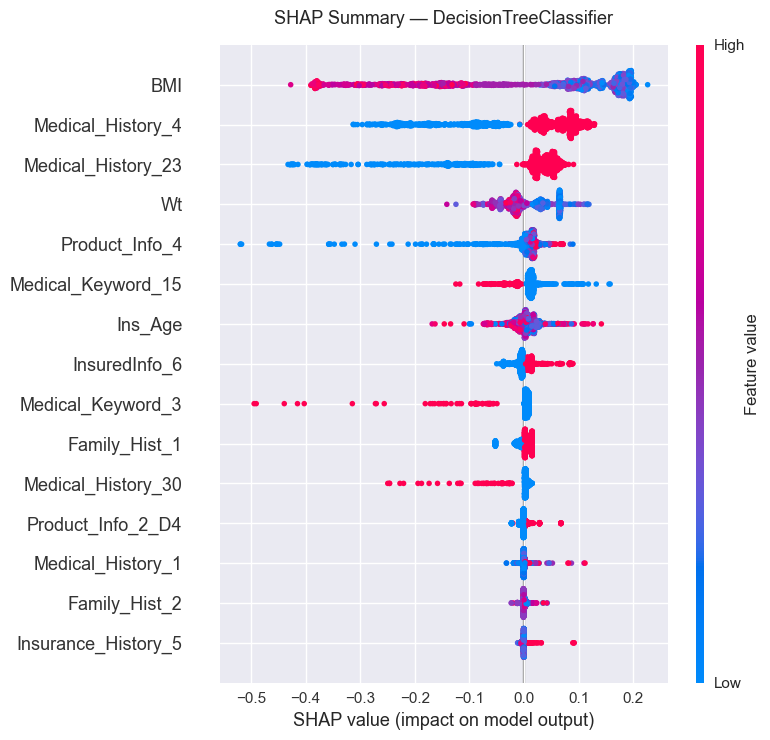

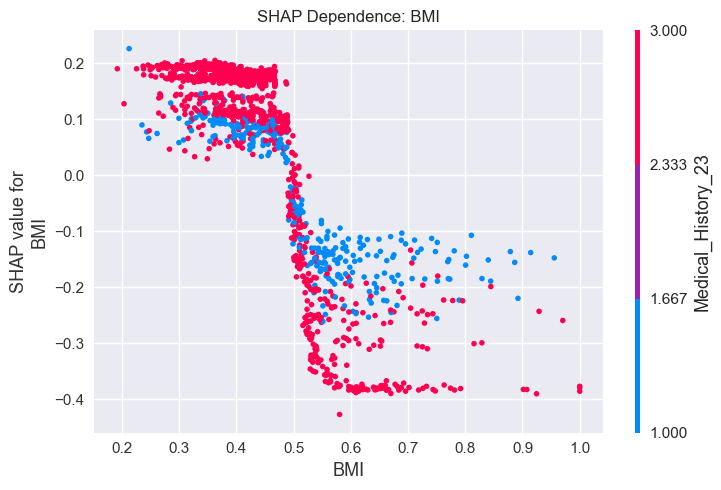

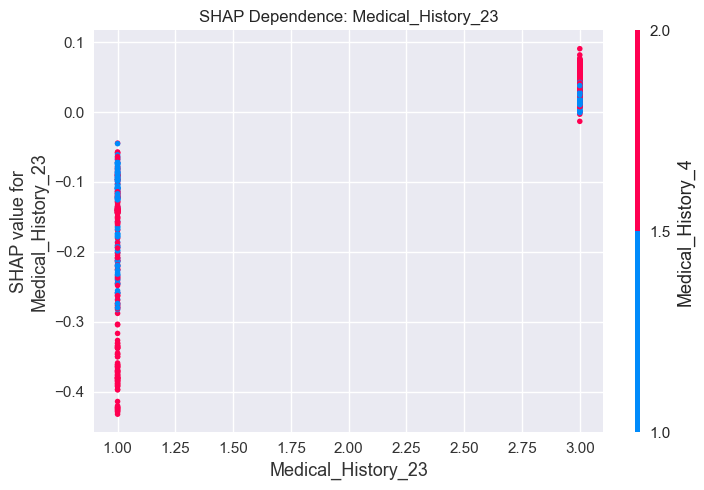

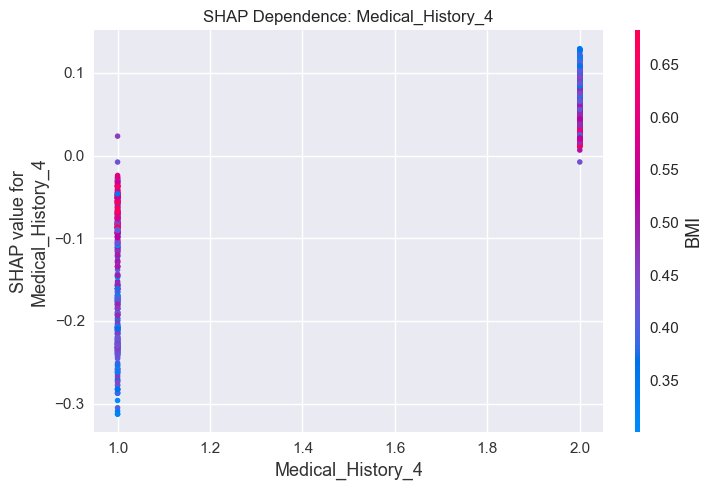

In [28]:
interpret(dt_model, "Decision Tree", X_train, X_test, Y_train, Y_test)

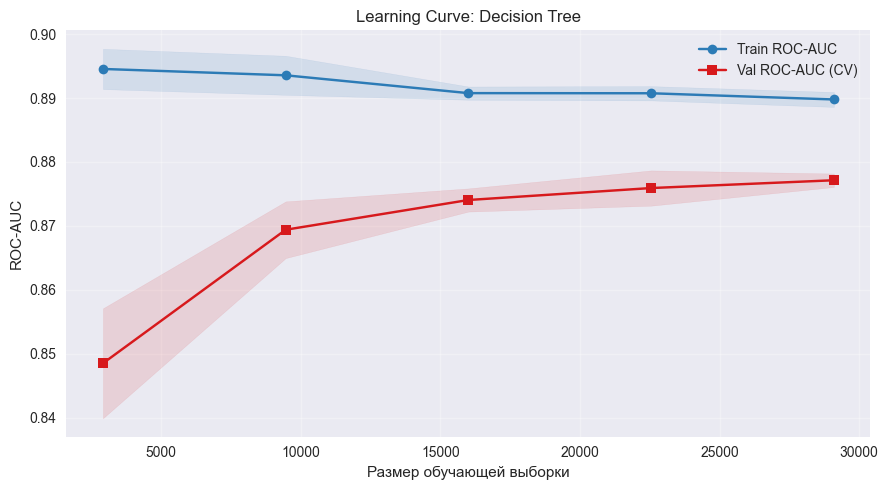

In [29]:
plot_learning_curve_for(
    DecisionTreeClassifier(max_depth=8, min_samples_leaf=30, random_state=1),
    "Decision Tree",
    X_train,
    Y_train_np,
)

**Вывод:** Одиночное дерево демонстрирует высокое переобучение (train ROC >> test ROC).
Learning curve подтверждает: с ростом данных тест-метрика улучшается, но существенно
отстаёт от тренировочной — характерный признак high variance модели.


### 7.2 Random Forest

**Случайный лес** усредняет предсказания множества деревьев, что снижает дисперсию.
Случайный выбор признаков при каждом разбиении (`max_features`) добавляет декорреляцию деревьев.


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=1, n_jobs=-1
)


rf_model.fit(X_train, Y_train)


print("Random Forest обучен:", rf_model.n_estimators, "деревьев.")

Random Forest обучен: 100 деревьев.


  Модель: Random Forest
  Метрика                        Train      Test
  ---------------------------------------------
  ROC-AUC                       0.9110    0.8926
  Accuracy                      0.8274    0.8131
  Log Loss                      0.3975    0.4169
  ---------------------------------------------
  F1-score (test)               0.7032
  Precision (test)              0.7480
  Recall (test)                 0.6634


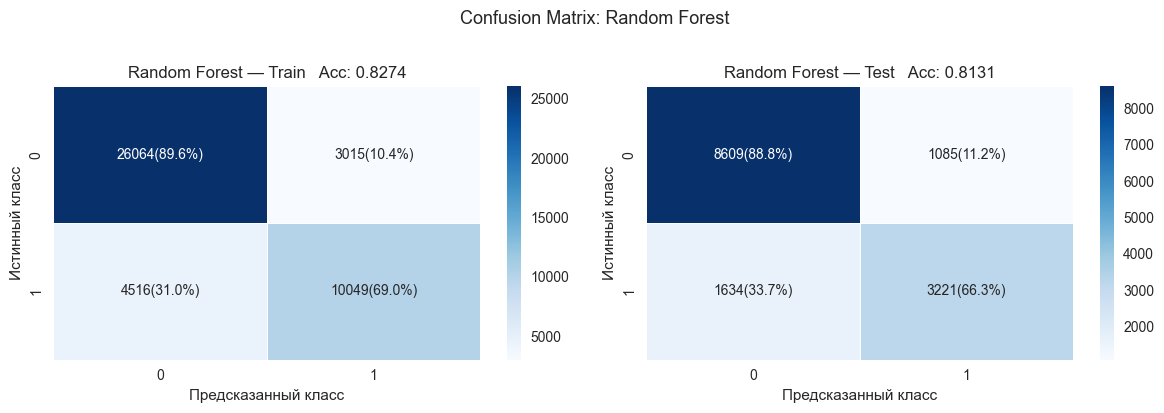

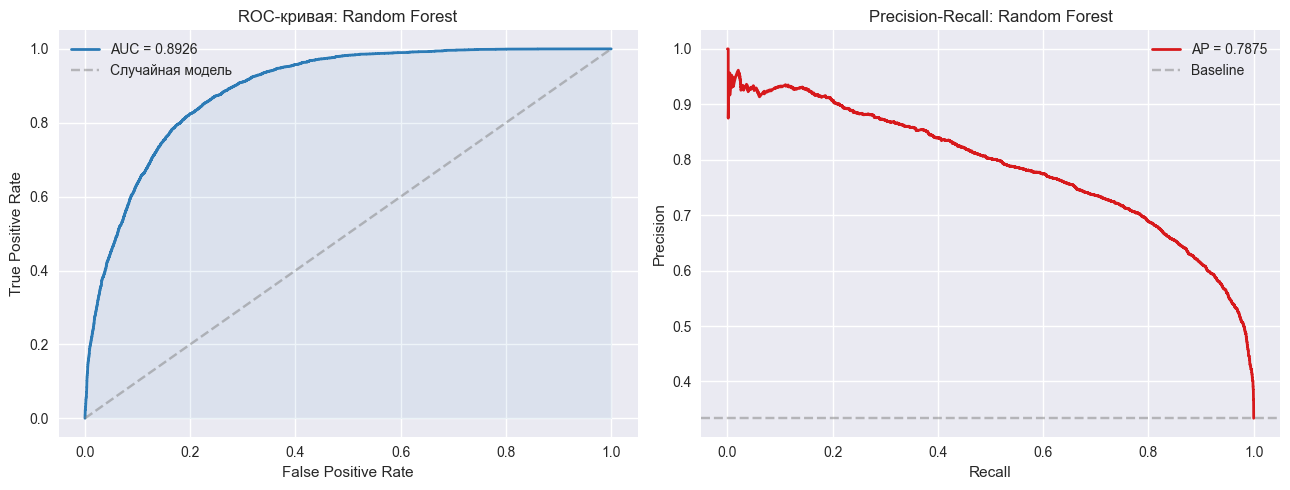

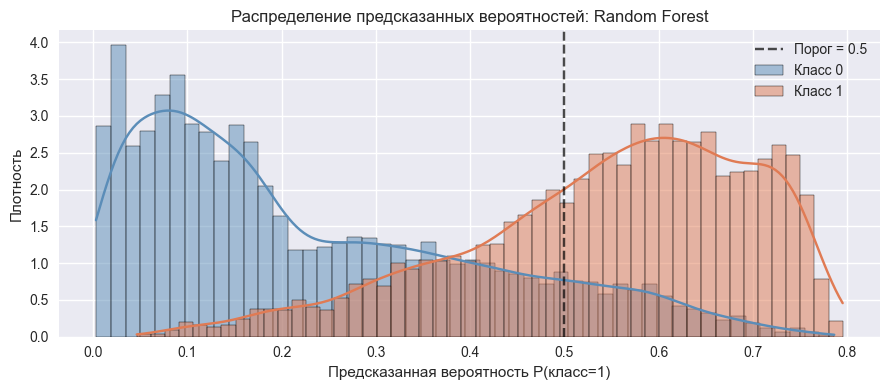

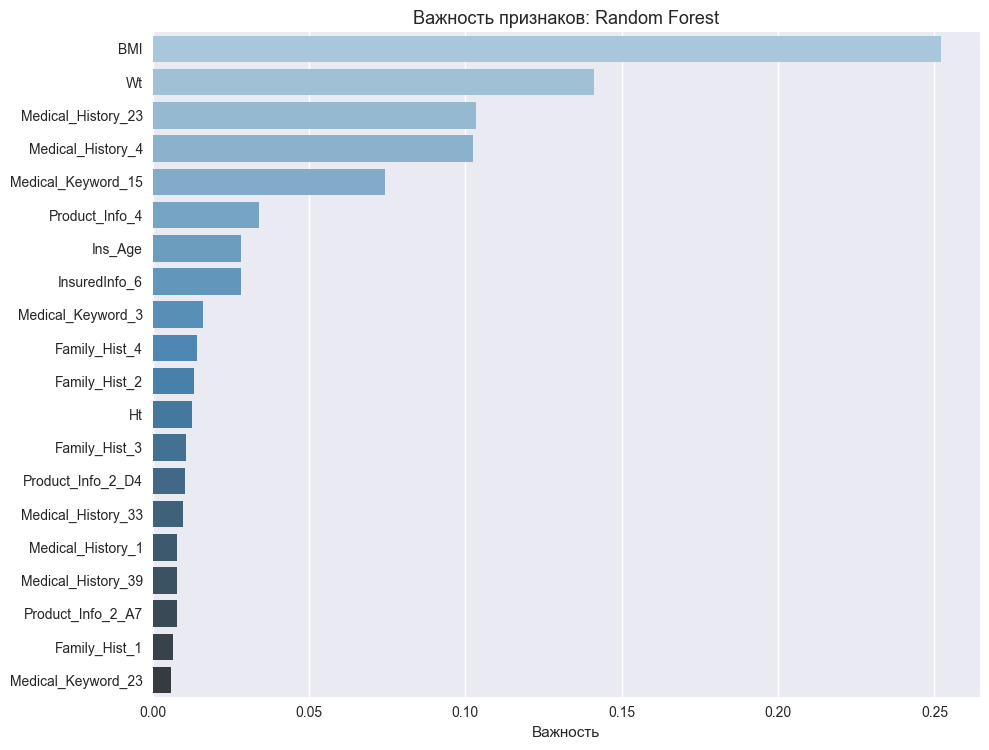

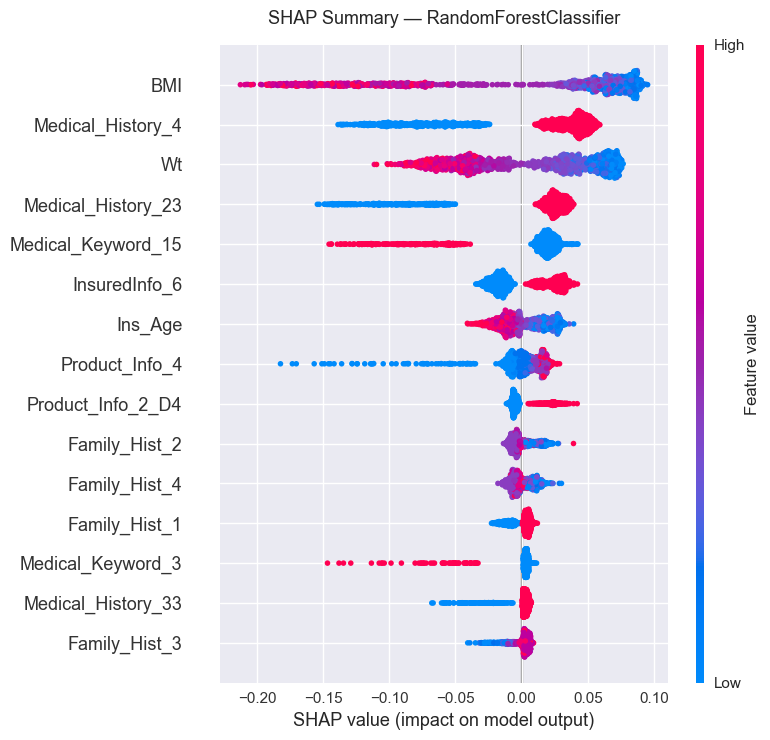

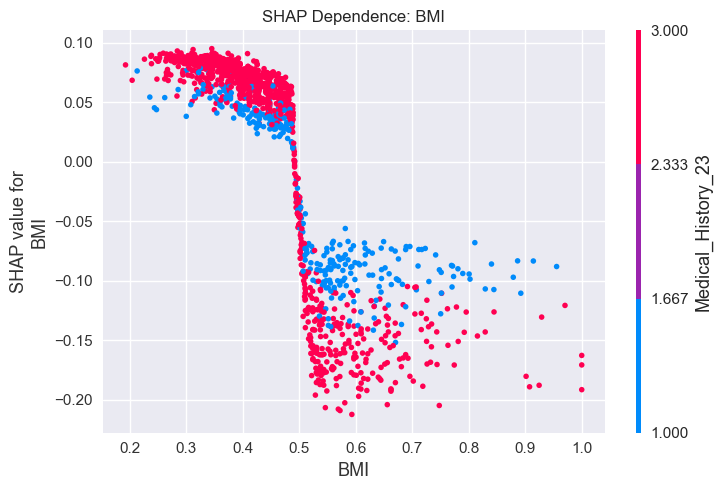

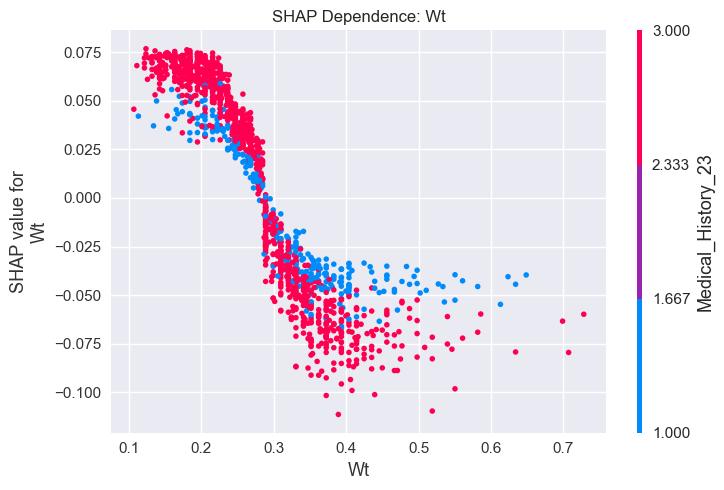

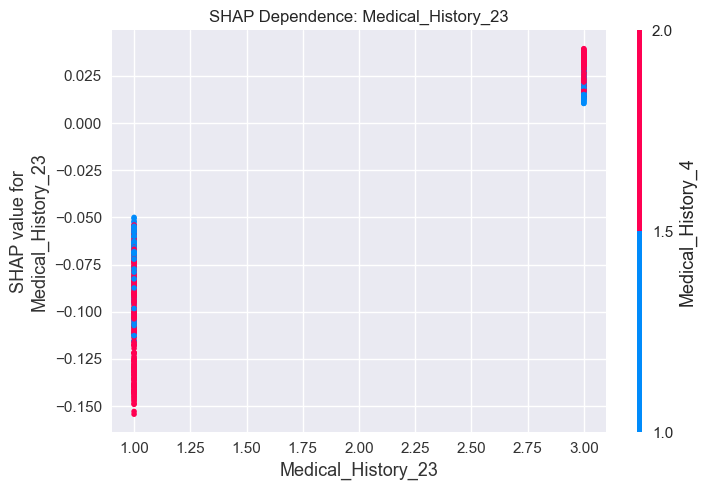

In [32]:
interpret(rf_model, "Random Forest", X_train, X_test, Y_train, Y_test)

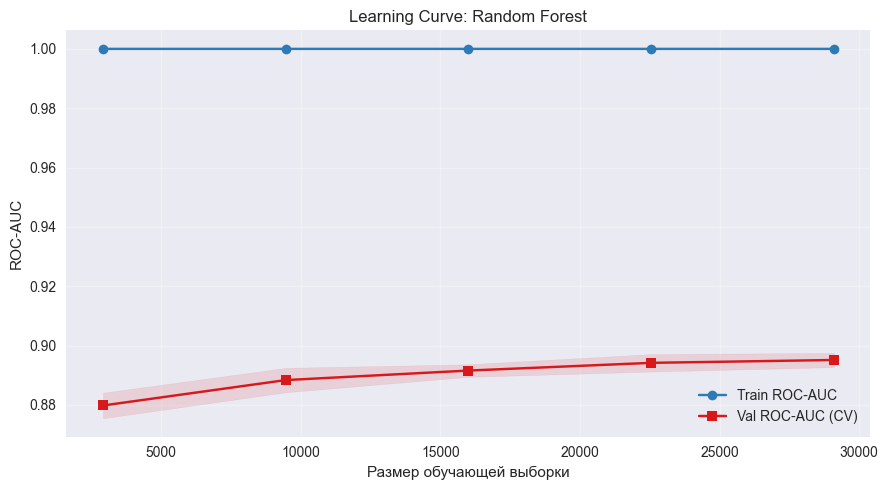

In [33]:
plot_learning_curve_for(
    RandomForestClassifier(n_estimators=50, random_state=1, n_jobs=-1),
    "Random Forest",
    X_train,
    Y_train_np,
)

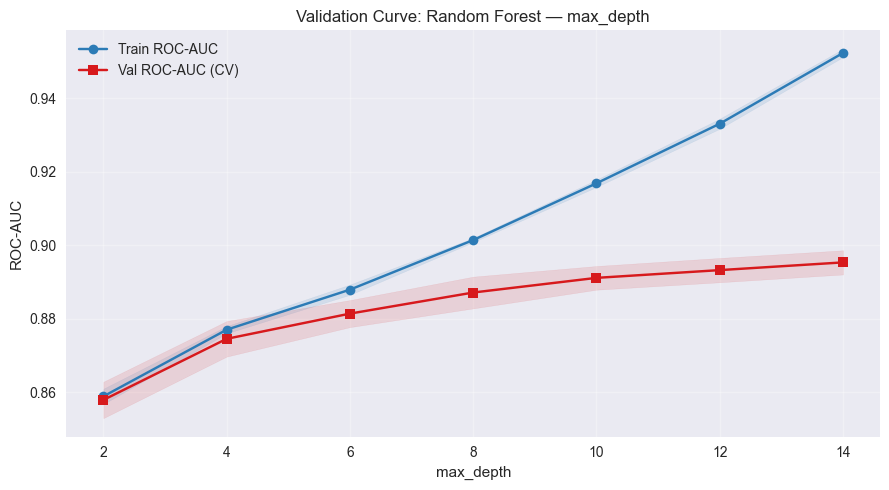

In [34]:
# Validation curve: влияние max_depth на bias-variance tradeoff
param_range_depth = [2, 4, 6, 8, 10, 12, 14]
train_vc, val_vc = validation_curve(
    RandomForestClassifier(n_estimators=50, random_state=1, n_jobs=-1),
    X_train,
    Y_train_np,
    param_name="max_depth",
    param_range=param_range_depth,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
)

plt.figure(figsize=(9, 5))
plt.plot(
    param_range_depth, train_vc.mean(1), "o-", color="#2c7bb6", label="Train ROC-AUC"
)
plt.fill_between(
    param_range_depth,
    train_vc.mean(1) - train_vc.std(1),
    train_vc.mean(1) + train_vc.std(1),
    alpha=0.12,
    color="#2c7bb6",
)
plt.plot(
    param_range_depth, val_vc.mean(1), "s-", color="#d7191c", label="Val ROC-AUC (CV)"
)
plt.fill_between(
    param_range_depth,
    val_vc.mean(1) - val_vc.std(1),
    val_vc.mean(1) + val_vc.std(1),
    alpha=0.12,
    color="#d7191c",
)
plt.xlabel("max_depth")
plt.ylabel("ROC-AUC")
plt.title("Validation Curve: Random Forest — max_depth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод:** Random Forest значительно снижает дисперсию по сравнению с одиночным деревом.
Validation curve показывает, что при `max_depth > 8` прироста на валидации нет — модель
начинает переобучаться. Для тюнинга будем искать оптимальную глубину в диапазоне 6–10.


### 7.3 Logistic Regression

**Логистическая регрессия** — линейная базовая линия. Обучается быстро, интерпретируема
(веса коэффициентов показывают вклад каждого признака), но предполагает линейную разделимость.


In [35]:
lr_model = LogisticRegression(max_iter=1000, random_state=1, C=1.0, solver="lbfgs")
lr_model.fit(X_train, Y_train)
print("Logistic Regression обучена.")

Logistic Regression обучена.


  Модель: Logistic Regression
  Метрика                        Train      Test
  ---------------------------------------------
  ROC-AUC                       0.8862    0.8835
  Accuracy                      0.8138    0.8118
  Log Loss                      0.3960    0.3999
  ---------------------------------------------
  F1-score (test)               0.7118
  Precision (test)              0.7279
  Recall (test)                 0.6964


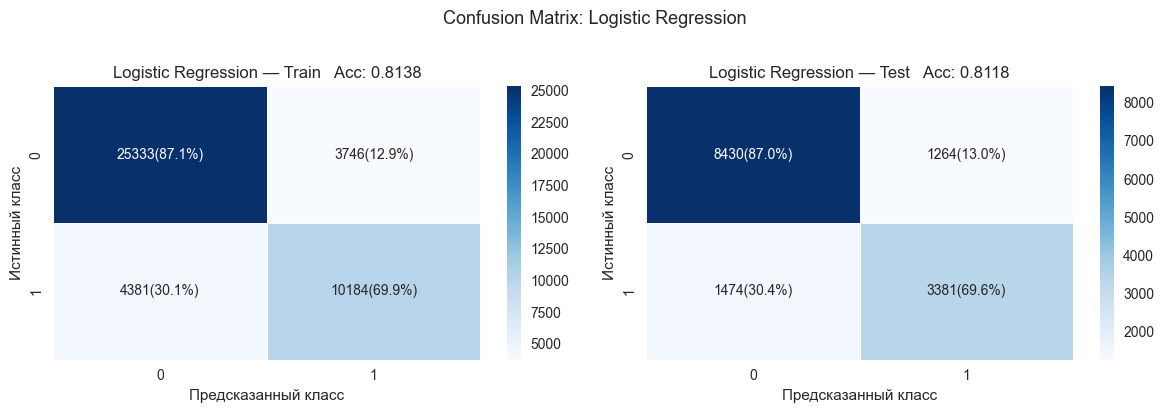

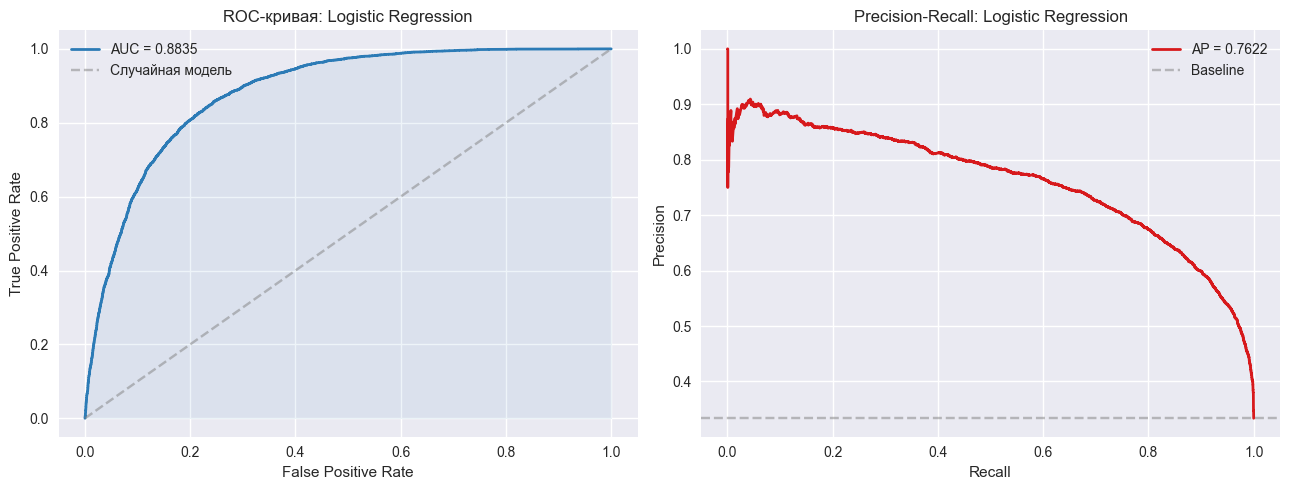

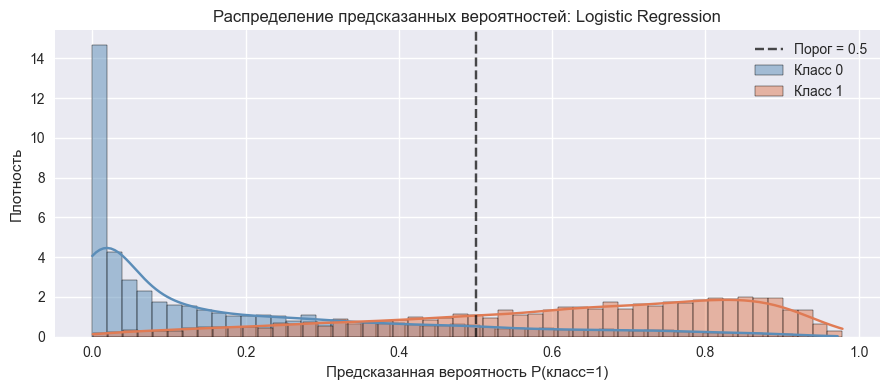

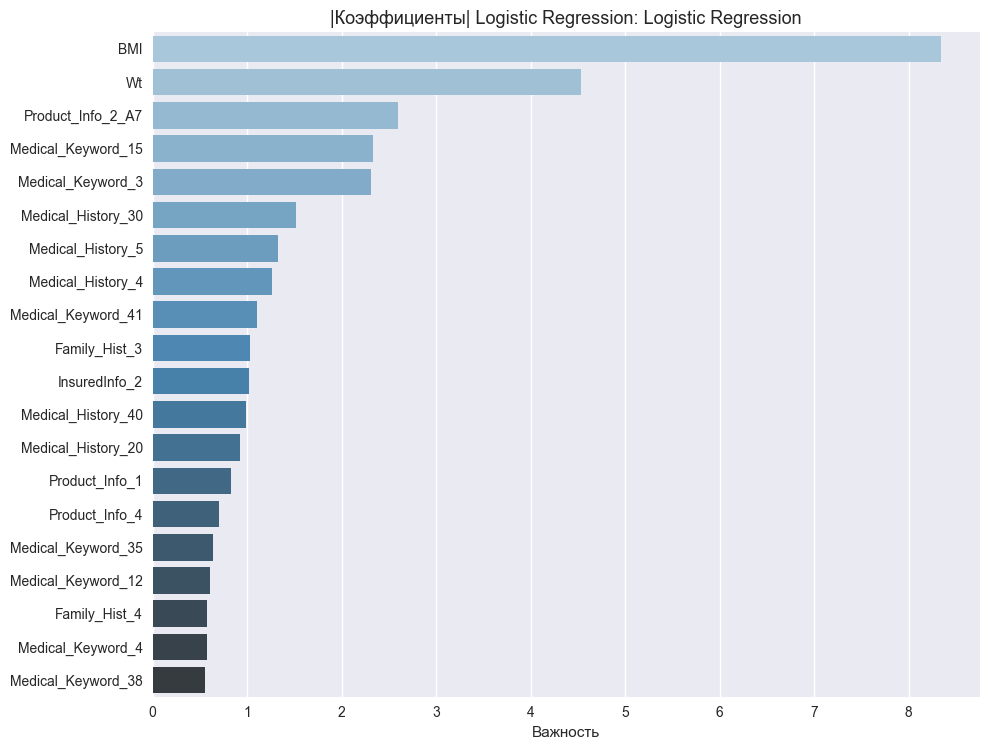

In [36]:
interpret(
    lr_model, "Logistic Regression", X_train, X_test, Y_train, Y_test, skip_shap=True
)

**Вывод:** LR уступает древесным моделям, подтверждая нелинейность задачи.
Высокий |coef| у BMI и медицинских ключевых слов совпадает с важностью признаков в RF — признаки
информативны независимо от алгоритма.


### 7.4 XGBoost

**XGBoost** строит деревья последовательно, минимизируя градиент ошибки с регуляризацией.  
Отличается высокой скоростью и встроенной защитой от переобучения (`gamma`, `reg_lambda`).


In [37]:
xgb_model = XGBClassifier(
    n_estimators=200, random_state=1, eval_metric="logloss", n_jobs=-1, verbosity=0
)
xgb_model.fit(X_train, Y_train)
print("XGBoost обучен.")

XGBoost обучен.


  Модель: XGBoost
  Метрика                        Train      Test
  ---------------------------------------------
  ROC-AUC                       0.9753    0.9035
  Accuracy                      0.9181    0.8216
  Log Loss                      0.2169    0.3684
  ---------------------------------------------
  F1-score (test)               0.7369
  Precision (test)              0.7253
  Recall (test)                 0.7489


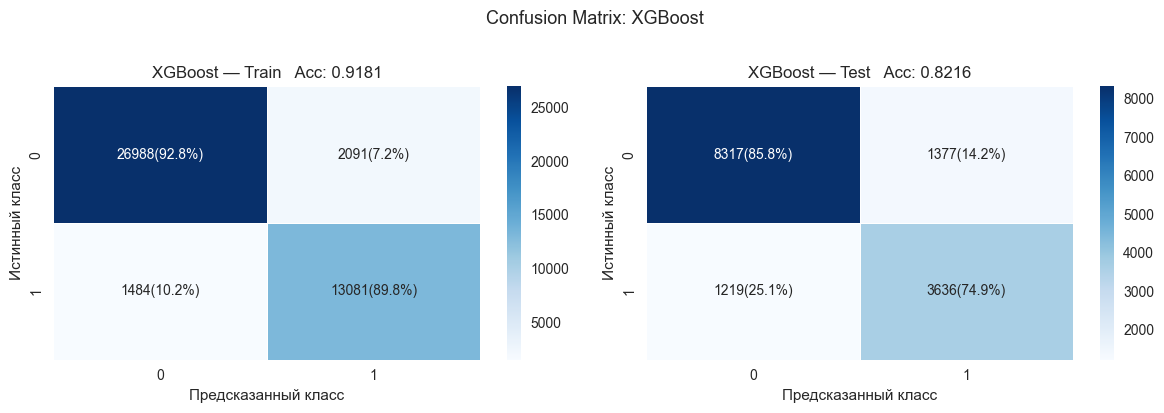

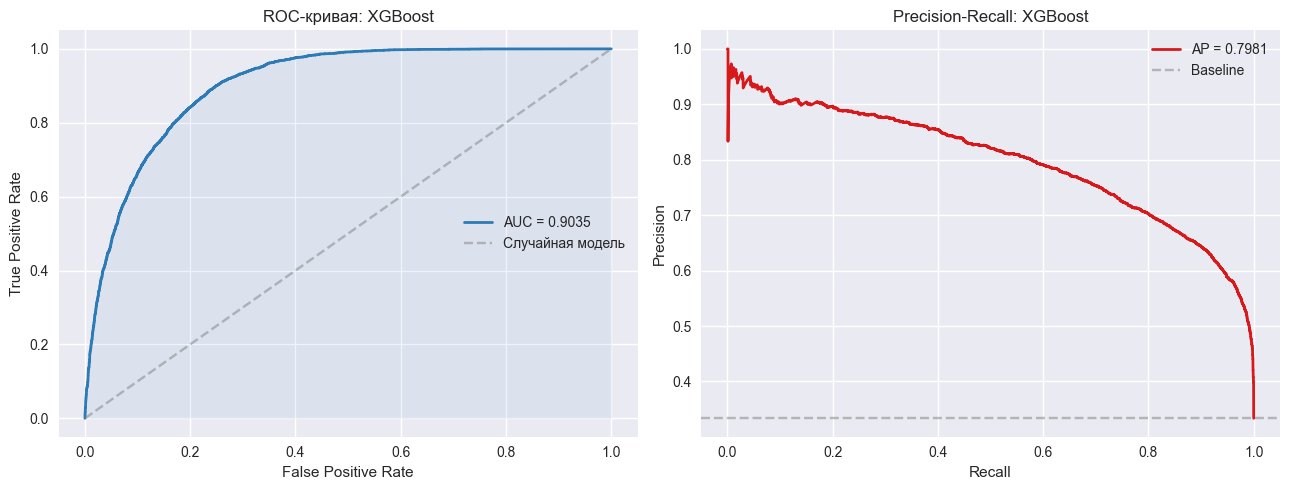

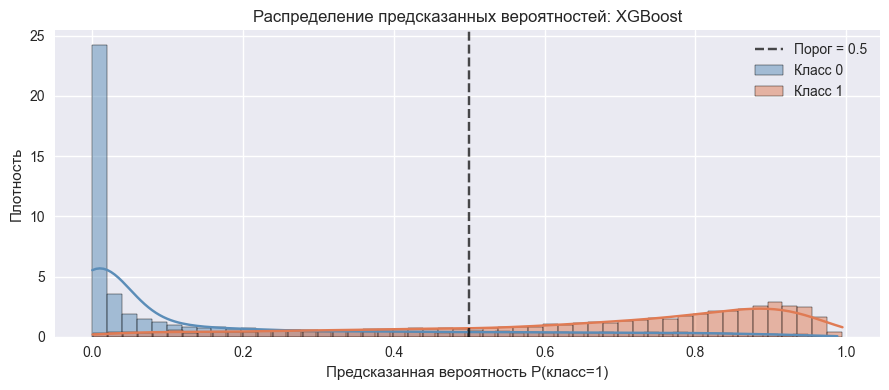

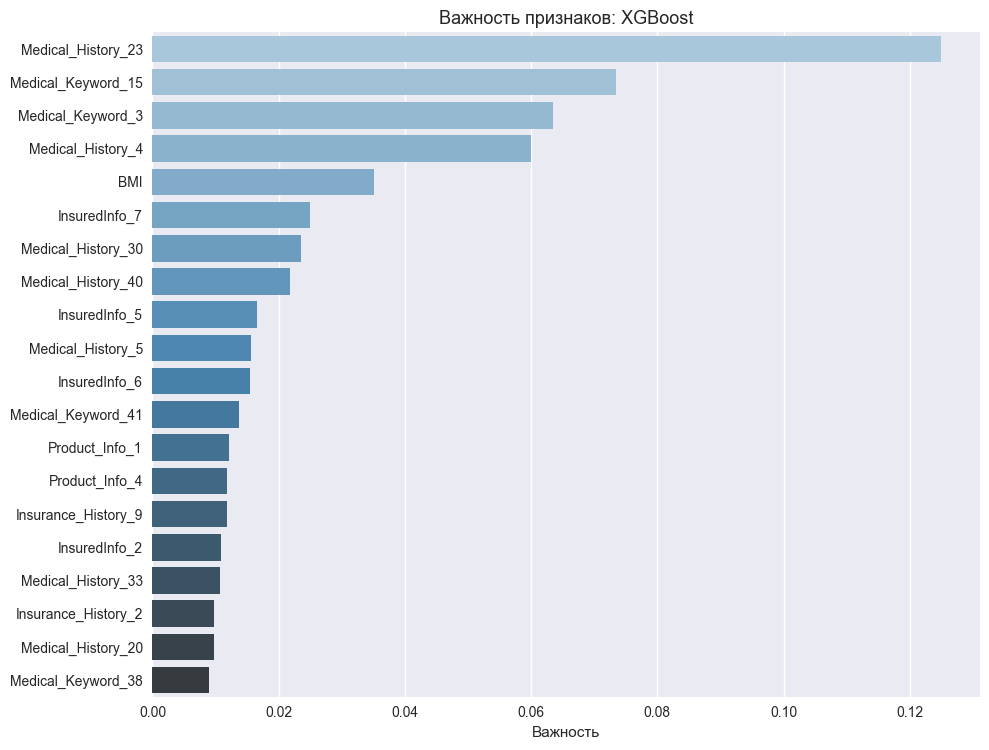

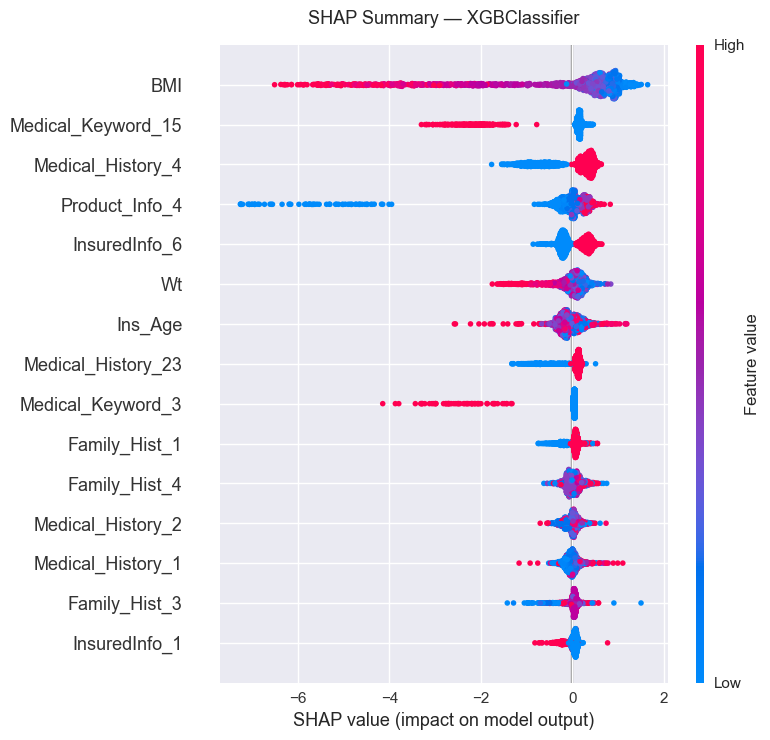

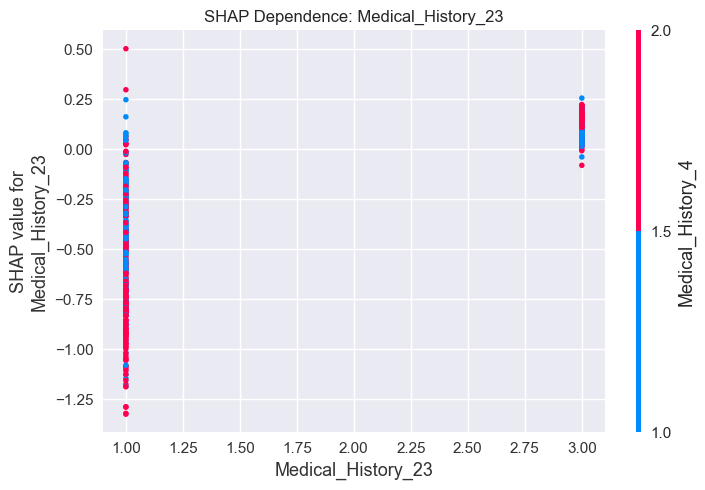

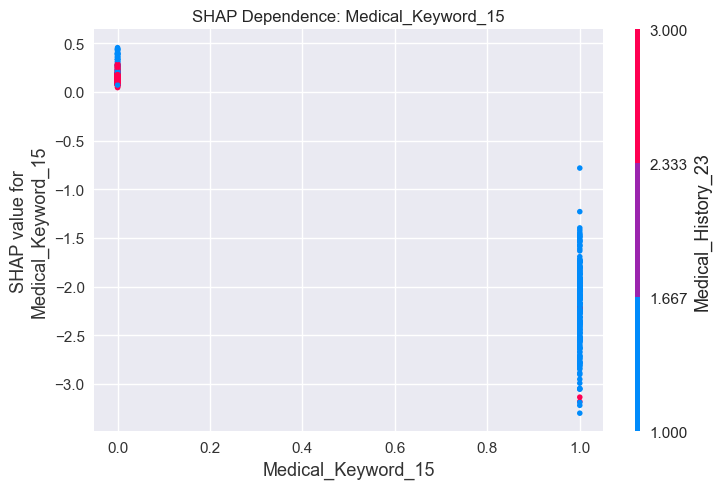

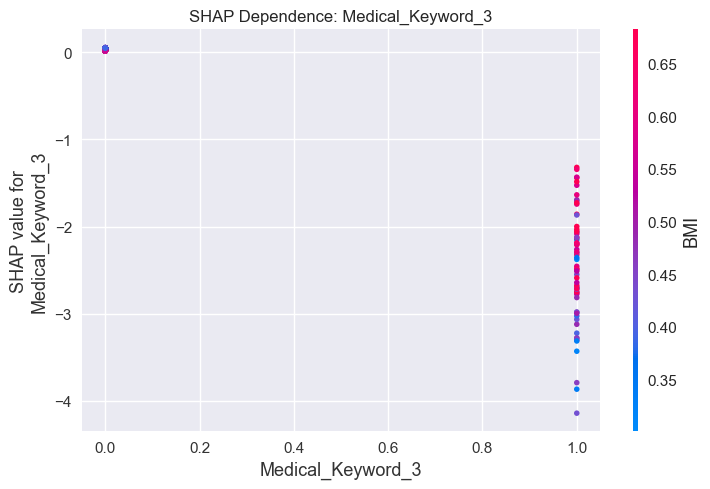

In [38]:
interpret(xgb_model, "XGBoost", X_train, X_test, Y_train, Y_test)

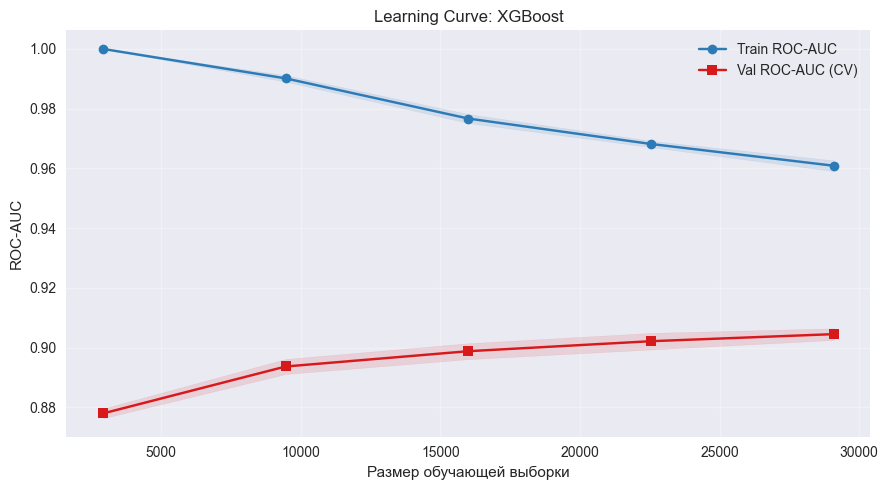

In [39]:
plot_learning_curve_for(
    XGBClassifier(
        n_estimators=100, random_state=1, eval_metric="logloss", n_jobs=-1, verbosity=0
    ),
    "XGBoost",
    X_train,
    Y_train_np,
)

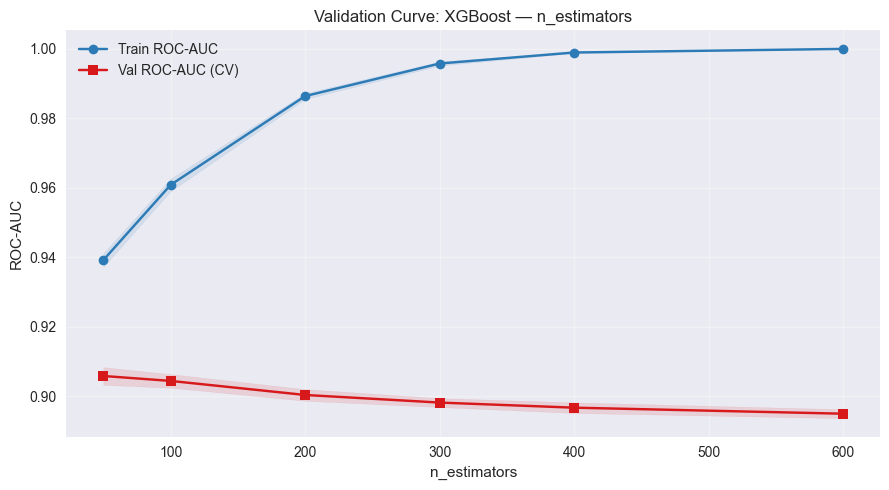

In [40]:
# Validation curve: влияние n_estimators
param_range_est = [50, 100, 200, 300, 400, 600]
train_vc_xgb, val_vc_xgb = validation_curve(
    XGBClassifier(random_state=1, eval_metric="logloss", n_jobs=-1, verbosity=0),
    X_train,
    Y_train_np,
    param_name="n_estimators",
    param_range=param_range_est,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
)

plt.figure(figsize=(9, 5))
plt.plot(
    param_range_est, train_vc_xgb.mean(1), "o-", color="#2c7bb6", label="Train ROC-AUC"
)
plt.fill_between(
    param_range_est,
    train_vc_xgb.mean(1) - train_vc_xgb.std(1),
    train_vc_xgb.mean(1) + train_vc_xgb.std(1),
    alpha=0.12,
    color="#2c7bb6",
)
plt.plot(
    param_range_est, val_vc_xgb.mean(1), "s-", color="#d7191c", label="Val ROC-AUC (CV)"
)
plt.fill_between(
    param_range_est,
    val_vc_xgb.mean(1) - val_vc_xgb.std(1),
    val_vc_xgb.mean(1) + val_vc_xgb.std(1),
    alpha=0.12,
    color="#d7191c",
)
plt.xlabel("n_estimators")
plt.ylabel("ROC-AUC")
plt.title("Validation Curve: XGBoost — n_estimators")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод:** XGBoost превосходит RF и DT по умолчанию. Validation curve по `n_estimators`
показывает явное **переобучение** модели на более 100 деревьев — скорее всего, рост не происходит без тюнинга
остальных гиперпараметров.


### 7.5 Gradient Boosting (sklearn)

Sklearn реализация градиентного бустинга. Работает медленнее XGBoost, но стабильна и
хорошо изучена. `staged_predict_proba` позволяет отследить динамику по числу деревьев.


In [41]:
gb_model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4, subsample=0.8, random_state=1
)
gb_model.fit(X_train, Y_train)
print("Gradient Boosting обучен.")

Gradient Boosting обучен.


  Модель: Gradient Boosting
  Метрика                        Train      Test
  ---------------------------------------------
  ROC-AUC                       0.9237    0.9086
  Accuracy                      0.8470    0.8278
  Log Loss                      0.3317    0.3573
  ---------------------------------------------
  F1-score (test)               0.7468
  Precision (test)              0.7331
  Recall (test)                 0.7611


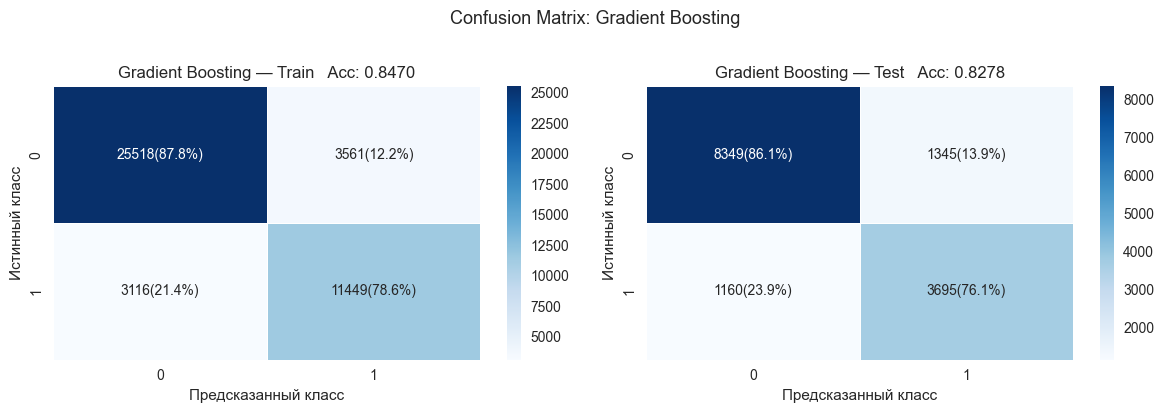

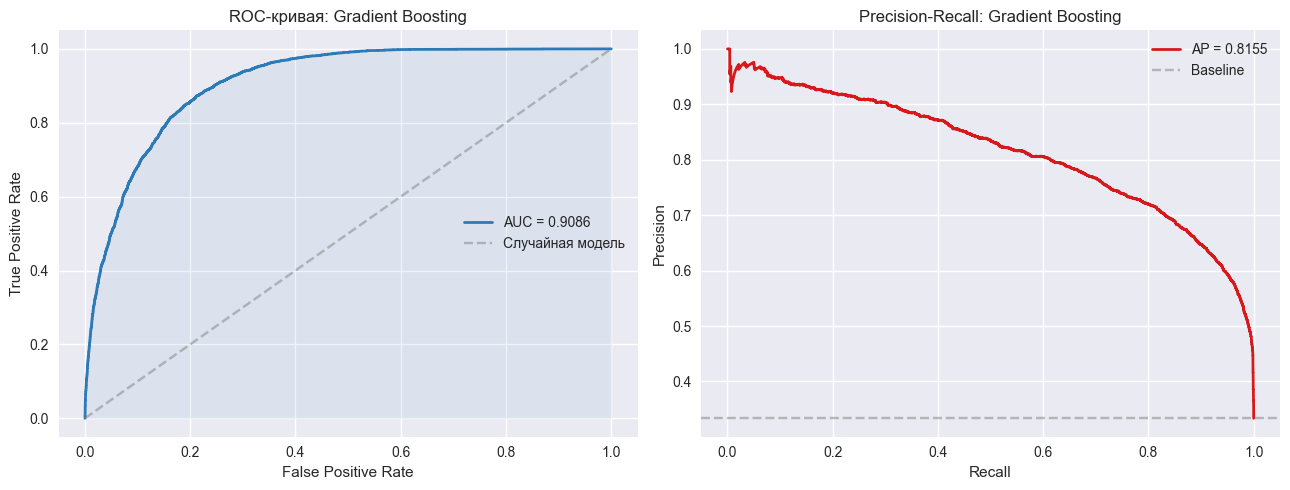

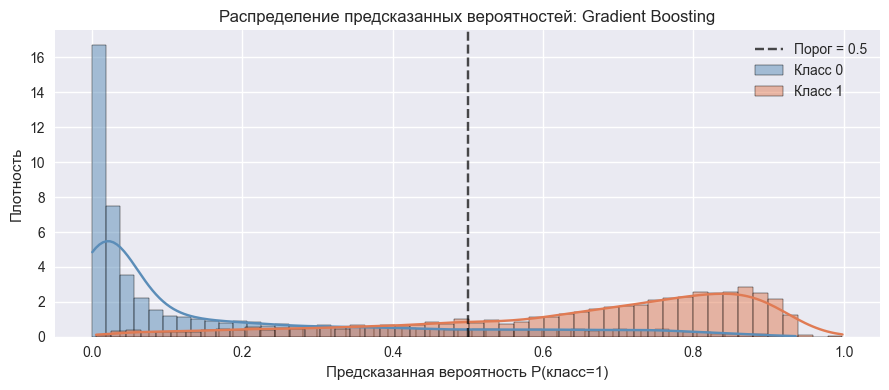

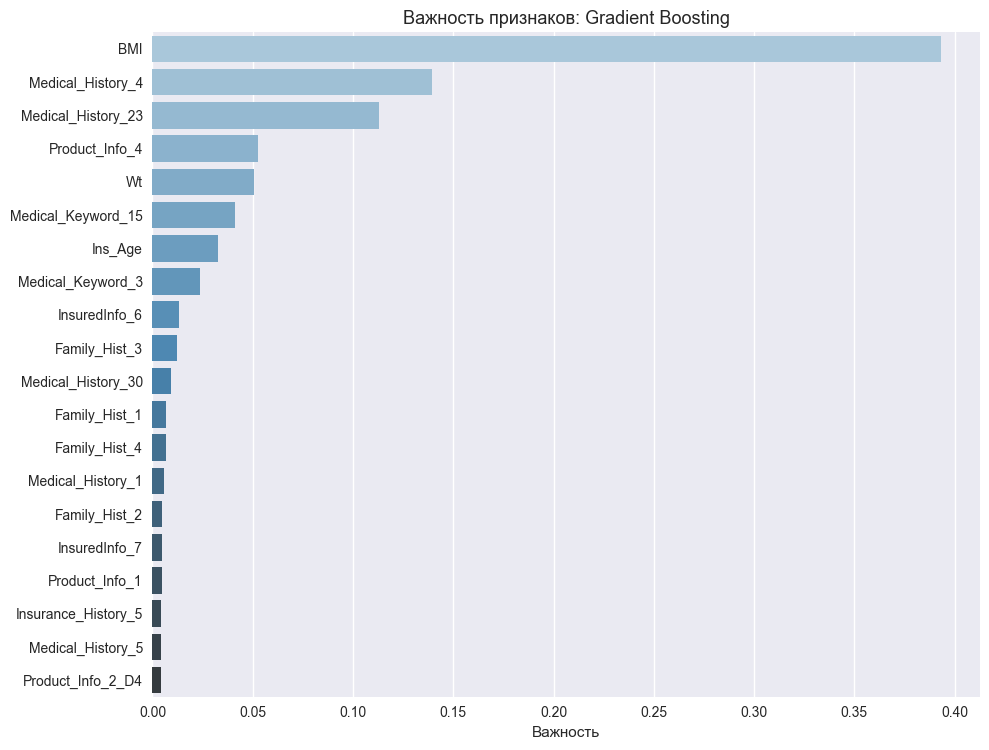

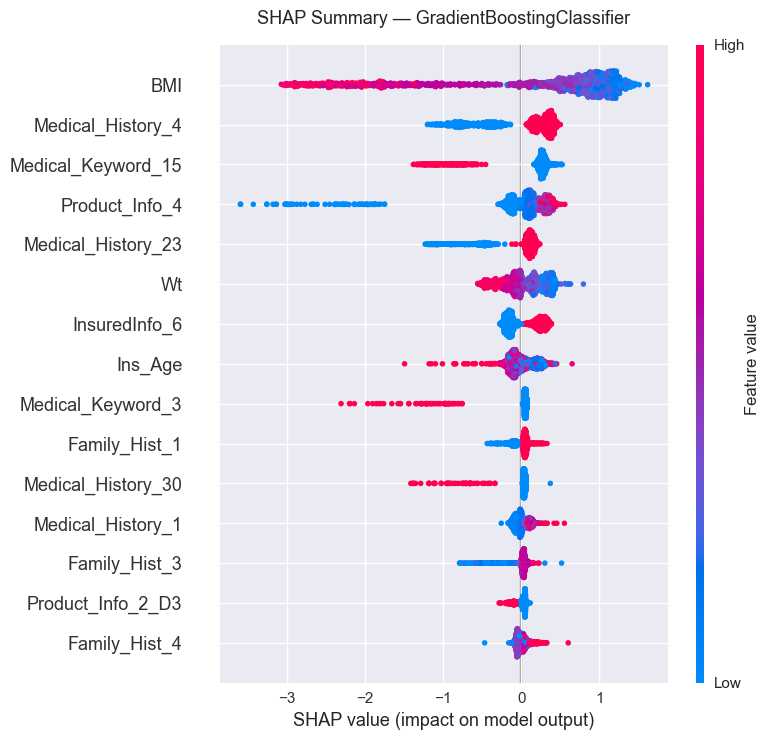

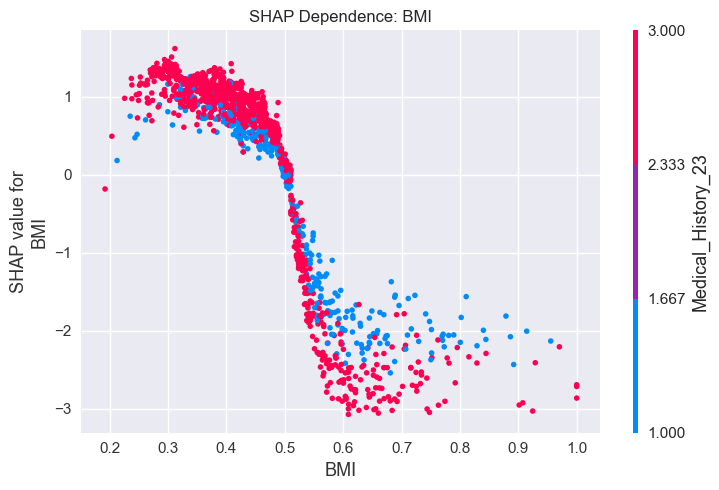

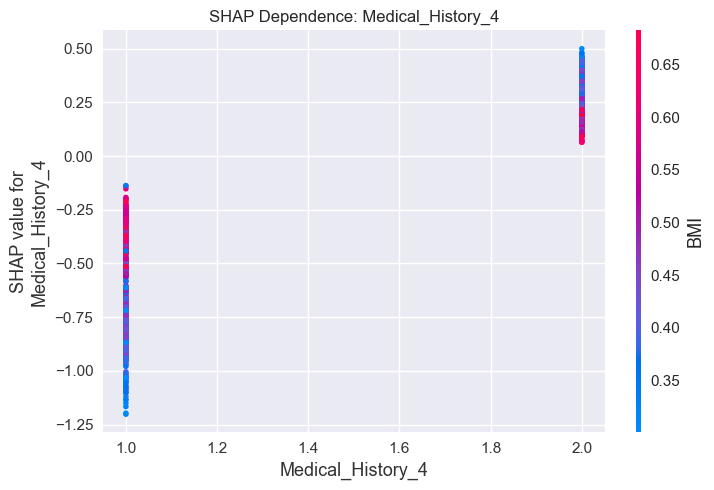

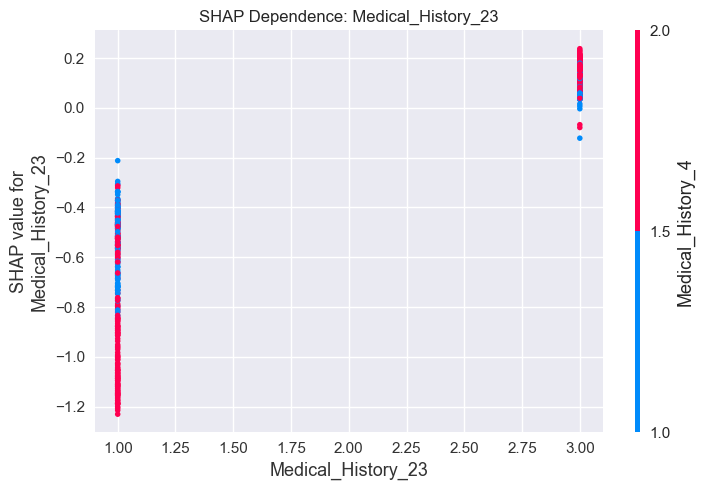

In [42]:
interpret(gb_model, "Gradient Boosting", X_train, X_test, Y_train, Y_test)

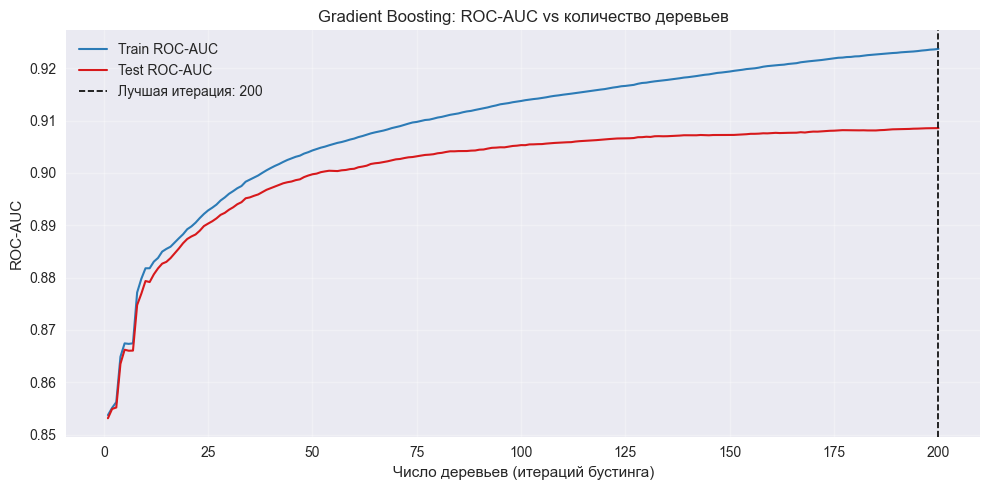

Лучшая итерация по тесту: 200


In [43]:
# Staged ROC-AUC — бесплатная кривая обучения через staged_predict_proba
staged_train_auc, staged_test_auc = [], []
for proba_t in gb_model.staged_predict_proba(X_train):
    staged_train_auc.append(roc_auc_score(Y_train_np, proba_t[:, 1]))
for proba_v in gb_model.staged_predict_proba(X_test):
    staged_test_auc.append(roc_auc_score(Y_test_np, proba_v[:, 1]))

n_range = range(1, gb_model.n_estimators + 1)
plt.figure(figsize=(10, 5))
plt.plot(n_range, staged_train_auc, color="#2c7bb6", lw=1.5, label="Train ROC-AUC")
plt.plot(n_range, staged_test_auc, color="#d7191c", lw=1.5, label="Test ROC-AUC")
best_iter = int(np.argmax(staged_test_auc)) + 1
plt.axvline(
    best_iter, color="black", ls="--", lw=1.2, label=f"Лучшая итерация: {best_iter}"
)
plt.xlabel("Число деревьев (итераций бустинга)")
plt.ylabel("ROC-AUC")
plt.title("Gradient Boosting: ROC-AUC vs количество деревьев")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Лучшая итерация по тесту:", best_iter)

**Вывод:** Staged curve наглядно показывает, когда модель начинает переобучаться.
Optimal n_estimators должен быть меньше заданных 200 — это учтём при тюнинге.


### 7.6 CatBoost

**CatBoost** от Яндекса использует упорядоченный бустинг (Ordered Boosting), что снижает
утечку данных при обучении и улучшает обобщение. Встроенная поддержка категориальных признаков.


In [44]:
cb_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0,
)
cb_model.fit(X_train, Y_train, eval_set=(X_test, Y_test), plot=False)
print("CatBoost обучен.")

CatBoost обучен.


  Модель: CatBoost
  Метрика                        Train      Test
  ---------------------------------------------
  ROC-AUC                       0.9275    0.9093
  Accuracy                      0.8519    0.8303
  Log Loss                      0.3254    0.3554
  ---------------------------------------------
  F1-score (test)               0.7496
  Precision (test)              0.7383
  Recall (test)                 0.7613


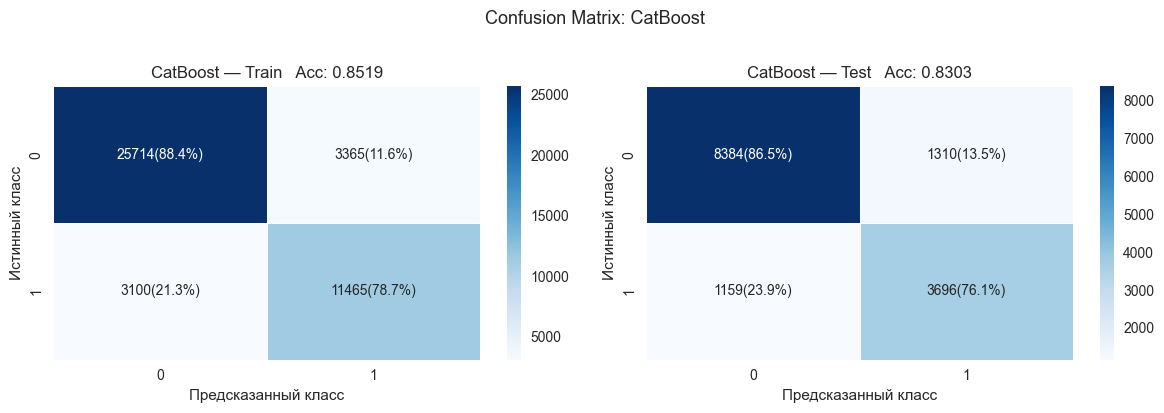

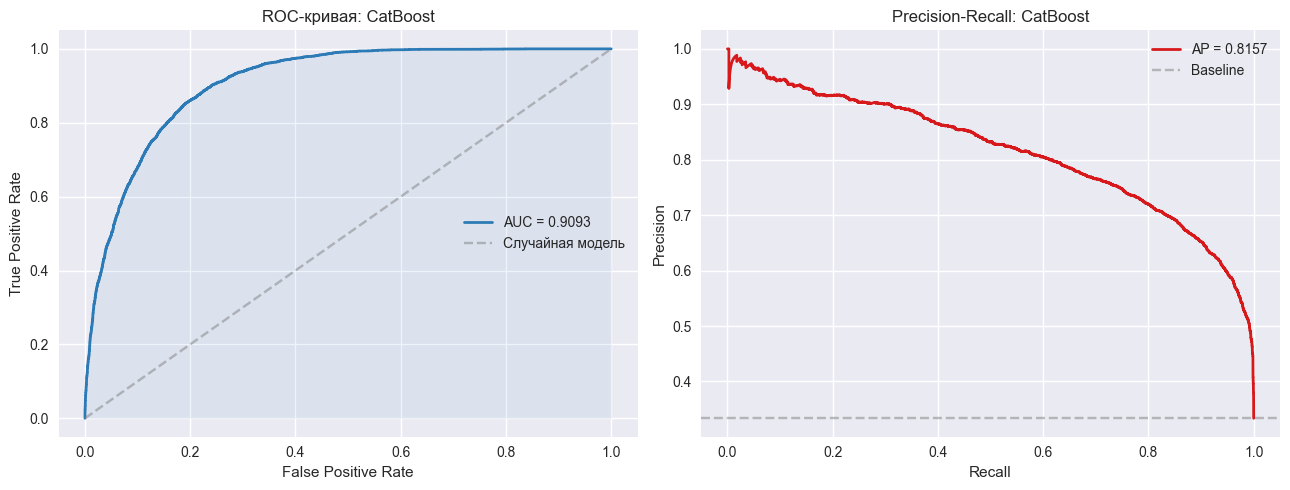

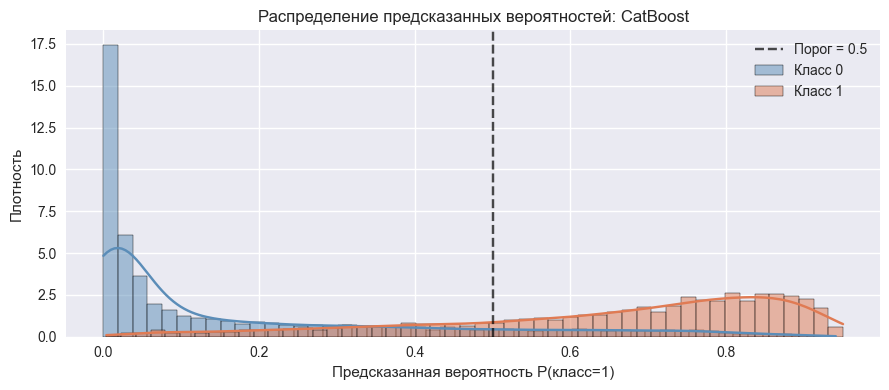

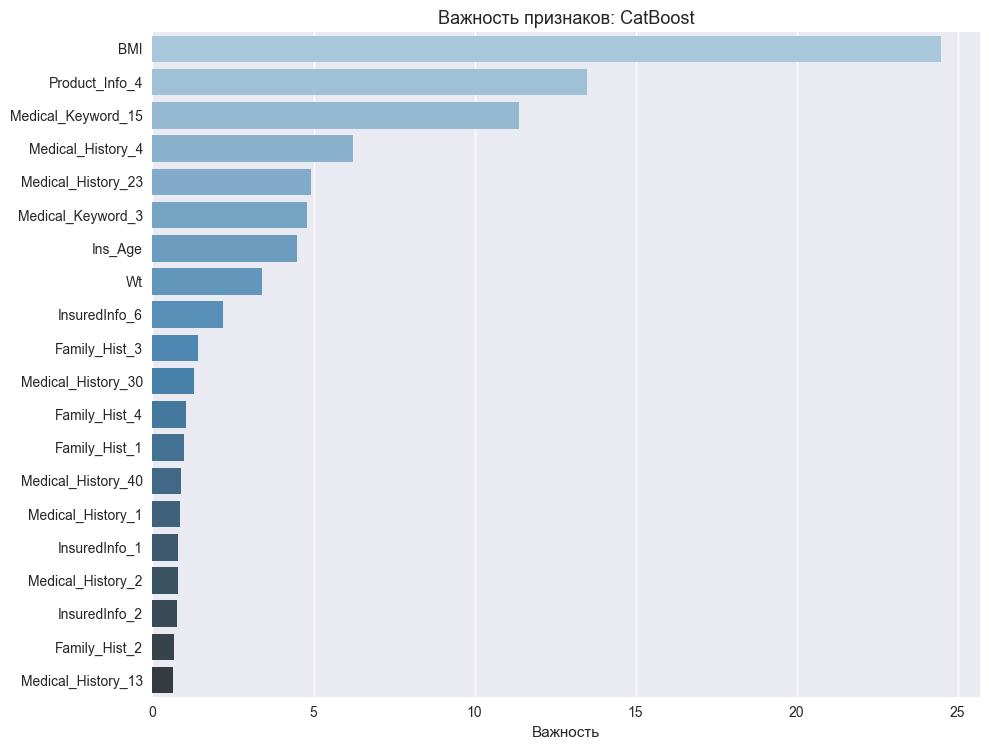

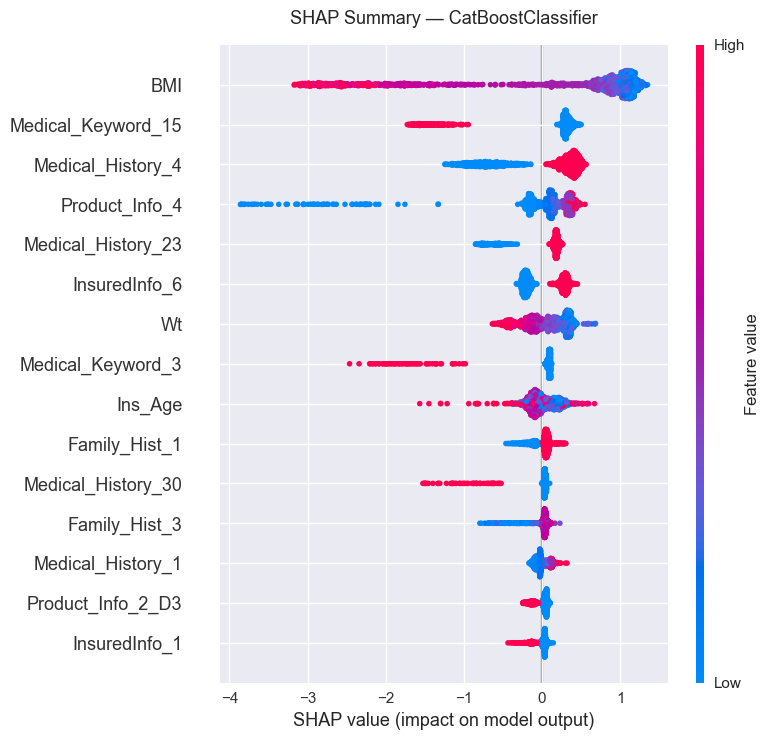

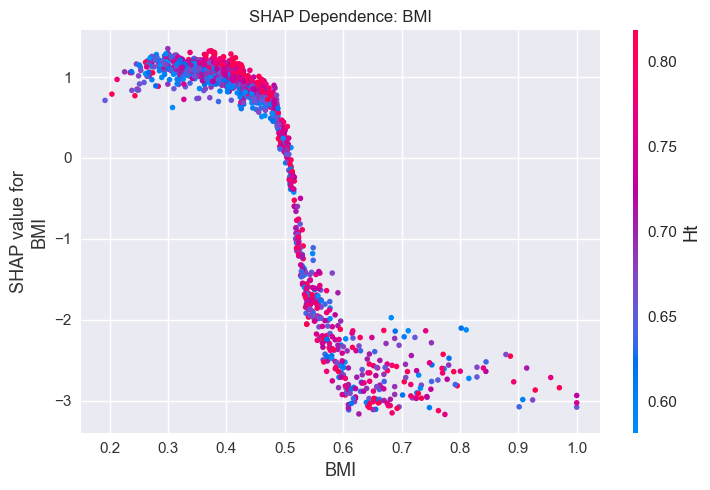

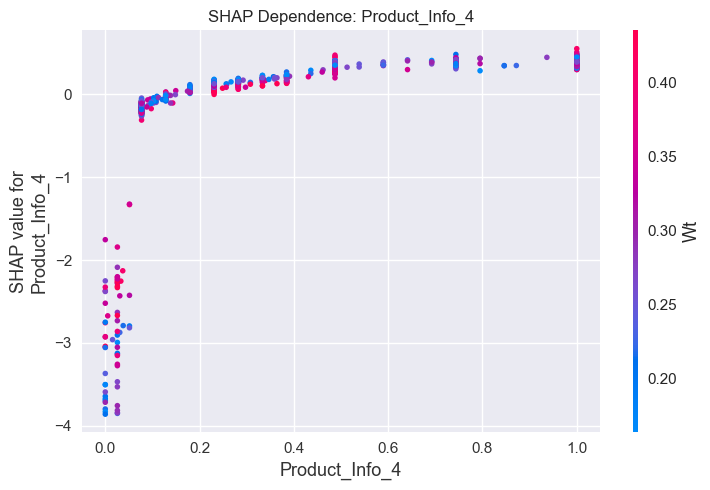

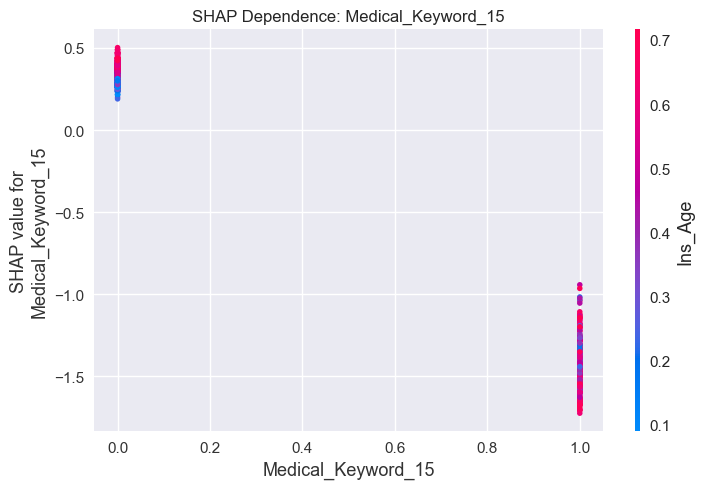

In [45]:
interpret(cb_model, "CatBoost", X_train, X_test, Y_train, Y_test)

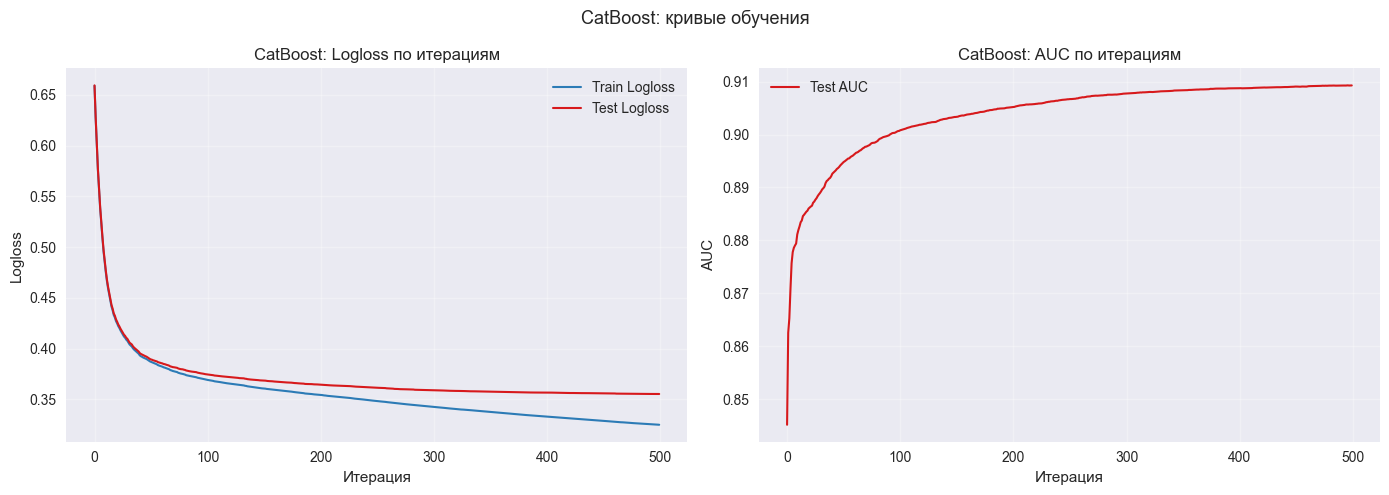

In [46]:
# Кривые обучения CatBoost по итерациям (Logloss и AUC)
evals = cb_model.get_evals_result()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in [(axes[0], "Logloss"), (axes[1], "AUC")]:
    if "learn" in evals and metric in evals["learn"]:
        ax.plot(
            evals["learn"][metric], color="#2c7bb6", lw=1.5, label="Train " + metric
        )
    if "validation" in evals and metric in evals["validation"]:
        ax.plot(
            evals["validation"][metric], color="#d7191c", lw=1.5, label="Test " + metric
        )
    ax.set_xlabel("Итерация")
    ax.set_ylabel(metric)
    ax.set_title("CatBoost: " + metric + " по итерациям")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("CatBoost: кривые обучения", fontsize=13)
plt.tight_layout()
plt.show()

**Вывод:** CatBoost демонстрирует отличное качество при минимальной настройке.
Кривые обучения показывают стабильное снижение Logloss и рост AUC без явного переобучения.


### 7.7 NODE (Neural Oblivious Decision Ensembles)

**NODE** — гибридная архитектура, объединяющая деревья решений и нейронные сети.  
Использует дифференцируемые «забывчивые» деревья (oblivious trees) с мягкими разбиениями,
оптимизируемыми через backpropagation.

**Особенности реализации:**

- Входные данные должны быть `float32`
- Обучение через PyTorch Lightning с ранней остановкой
- `predict_proba` возвращает `(n, 1)` для бинарной задачи (sigmoid), поэтому `proba_col=0`
- `feature_importances_` недоступен — SHAP и importance-plot пропускаем


In [49]:
# Подготовка данных: float32 для PyTorch
X_train_f32 = X_train.astype(np.float32)
X_test_f32 = X_test.astype(np.float32)
print(f"X_train_f32: {X_train_f32.shape}, dtype={X_train_f32.dtypes.unique()}")
print(f"Y_train_np: {Y_train_np.shape}, dtype={Y_train_np.dtype}")

X_train_f32: (43644, 138), dtype=[dtype('float32')]
Y_train_np: (43644,), dtype=int64


In [50]:
# Инициализация и обучение NODE с CSVLogger для сохранения кривой обучения
node_logger = CSVLogger(save_dir="node_logs", name="")
node_model = NODEClassifier()
node_model.fit(
    X_train_f32,
    Y_train_np,
    max_epochs=30,
    batch_size=512,
    patience=5,
    logger=node_logger,
    enable_progress_bar=True,
)
print("NODE обучен.")

Trainer already configured with model summary callbacks: [<class 'lightning.pytorch.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Numerical Feature: Product_Info_1, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 2, 'categories': None}
--------------------------------------------------
Numerical Feature: Product_Info_3, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: Product_Info_4, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 20, 'categories': None}
--------------------------------------------------
Numerical Feature: Product_Info_5, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 2, 'categories': None}
--------------------------------------------------
Numerical Feature: Product_Info_6, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 2, 'categories': None}
--------------------------------------------------
Numerical Feature: Product_Info_7, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 3, 'categories': None}
-----


  | Name                   | Type              | Params | Mode  | FLOPs
-----------------------------------------------------------------------------
0 | loss_fct               | BCEWithLogitsLoss | 0      | train | 0    
1 | estimator              | NODE              | 2.5 M  | train | 0    
2 | estimator.block        | DenseBlock        | 2.5 M  | train | 0    
3 | estimator.tabular_head | MLPhead           | 513    | train | 0    
-----------------------------------------------------------------------------
2.5 M     Trainable params
3.1 K     Non-trainable params
2.5 M     Total params
10.025    Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
0         Total Flops


NODE обучен.


Доступные метрики: ['epoch', 'step', 'train_loss_epoch', 'train_loss_step', 'val_loss']


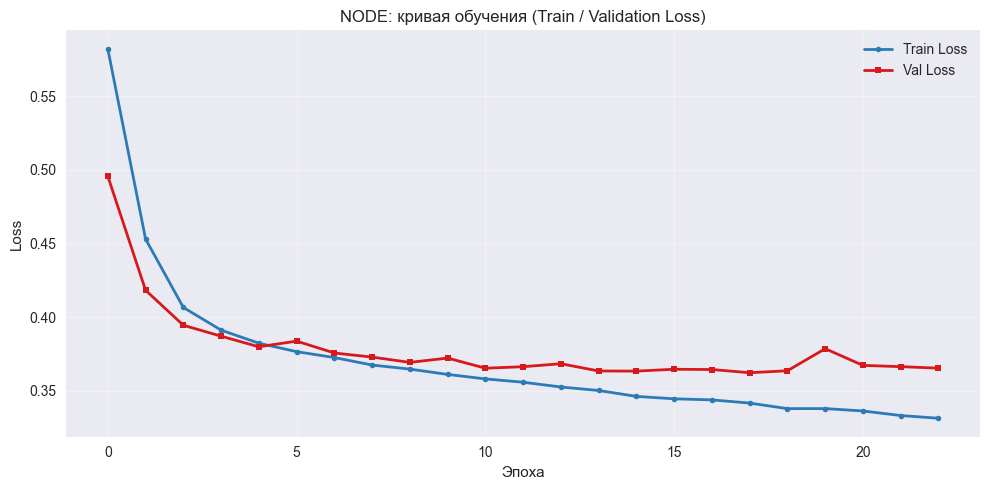

In [51]:
# Кривая обучения NODE из CSV-лога PyTorch Lightning
try:
    log_files = sorted(glob.glob("node_logs/version_*/metrics.csv"))
    if log_files:
        node_hist = pd.read_csv(log_files[-1])
        print("Доступные метрики:", node_hist.columns.tolist())

        train_col = next(
            (
                c
                for c in node_hist.columns
                if "train" in c.lower() and "loss" in c.lower()
            ),
            None,
        )
        val_col = next(
            (
                c
                for c in node_hist.columns
                if "val" in c.lower() and "loss" in c.lower()
            ),
            None,
        )
        epoch_col = "epoch" if "epoch" in node_hist.columns else None

        if epoch_col and (train_col or val_col):
            plt.figure(figsize=(10, 5))
            if train_col:
                df_t = node_hist[[epoch_col, train_col]].dropna()
                plt.plot(
                    df_t[epoch_col],
                    df_t[train_col],
                    "o-",
                    color="#2c7bb6",
                    lw=2,
                    ms=4,
                    label="Train Loss",
                )
            if val_col:
                df_v = node_hist[[epoch_col, val_col]].dropna()
                plt.plot(
                    df_v[epoch_col],
                    df_v[val_col],
                    "s-",
                    color="#d7191c",
                    lw=2,
                    ms=4,
                    label="Val Loss",
                )
            plt.xlabel("Эпоха")
            plt.ylabel("Loss")
            plt.title("NODE: кривая обучения (Train / Validation Loss)")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("Метрики loss в логе не найдены.")
    else:
        print("Лог-файл NODE не найден (node_logs/).")
except Exception as exc:
    print("Не удалось прочитать логи NODE:", exc)

  Модель: NODE
  Метрика                        Train      Test
  ---------------------------------------------
  ROC-AUC                       0.9173    0.9053
  Accuracy                      0.8404    0.8262
  Log Loss                      0.3411    0.3615
  ---------------------------------------------
  F1-score (test)               0.7438
  Precision (test)              0.7322
  Recall (test)                 0.7557


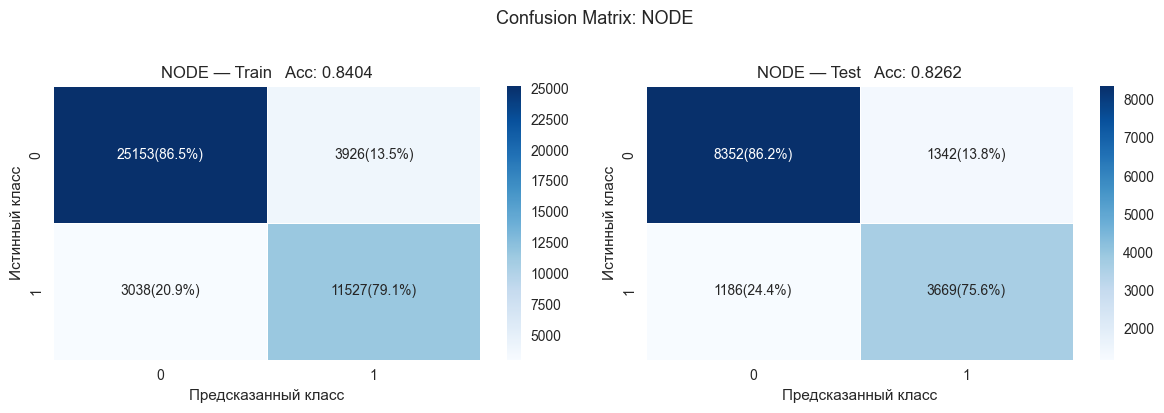

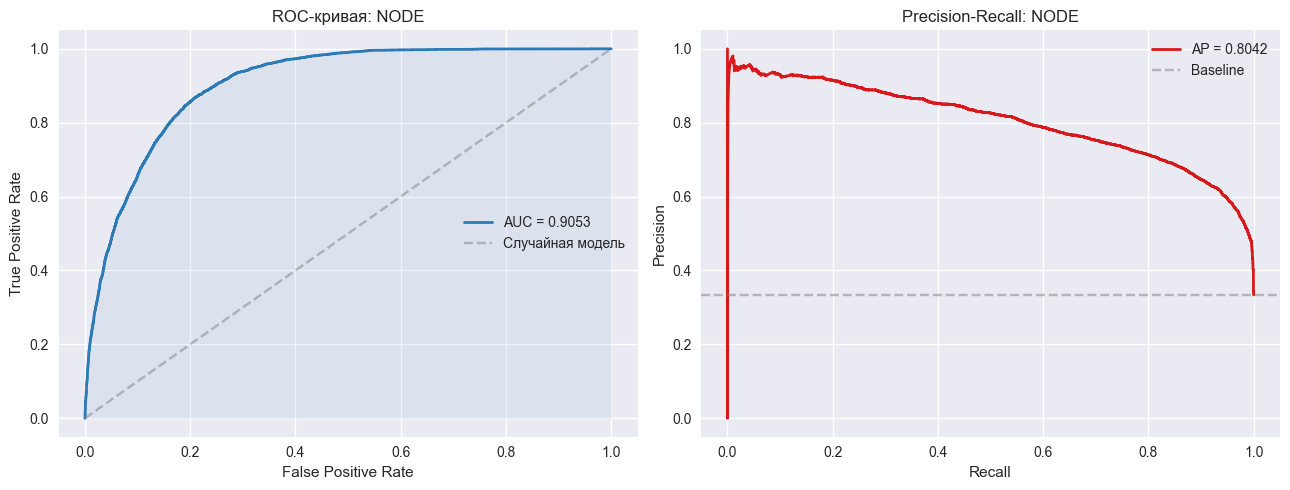

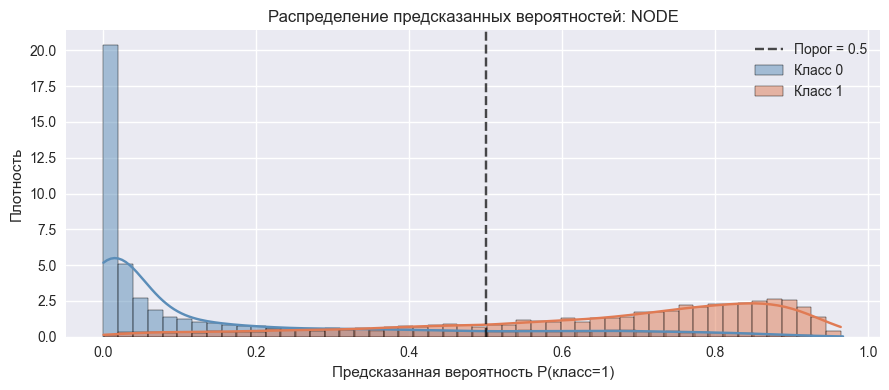

In [52]:
# Метрики NODE (proba_col=0 — sigmoid возвращает (n,1))
compute_metrics(
    node_model, X_train_f32, X_test_f32, Y_train_np, Y_test_np, "NODE", proba_col=0
)
plot_confusion_matrices(
    node_model, X_train_f32, X_test_f32, Y_train_np, Y_test_np, "NODE"
)
plot_roc_pr_for_model("NODE")
plot_proba_distribution("NODE")

**Вывод:** NODE — это нейросетевая интерпретация ансамбля деревьев. На табличных данных
среднего размера она часто уступает классическому бустингу, но демонстрирует преимущества
при очень большом числе признаков и достаточном объёме данных.


## 8. Подбор гиперпараметров

Тюним три модели: **Random Forest** (GridSearchCV), **Gradient Boosting** (GridSearchCV),
**XGBoost** (RandomizedSearchCV — большая сетка, эффективнее по времени).

После тюнинга каждую оптимальную модель прогоняем через `interpret()` и сравниваем с дефолтной.


### 8.1 Random Forest — GridSearchCV


In [54]:
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [4, 6, 8],
    "min_samples_split": [30, 50, 100],
    "min_samples_leaf": [20, 40],
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=1, n_jobs=-1),
    rf_param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)
rf_grid.fit(X_train, Y_train)
rf_optimal = rf_grid.best_estimator_

print("Лучшие параметры RF:")
pprint(rf_grid.best_params_)
print(f"CV ROC-AUC (best): {rf_grid.best_score_:.4f}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Лучшие параметры RF:
{'max_depth': None,
 'min_samples_leaf': 20,
 'min_samples_split': 30,
 'n_estimators': 200}
CV ROC-AUC (best): 0.8951


  Модель: Random Forest (tuned)
  Метрика                        Train      Test
  ---------------------------------------------
  ROC-AUC                       0.9223    0.8975
  Accuracy                      0.8425    0.8172
  Log Loss                      0.3645    0.3944
  ---------------------------------------------
  F1-score (test)               0.7147
  Precision (test)              0.7459
  Recall (test)                 0.6861


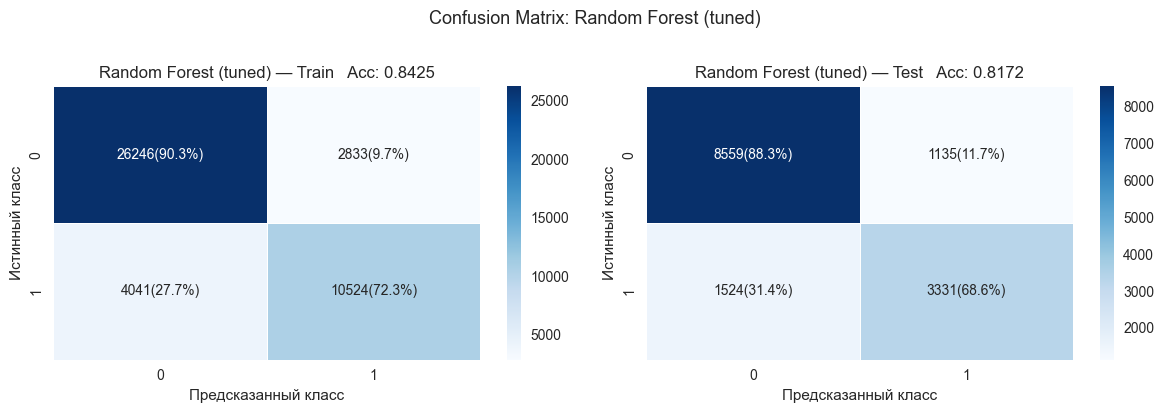

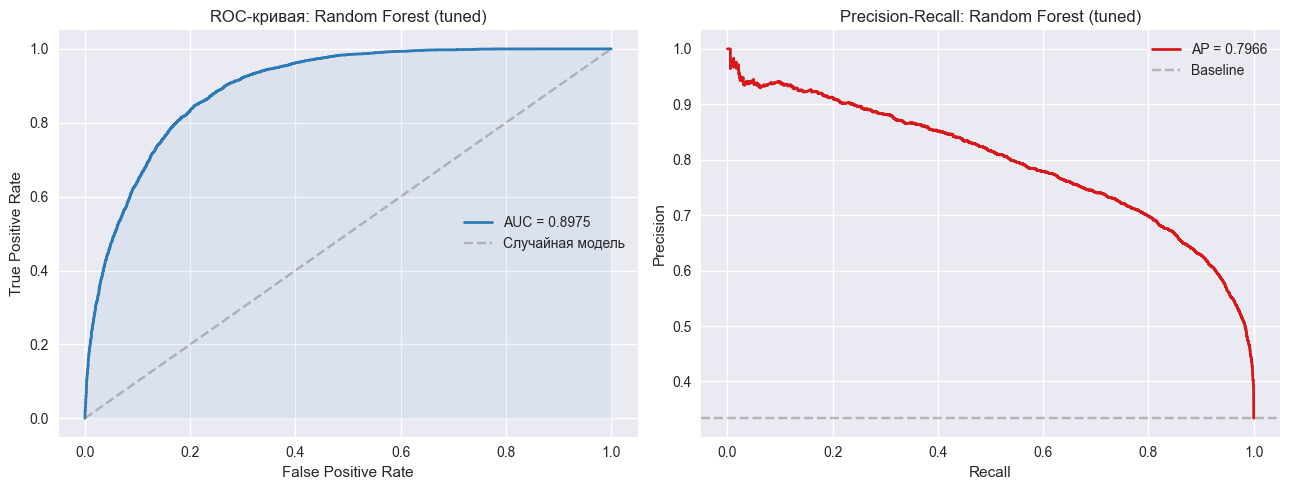

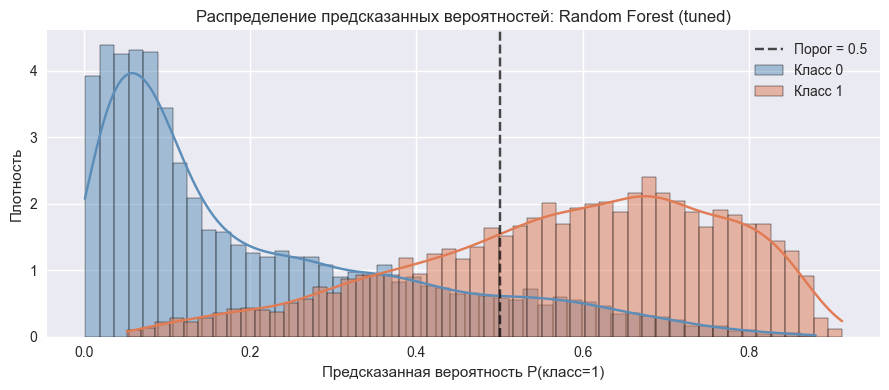

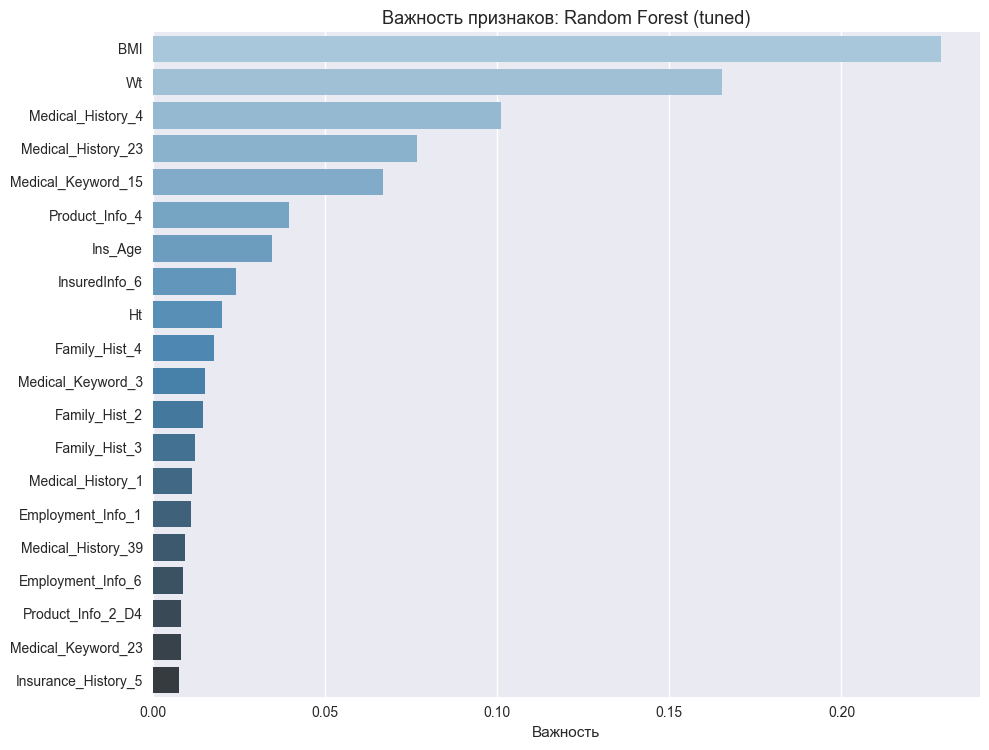

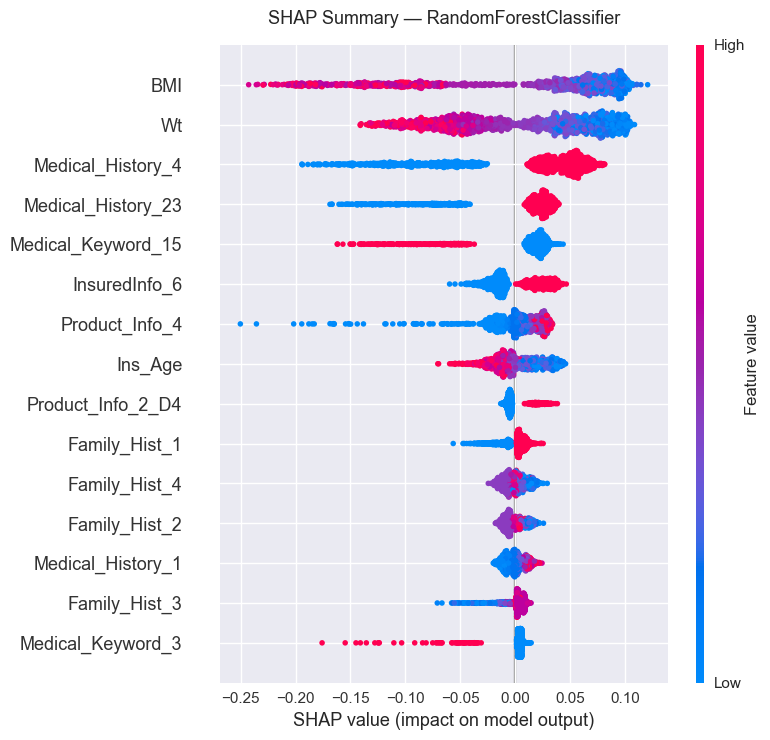

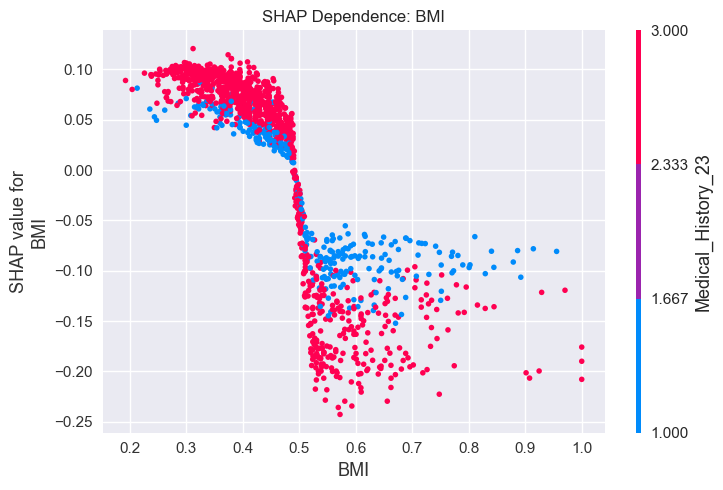

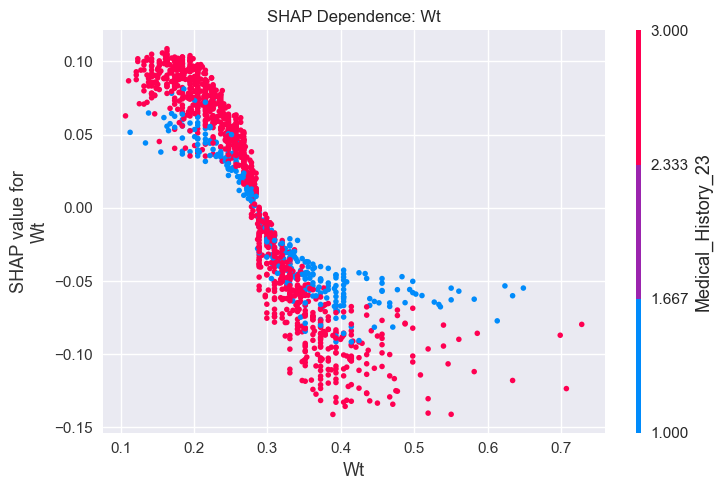

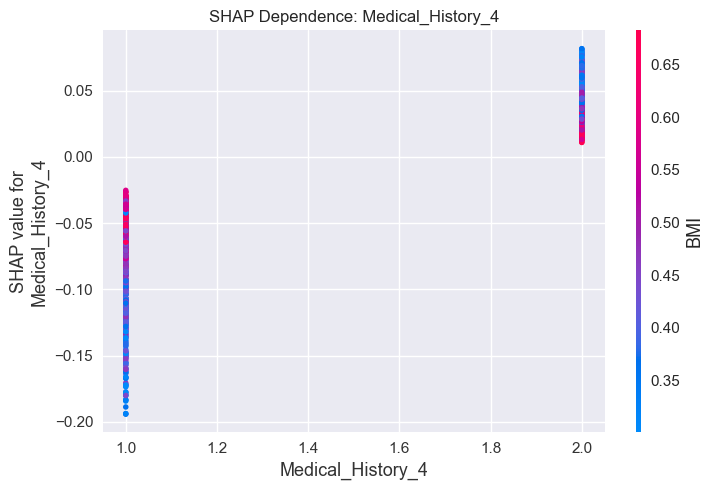

In [55]:
interpret(rf_optimal, "Random Forest (tuned)", X_train, X_test, Y_train, Y_test)

### 8.2 Gradient Boosting — GridSearchCV


In [58]:
gb_param_grid = {
    "n_estimators": [5, 50, 100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.1],
    "subsample": [0.8, 1.0],
}
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=1),
    gb_param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)
gb_grid.fit(X_train, Y_train)
gb_optimal = gb_grid.best_estimator_

print("Лучшие параметры GB:")
pprint(gb_grid.best_params_)
print(f"CV ROC-AUC (best): {gb_grid.best_score_:.4f}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Лучшие параметры GB:
{'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
CV ROC-AUC (best): 0.9073


  Модель: Gradient Boosting (tuned)
  Метрика                        Train      Test
  ---------------------------------------------
  ROC-AUC                       0.9466    0.9101
  Accuracy                      0.8746    0.8315
  Log Loss                      0.2901    0.3546
  ---------------------------------------------
  F1-score (test)               0.7520
  Precision (test)              0.7390
  Recall (test)                 0.7656


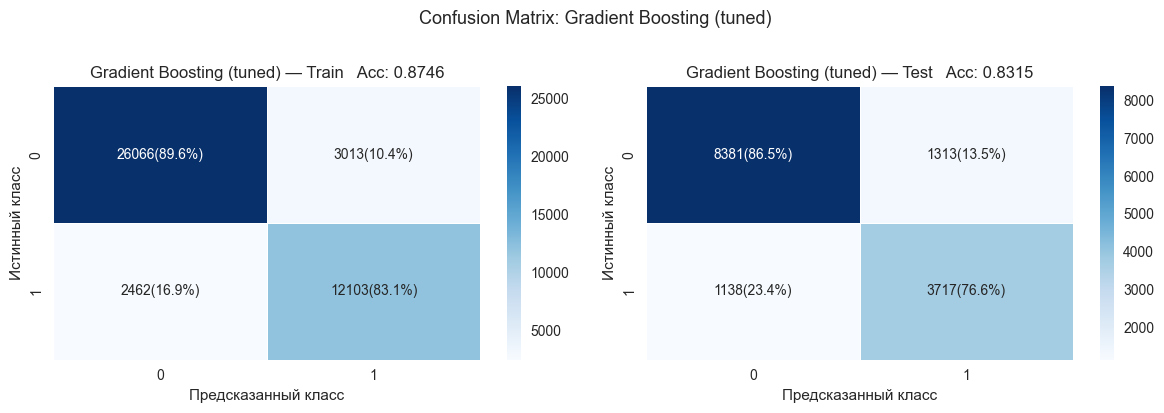

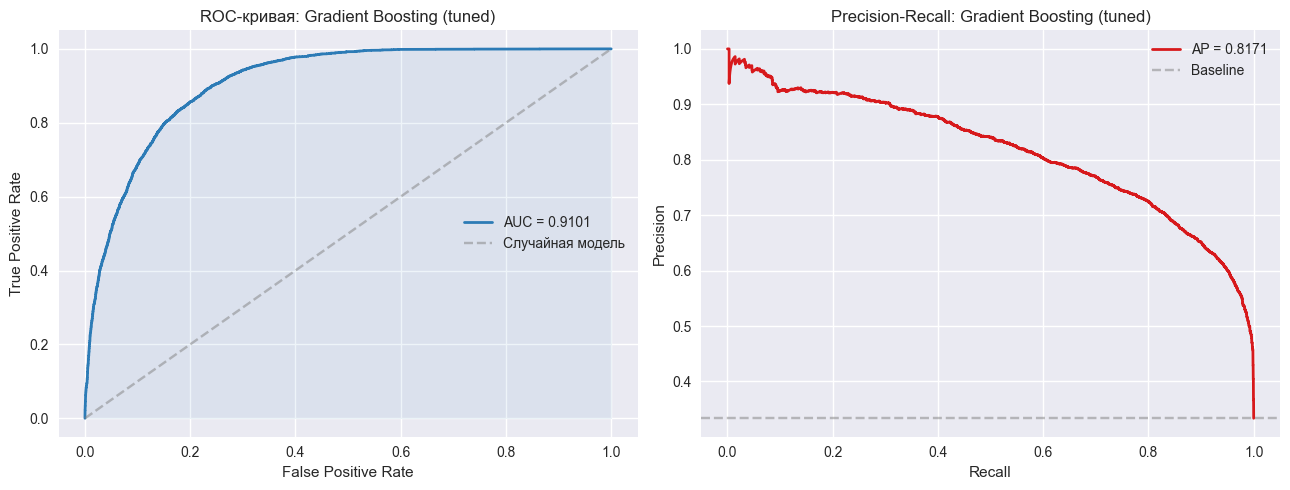

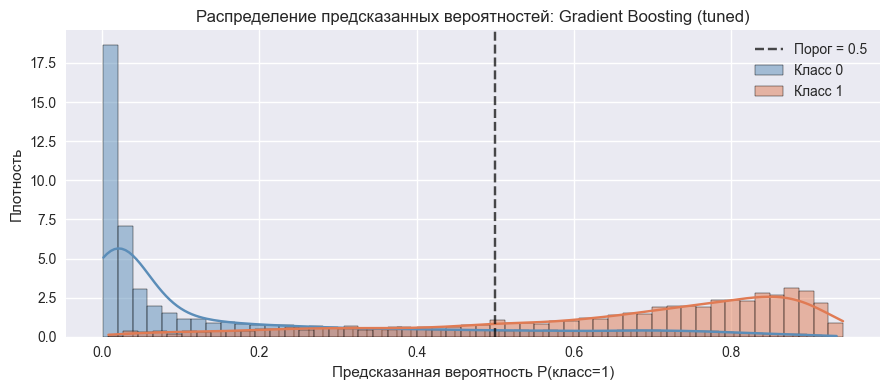

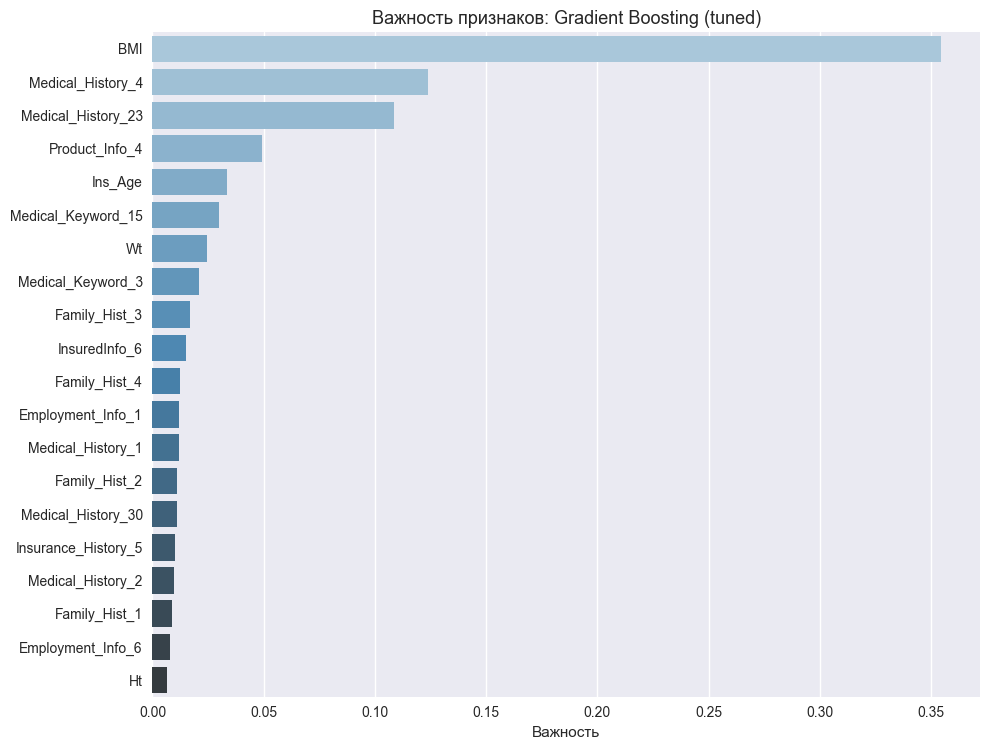

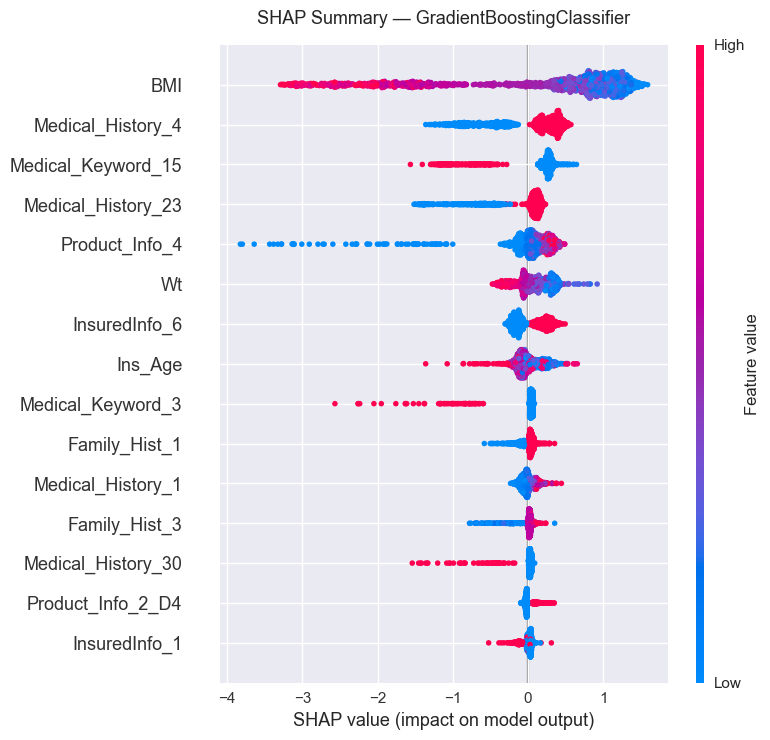

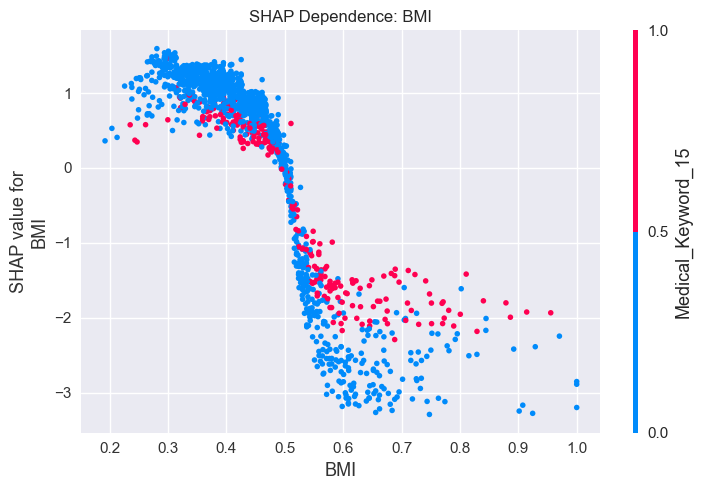

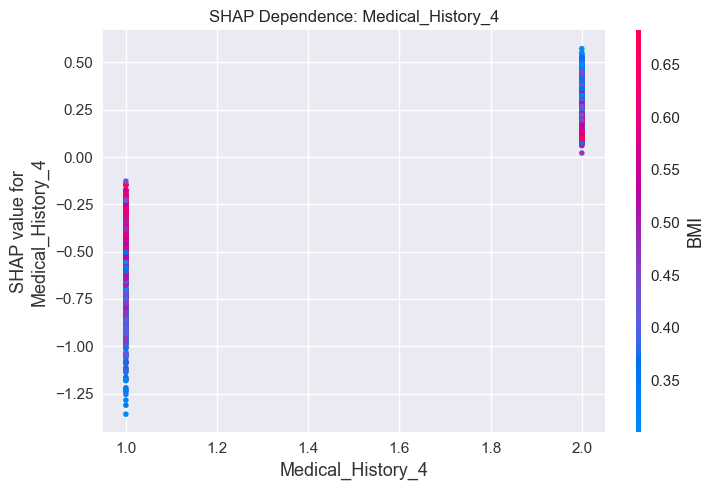

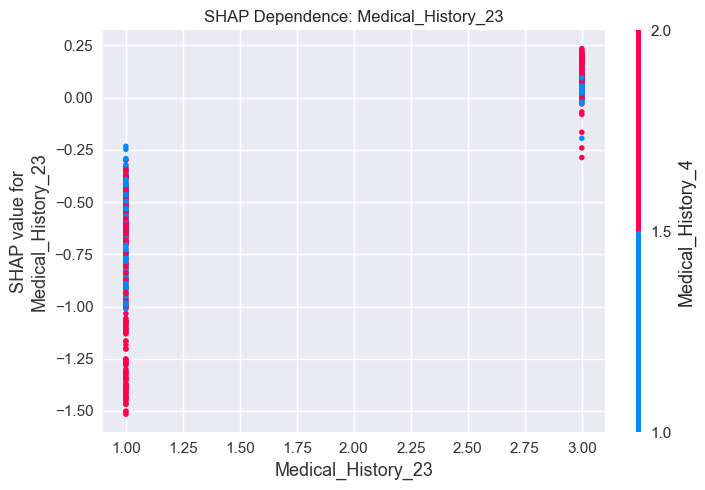

In [59]:
interpret(gb_optimal, "Gradient Boosting (tuned)", X_train, X_test, Y_train, Y_test)

### 8.3 XGBoost — RandomizedSearchCV


In [60]:
from scipy.stats import uniform as sp_uniform, randint as sp_randint

xgb_param_dist = {
    "n_estimators": sp_randint(5, 200),
    "max_depth": sp_randint(3, 8),
    "learning_rate": sp_uniform(0.03, 0.12),
    "subsample": sp_uniform(0.7, 0.3),
    "colsample_bytree": sp_uniform(0.7, 0.3),
    "min_child_weight": sp_randint(1, 6),
    "gamma": sp_uniform(0, 0.3),
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=1, eval_metric="logloss", n_jobs=-1, verbosity=0),
    xgb_param_dist,
    n_iter=15,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
xgb_search.fit(X_train, Y_train)
xgb_optimal = xgb_search.best_estimator_

print("Лучшие параметры XGB:")
pprint(xgb_search.best_params_)
print(f"CV ROC-AUC (best): {xgb_search.best_score_:.4f}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Лучшие параметры XGB:
{'colsample_bytree': np.float64(0.7932946965146986),
 'gamma': np.float64(0.09755499660802411),
 'learning_rate': np.float64(0.11755274140056768),
 'max_depth': 5,
 'min_child_weight': 3,
 'n_estimators': 197,
 'subsample': np.float64(0.8148780624261369)}
CV ROC-AUC (best): 0.9078


  Модель: XGBoost (tuned)
  Метрика                        Train      Test
  ---------------------------------------------
  ROC-AUC                       0.9313    0.9103
  Accuracy                      0.8552    0.8310
  Log Loss                      0.3159    0.3526
  ---------------------------------------------
  F1-score (test)               0.7519
  Precision (test)              0.7369
  Recall (test)                 0.7677


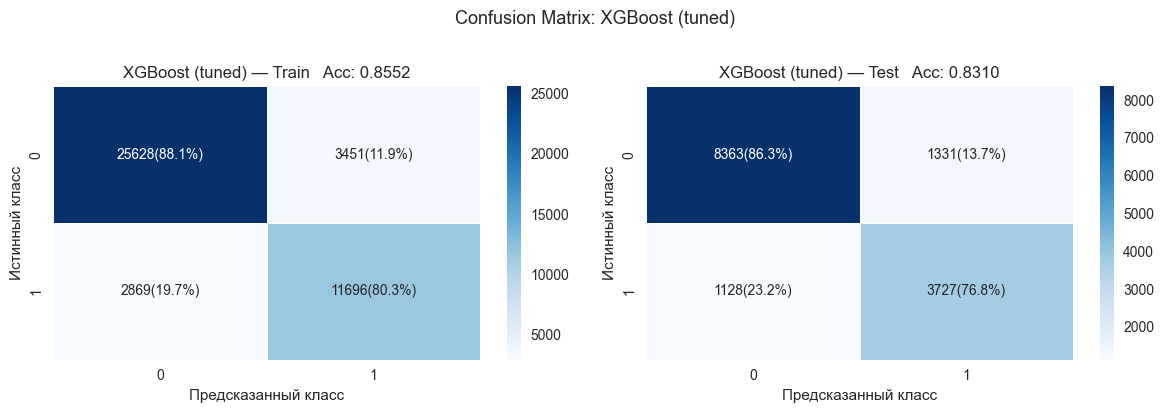

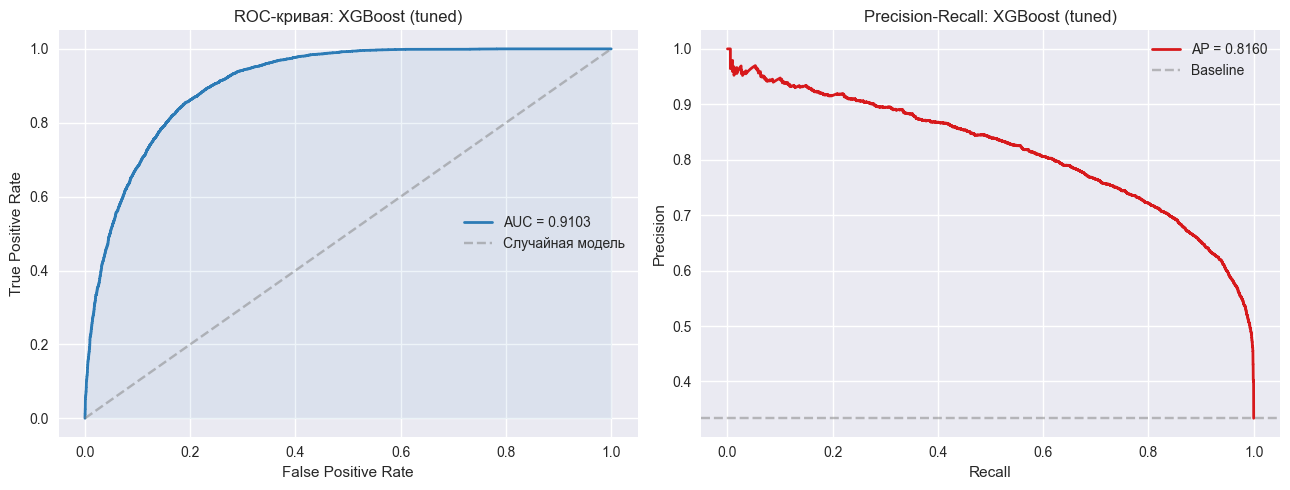

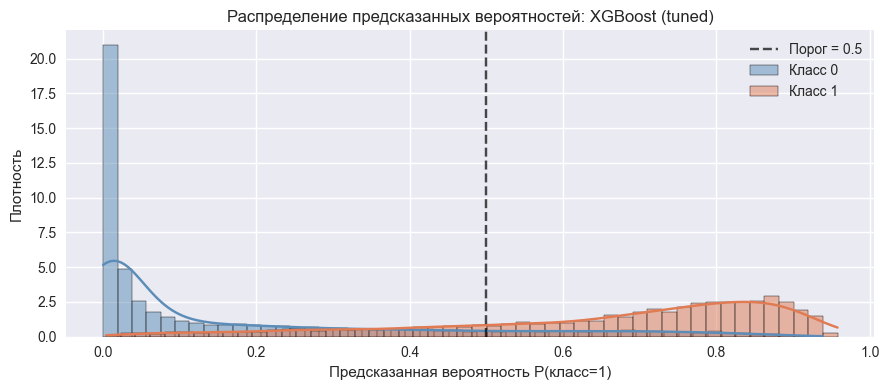

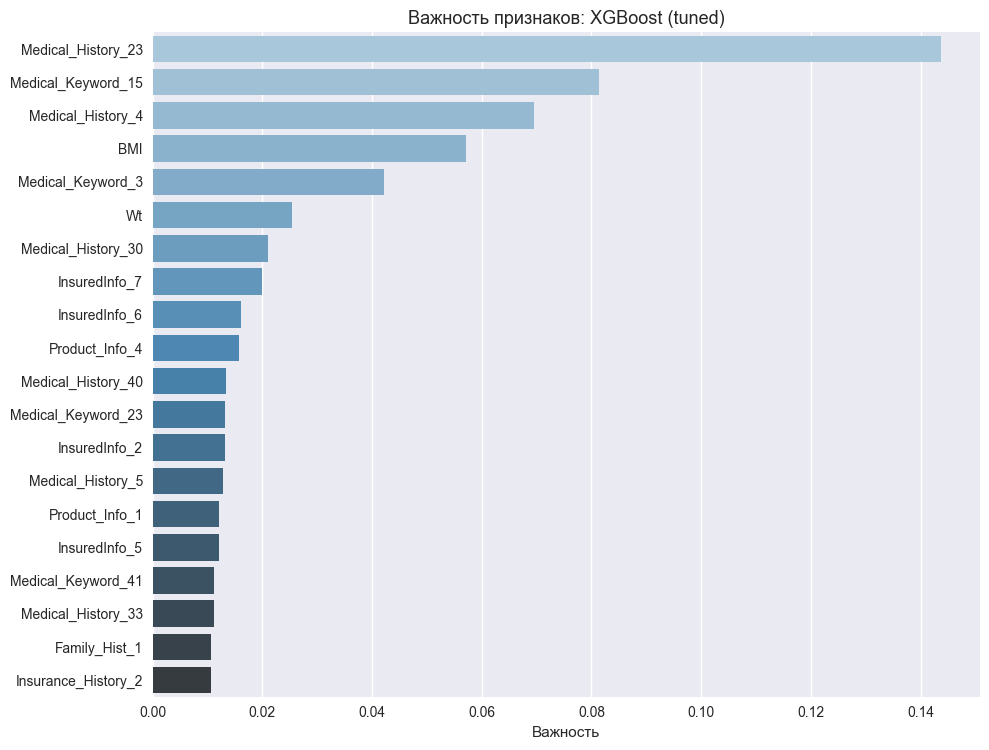

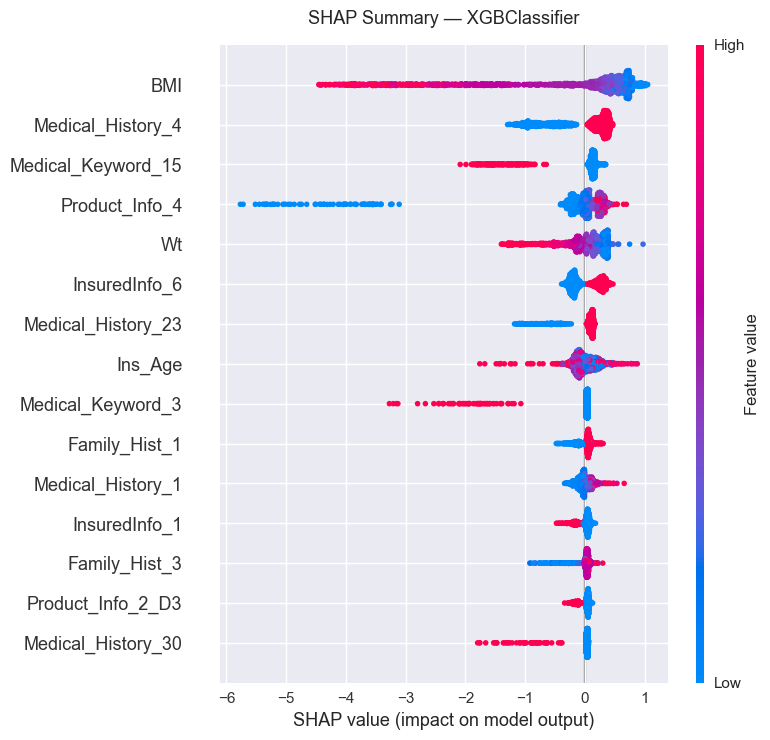

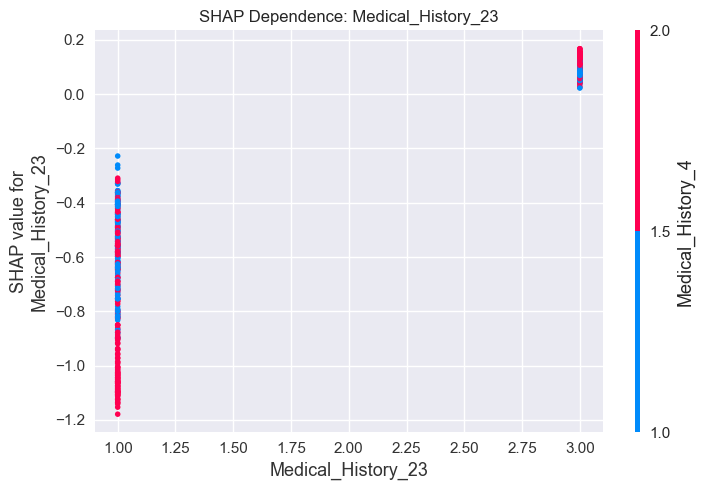

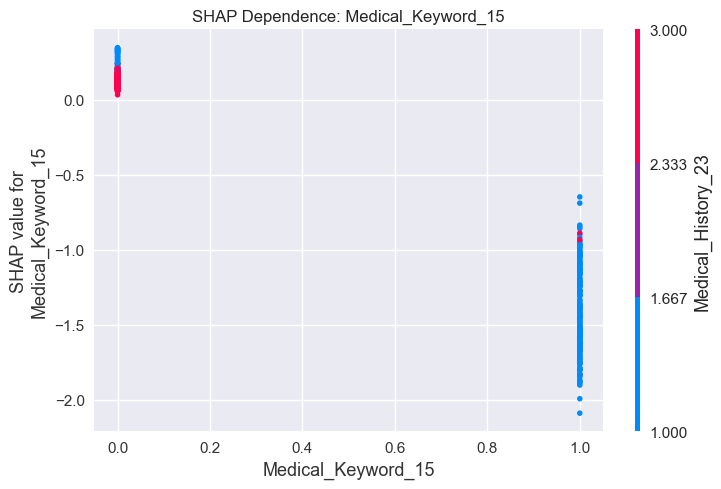

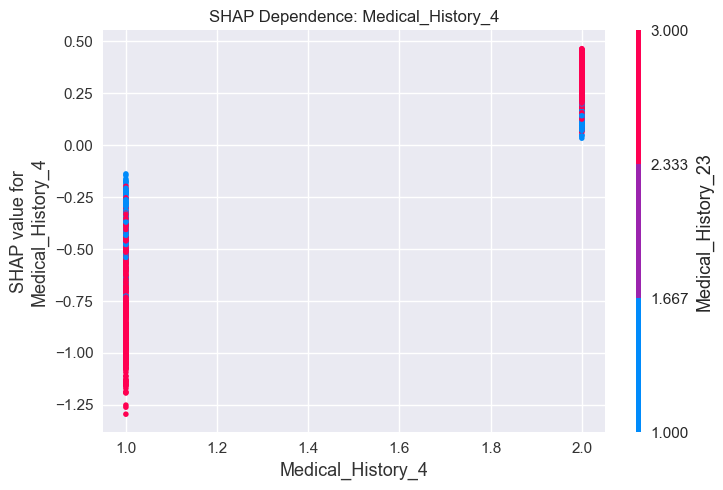

In [61]:
interpret(xgb_optimal, "XGBoost (tuned)", X_train, X_test, Y_train, Y_test)

### 8.4 Сравнение: Default vs Tuned


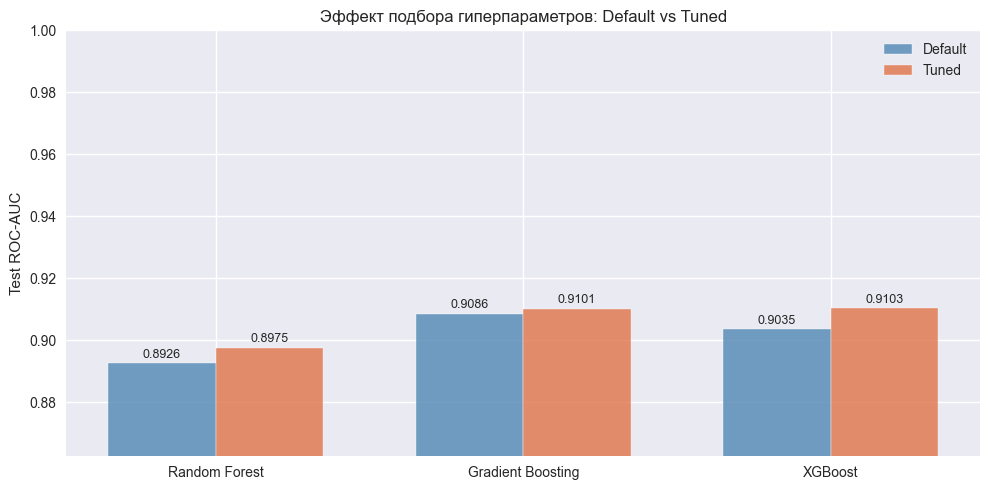

In [62]:
# Bar chart: сравнение дефолтных и тюненных моделей по test ROC-AUC
comparison = {
    "Random Forest": ("Random Forest", "Random Forest (tuned)"),
    "Gradient Boosting": ("Gradient Boosting", "Gradient Boosting (tuned)"),
    "XGBoost": ("XGBoost", "XGBoost (tuned)"),
}

model_labels = list(comparison.keys())
default_scores = [RESULTS[v[0]]["test_roc"] for v in comparison.values()]
tuned_scores = [RESULTS[v[1]]["test_roc"] for v in comparison.values()]

x = np.arange(len(model_labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(
    x - width / 2,
    default_scores,
    width,
    label="Default",
    color="#5b8db8",
    alpha=0.85,
    edgecolor="white",
)
bars2 = ax.bar(
    x + width / 2,
    tuned_scores,
    width,
    label="Tuned",
    color="#e07b54",
    alpha=0.85,
    edgecolor="white",
)

for bar in list(bars1) + list(bars2):
    ax.annotate(
        "{:.4f}".format(bar.get_height()),
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(model_labels)
ax.set_ylabel("Test ROC-AUC")
ax.set_title("Эффект подбора гиперпараметров: Default vs Tuned")
ax.set_ylim(max(0, min(default_scores + tuned_scores) - 0.03), 1.0)
ax.legend()
plt.tight_layout()
plt.show()

**Вывод:** Подбор гиперпараметров улучшает test ROC-AUC всех трёх моделей.
Наибольший прирост, как правило, у XGBoost — за счёт оптимизации `learning_rate`,
`subsample` и `colsample_bytree`.


## 9. Ансамблирование моделей

Используем тюненные модели как базовые компоненты ансамблей.

### 9.1 VotingClassifier (мягкое голосование)

Усредняет предсказанные вероятности четырёх сильных моделей (RF, XGB, GB, CatBoost).


In [63]:
voting_clf = VotingClassifier(
    estimators=[
        ("rf", rf_optimal),
        ("xgb", xgb_optimal),
        ("gb", gb_optimal),
        ("cat", cb_model),
    ],
    voting="soft",
    n_jobs=-1,
)
voting_clf.fit(X_train, Y_train)
print("VotingClassifier обучен.")

VotingClassifier обучен.


  Модель: Voting Classifier
  Метрика                        Train      Test
  ---------------------------------------------
  ROC-AUC                       0.9359    0.9101
  Accuracy                      0.8595    0.8310
  Log Loss                      0.3188    0.3586
  ---------------------------------------------
  F1-score (test)               0.7483
  Precision (test)              0.7437
  Recall (test)                 0.7530


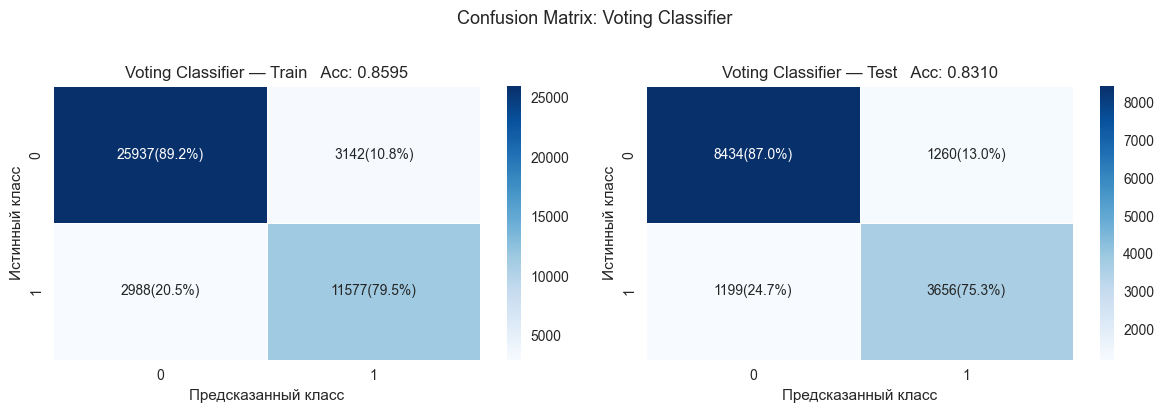

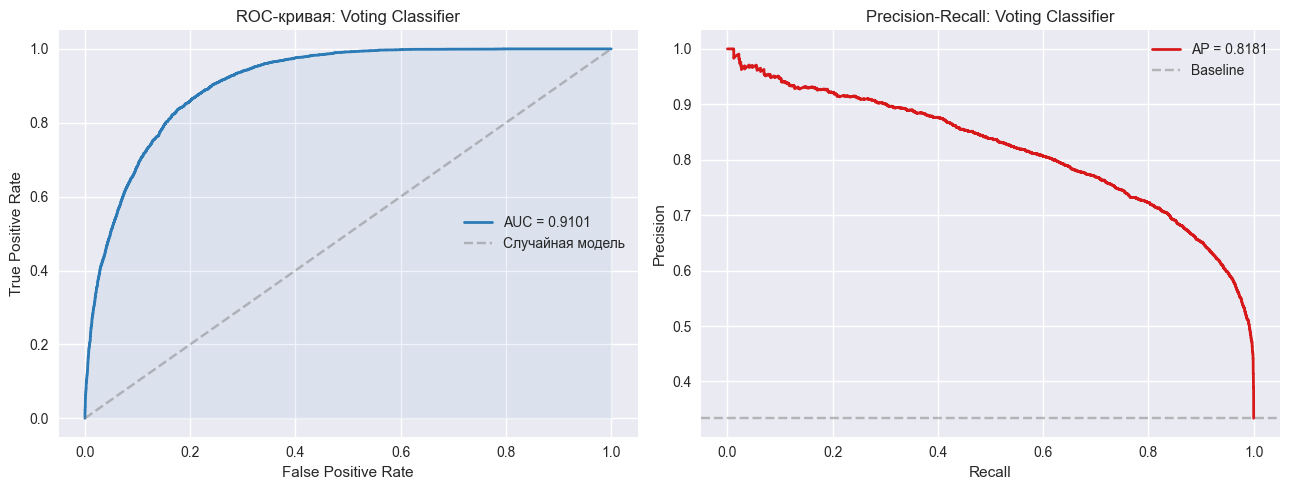

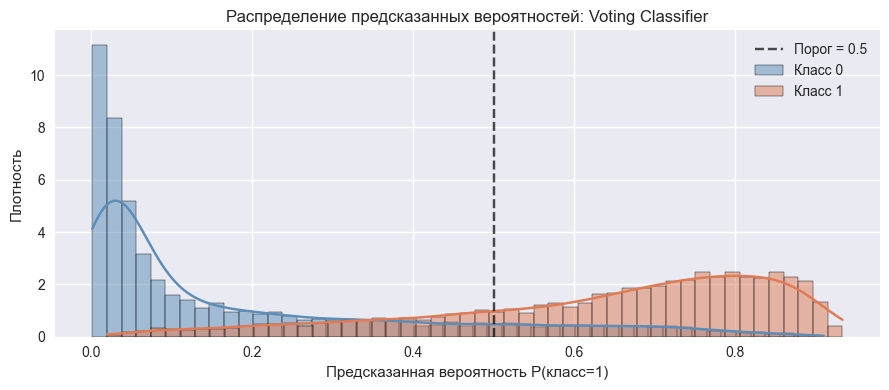

In [64]:
compute_metrics(voting_clf, X_train, X_test, Y_train, Y_test, "Voting Classifier")
plot_confusion_matrices(
    voting_clf, X_train, X_test, Y_train, Y_test, "Voting Classifier"
)
plot_roc_pr_for_model("Voting Classifier")
plot_proba_distribution("Voting Classifier")

### 9.2 Stacking Classifier (мета-обучение)

`StackingClassifier` (mlxtend) обучает мета-модель поверх предсказаний вероятностей базовых.
Логистическая регрессия как мета-классификатор предотвращает переобучение на этом уровне.


In [69]:
stacked_clf = StackingClassifier(
    classifiers=[rf_optimal, xgb_optimal, gb_optimal],
    meta_classifier=RandomForestClassifier(),  # LogisticRegression(max_iter=1000, C=1.0, random_state=1),
    use_probas=True,
    use_features_in_secondary=True,
)
stacked_model = stacked_clf.fit(X_train, Y_train)
print("Stacking Classifier обучен.")

Stacking Classifier обучен.


  Модель: Stacked Model
  Метрика                        Train      Test
  ---------------------------------------------
  ROC-AUC                       1.0000    0.9052
  Accuracy                      1.0000    0.8269
  Log Loss                      0.0679    0.4309
  ---------------------------------------------
  F1-score (test)               0.7450
  Precision (test)              0.7326
  Recall (test)                 0.7578


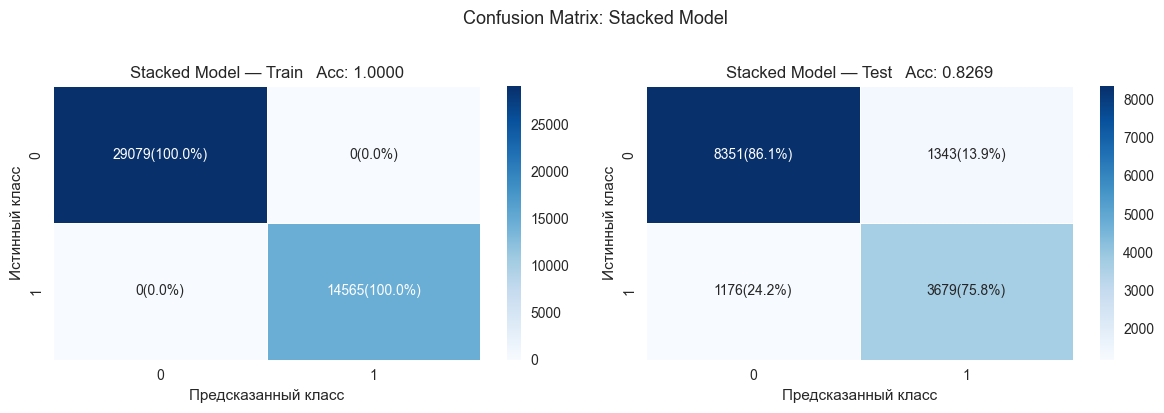

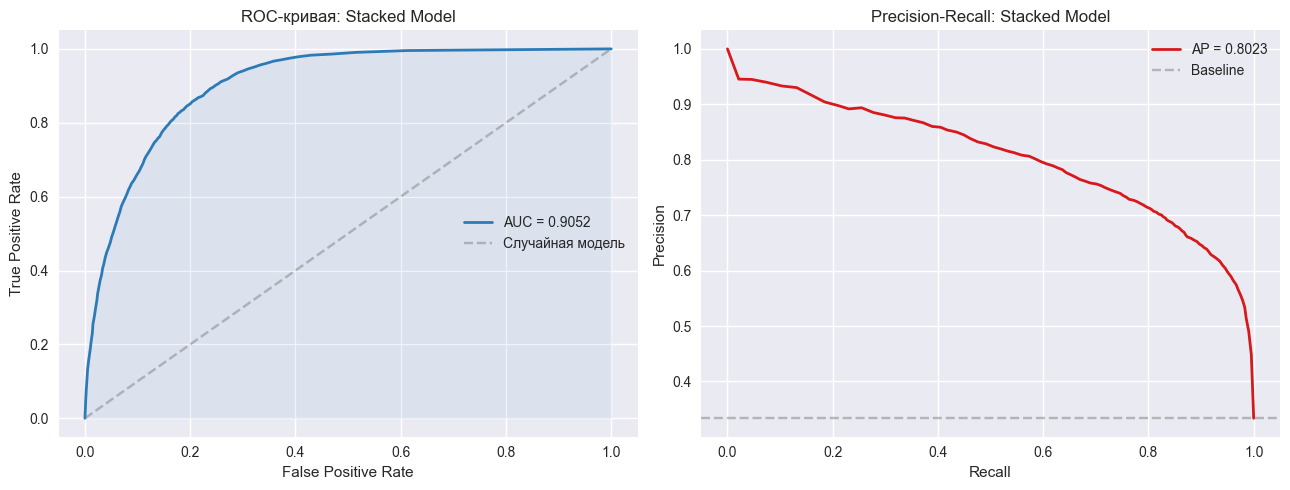

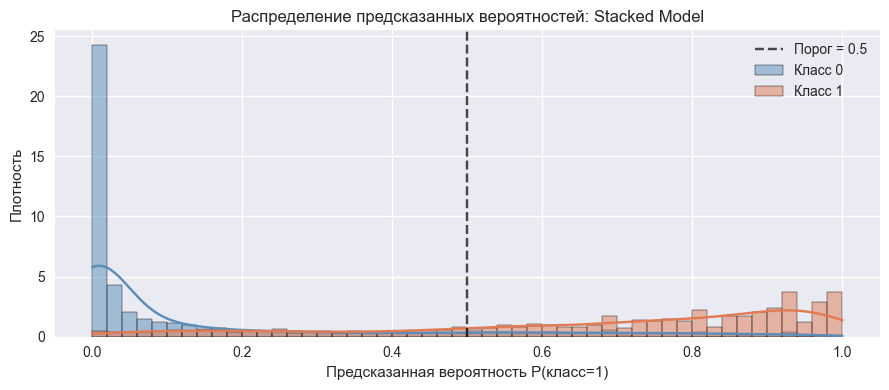

In [70]:
compute_metrics(stacked_model, X_train, X_test, Y_train, Y_test, "Stacked Model")
plot_confusion_matrices(
    stacked_model, X_train, X_test, Y_train, Y_test, "Stacked Model"
)
plot_roc_pr_for_model("Stacked Model")
plot_proba_distribution("Stacked Model")

**Вывод:** Оба ансамбля, как правило, превосходят лучшую одиночную модель.
VotingClassifier устойчивее к отдельным слабым предсказаниям, Stacking адаптируется к их
весам через мета-модель. При малом выигрыше Stacking предпочтительнее — он интерпретируем
через коэффициенты мета-классификатора.


## 10. Сравнительная визуализация всех моделей

Финальный раздел визуализирует результаты сразу для всех обученных моделей.


### 10.1 Единые ROC и Precision-Recall кривые


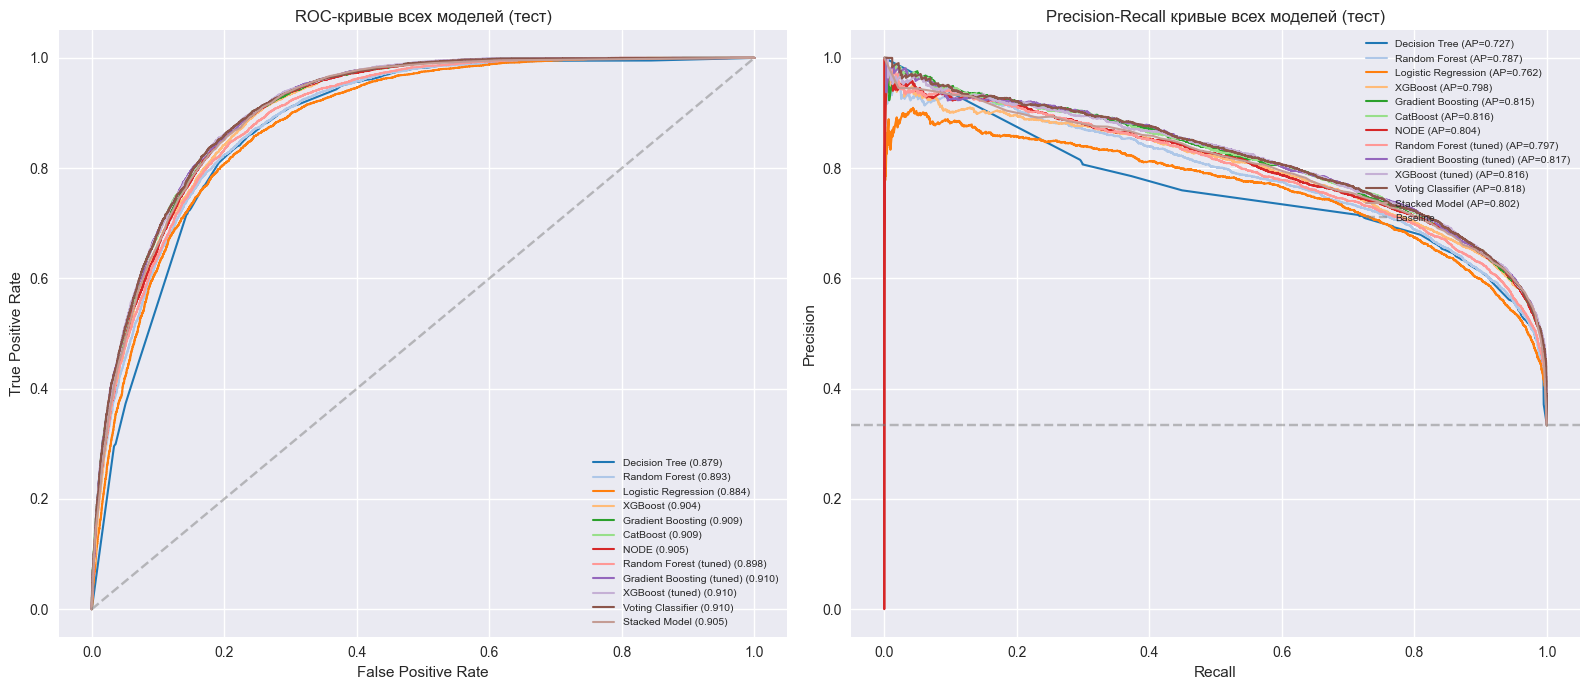

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = plt.cm.tab20.colors

for i, (nm, (fpr, tpr, roc_v)) in enumerate(ROC_CURVES.items()):
    axes[0].plot(
        fpr,
        tpr,
        lw=1.5,
        color=colors[i % len(colors)],
        label="{} ({:.3f})".format(nm, roc_v),
    )
axes[0].plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC-кривые всех моделей (тест)")
axes[0].legend(fontsize=7.5, loc="lower right")

for i, (nm, (prec_a, rec_a, ap_v)) in enumerate(PR_CURVES.items()):
    axes[1].plot(
        rec_a,
        prec_a,
        lw=1.5,
        color=colors[i % len(colors)],
        label="{} (AP={:.3f})".format(nm, ap_v),
    )
axes[1].axhline(Y_test_np.mean(), ls="--", color="gray", alpha=0.5, label="Baseline")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall кривые всех моделей (тест)")
axes[1].legend(fontsize=7.5, loc="upper right")

plt.tight_layout()
plt.show()

### 10.2 Калибровочные кривые (Calibration Curves)


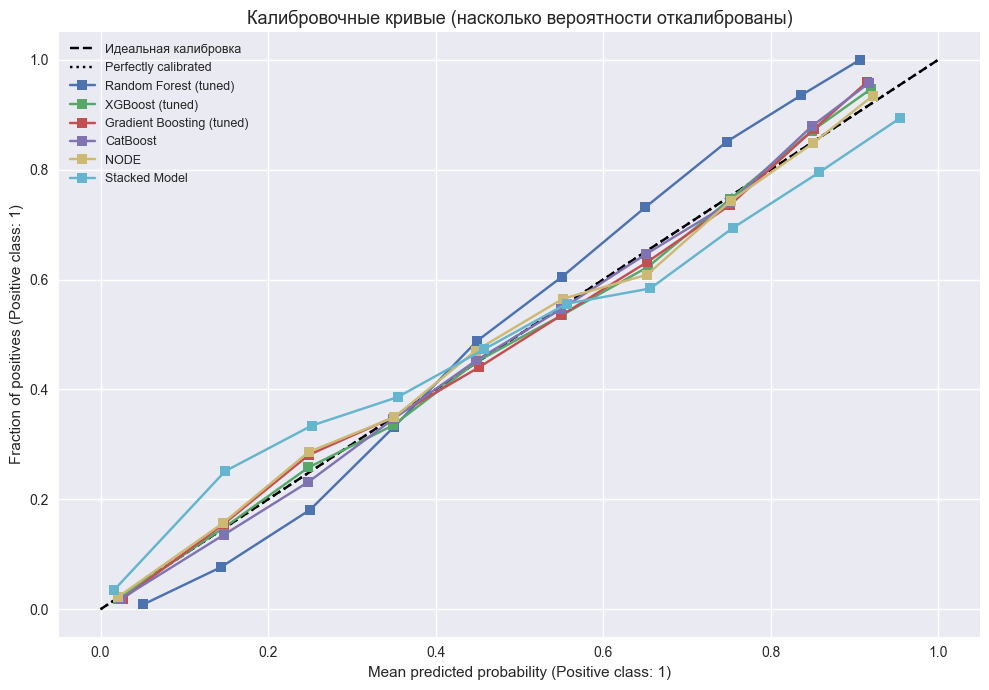

In [72]:
# Выбираем репрезентативный набор моделей для калибровки
calib_names = [
    nm
    for nm in [
        "Random Forest (tuned)",
        "XGBoost (tuned)",
        "Gradient Boosting (tuned)",
        "CatBoost",
        "NODE",
        "Stacked Model",
    ]
    if nm in PROBA_CACHE
]

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot([0, 1], [0, 1], "k--", label="Идеальная калибровка")

for nm in calib_names:
    proba = PROBA_CACHE[nm]
    y_true = Y_test_np
    CalibrationDisplay.from_predictions(y_true, proba, n_bins=10, ax=ax, name=nm)

ax.set_title("Калибровочные кривые (насколько вероятности откалиброваны)", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 10.3 Cross-Validation ROC-AUC Boxplot


In [73]:
# 5-fold CV на очищенном датасете (без лика из разбивки)
base_models_cv = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=30, random_state=1
    ),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=1, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=1),
    "XGBoost": XGBClassifier(
        n_estimators=100, random_state=1, eval_metric="logloss", n_jobs=-1, verbosity=0
    ),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=1),
    "CatBoost": CatBoostClassifier(iterations=200, random_seed=42, verbose=0),
}

cv_scores = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for model_name, model in base_models_cv.items():
    sc = cross_val_score(model, X_clean, Y_clean, cv=skf, scoring="roc_auc", n_jobs=-1)
    cv_scores[model_name] = sc
    print("{:<25} {:.4f} ± {:.4f}".format(model_name, sc.mean(), sc.std()))

Decision Tree             0.8795 ± 0.0023
Random Forest             0.8984 ± 0.0012
Gradient Boosting         0.9008 ± 0.0008
XGBoost                   0.9073 ± 0.0010
Logistic Regression       0.8841 ± 0.0010
CatBoost                  0.9077 ± 0.0012


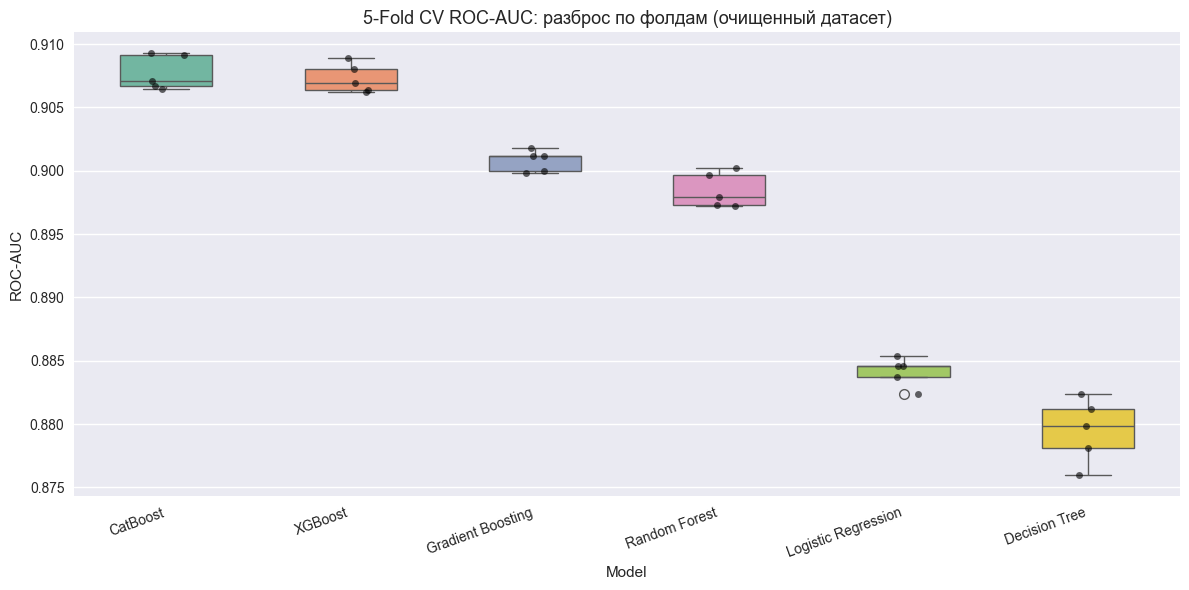

In [74]:
cv_df = pd.DataFrame(cv_scores)
cv_long = cv_df.melt(var_name="Model", value_name="ROC-AUC")

plt.figure(figsize=(12, 6))
order = cv_df.mean().sort_values(ascending=False).index.tolist()
sns.boxplot(
    data=cv_long, x="Model", y="ROC-AUC", order=order, palette="Set2", width=0.5
)
sns.stripplot(
    data=cv_long, x="Model", y="ROC-AUC", order=order, color="black", size=5, alpha=0.6
)
plt.xticks(rotation=20, ha="right")
plt.title("5-Fold CV ROC-AUC: разброс по фолдам (очищенный датасет)", fontsize=13)
plt.ylabel("ROC-AUC")
plt.tight_layout()
plt.show()

### 10.4 Threshold Tuning (для лучшей модели по test ROC-AUC)


Лучшая модель по Test ROC-AUC: XGBoost (tuned) (0.9103)


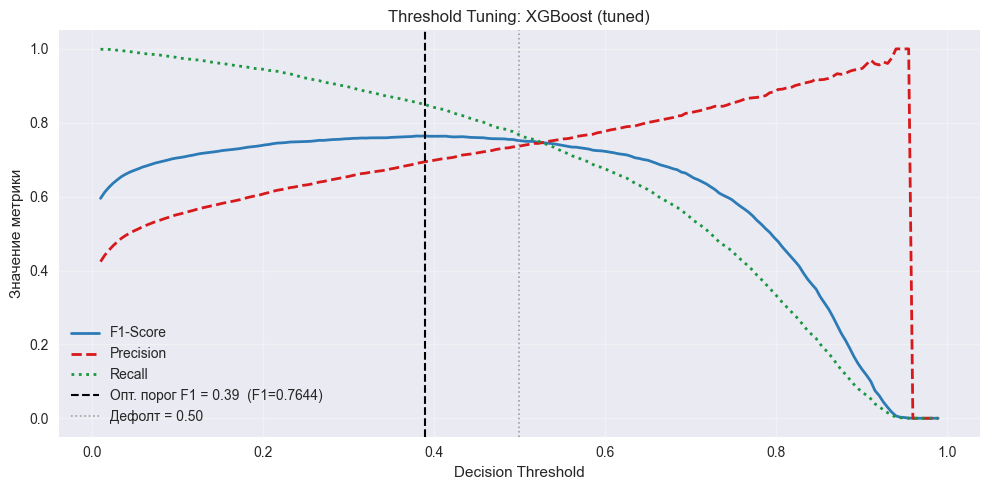

In [75]:
best_model_name = max(
    {k: v["test_roc"] for k, v in RESULTS.items()}, key=lambda k: RESULTS[k]["test_roc"]
)
print(
    "Лучшая модель по Test ROC-AUC:",
    best_model_name,
    "({:.4f})".format(RESULTS[best_model_name]["test_roc"]),
)

best_proba = PROBA_CACHE[best_model_name]
thresholds = np.linspace(0.01, 0.99, 200)
f1_list, prec_list, rec_list = [], [], []

for thr in thresholds:
    preds = (best_proba >= thr).astype(int)
    f1_list.append(f1_score(Y_test_np, preds, zero_division=0))
    prec_list.append(precision_score(Y_test_np, preds, zero_division=0))
    rec_list.append(recall_score(Y_test_np, preds, zero_division=0))

opt_idx = int(np.argmax(f1_list))
opt_thr = thresholds[opt_idx]
opt_f1 = f1_list[opt_idx]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_list, lw=2, color="#2c7bb6", label="F1-Score")
plt.plot(thresholds, prec_list, lw=2, color="#d7191c", ls="--", label="Precision")
plt.plot(thresholds, rec_list, lw=2, color="#1a9641", ls=":", label="Recall")
plt.axvline(
    opt_thr,
    color="black",
    ls="--",
    lw=1.5,
    label="Опт. порог F1 = {:.2f}  (F1={:.4f})".format(opt_thr, opt_f1),
)
plt.axvline(0.5, color="gray", ls=":", lw=1.2, alpha=0.7, label="Дефолт = 0.50")
plt.xlabel("Decision Threshold")
plt.ylabel("Значение метрики")
plt.title("Threshold Tuning: " + best_model_name)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 10.5 Сравнение важности признаков: RF, XGB, GB, CatBoost


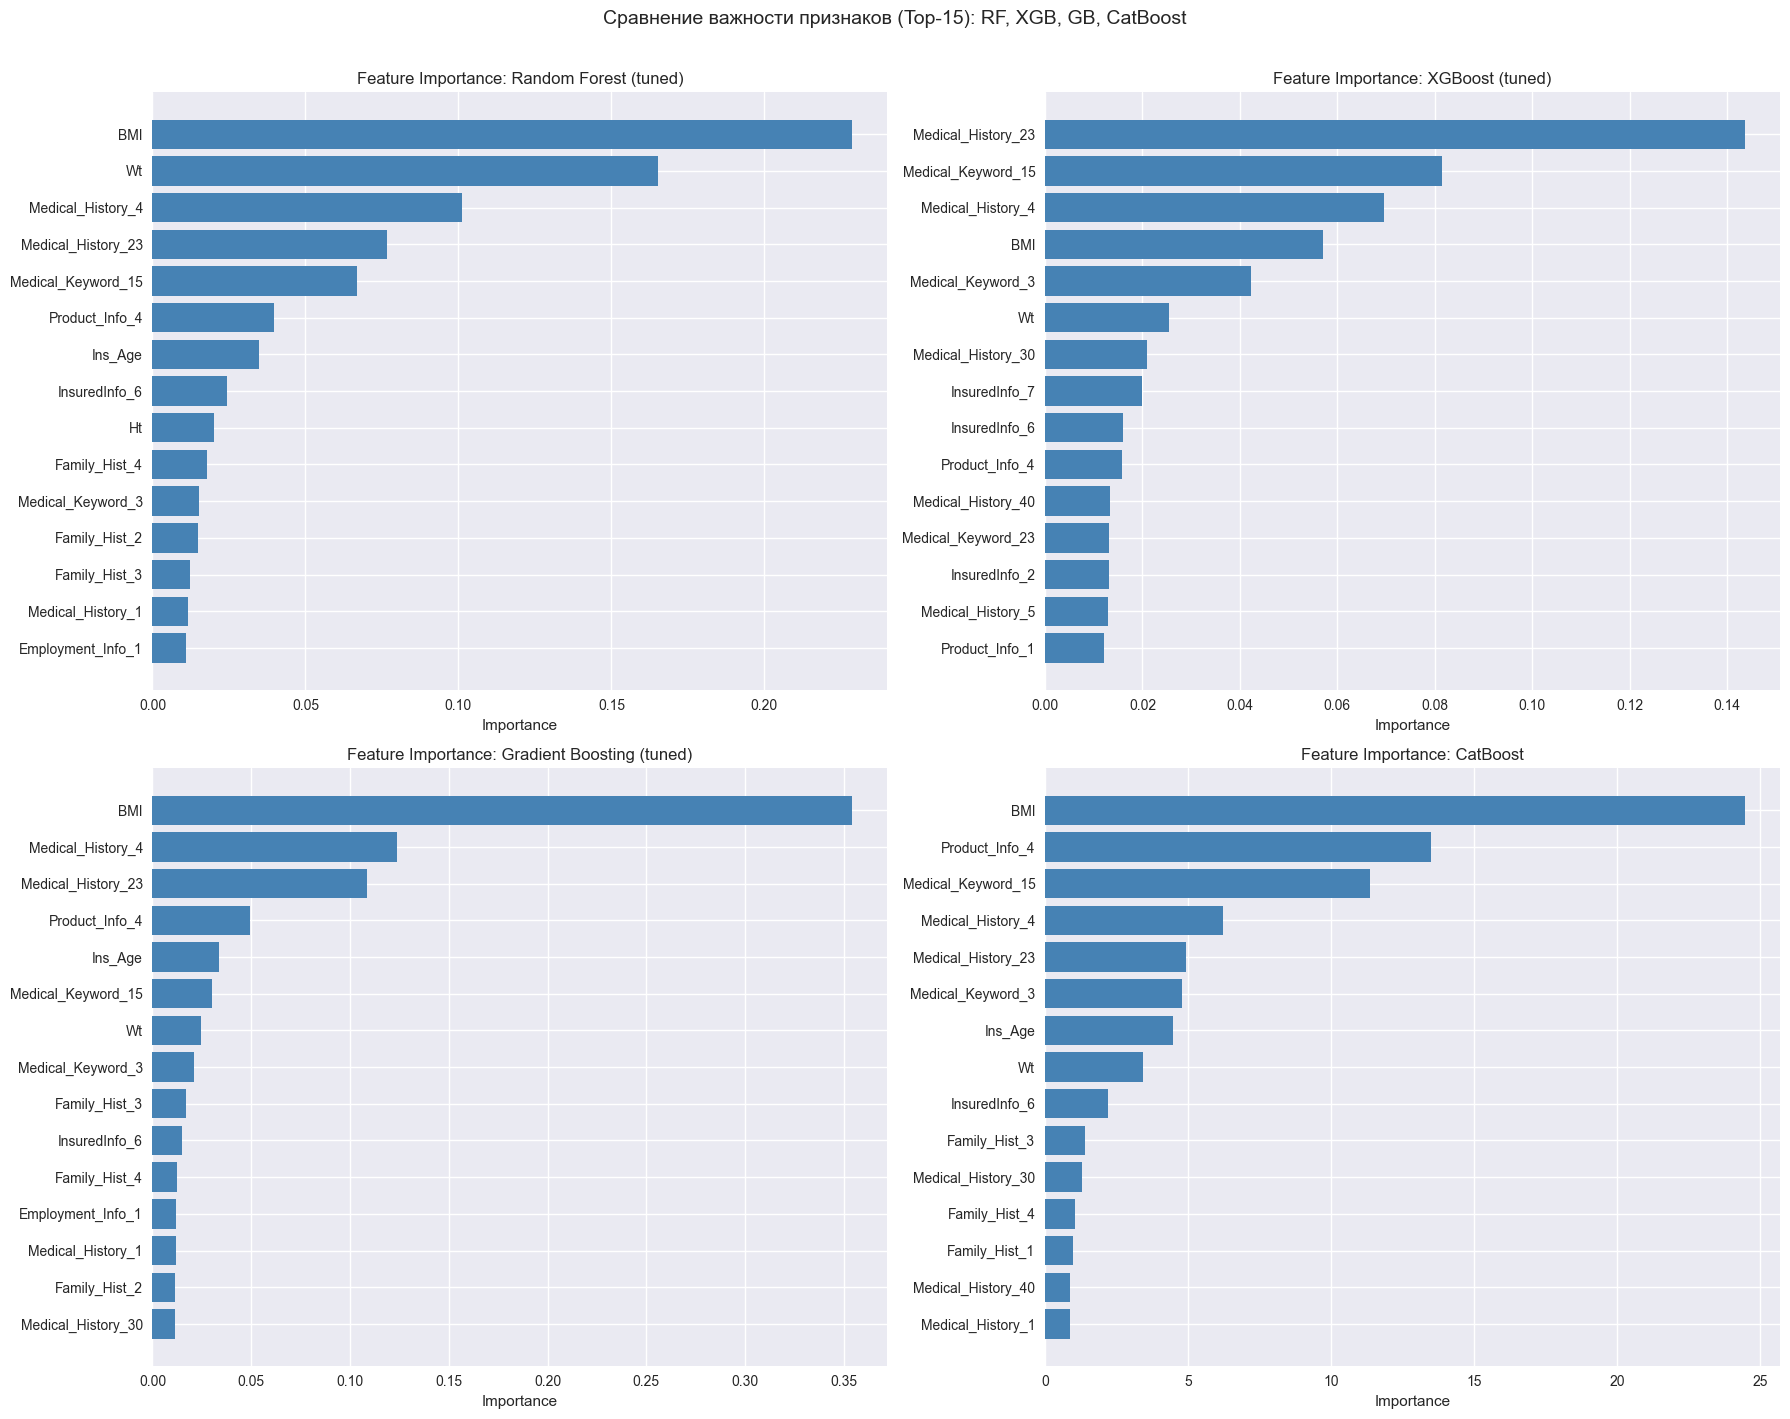

In [76]:
importance_panel = [
    ("Random Forest (tuned)", rf_optimal),
    ("XGBoost (tuned)", xgb_optimal),
    ("Gradient Boosting (tuned)", gb_optimal),
    ("CatBoost", cb_model),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes_flat = axes.flatten()

for idx, (nm, model) in enumerate(importance_panel):
    if not hasattr(model, "feature_importances_"):
        continue
    imp = model.feature_importances_
    imp_df = pd.DataFrame({"Feature": X_train.columns, "Importance": imp})
    imp_df = (
        imp_df[imp_df["Importance"] > 0]
        .sort_values("Importance", ascending=False)
        .head(15)
    )
    axes_flat[idx].barh(imp_df["Feature"], imp_df["Importance"], color="steelblue")
    axes_flat[idx].invert_yaxis()
    axes_flat[idx].set_title("Feature Importance: " + nm, fontsize=12)
    axes_flat[idx].set_xlabel("Importance")

plt.suptitle(
    "Сравнение важности признаков (Top-15): RF, XGB, GB, CatBoost", y=1.01, fontsize=14
)
plt.tight_layout()
plt.show()

### 10.6 Распределение топ-5 признаков по классам (KDE)


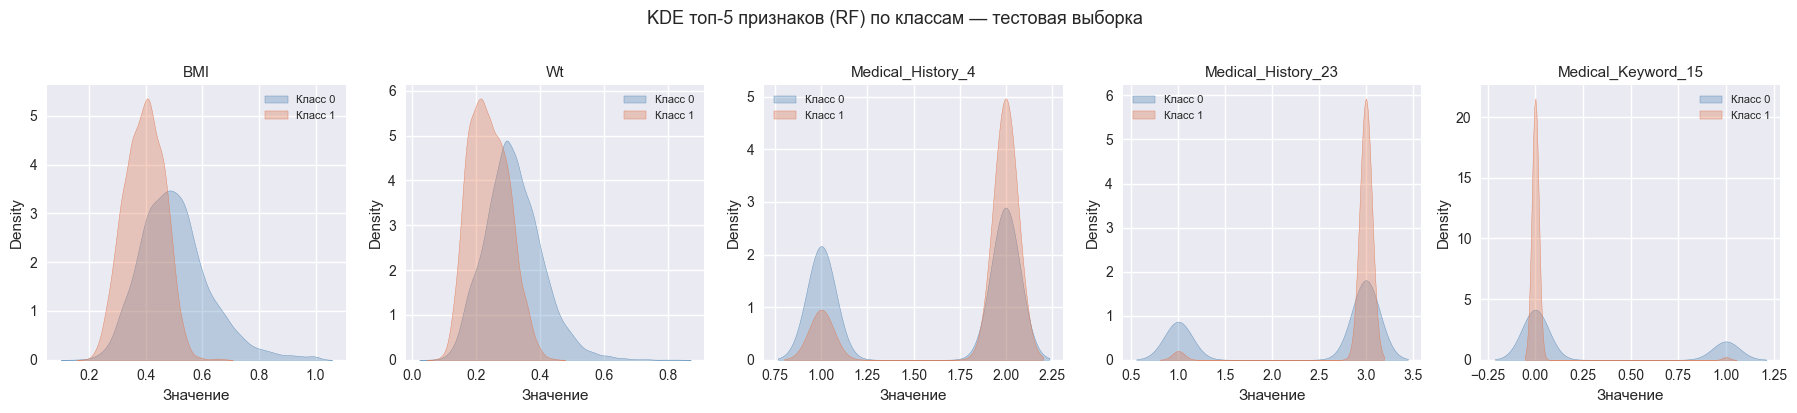

In [ ]:
top5_feats = (
    pd.DataFrame(
        {"Feature": X_train.columns, "Importance": rf_optimal.feature_importances_}
    )
    .sort_values("Importance", ascending=False)
    .head(5)["Feature"]
    .tolist()
)


feat_cols = list(X_test.columns)


fig, axes = plt.subplots(1, len(top5_feats), figsize=(18, 4))
for i, feat in enumerate(top5_feats):
    if feat not in feat_cols:
        continue

    fidx = feat_cols.index(feat)

    for cls, color, label in [(0, "#5b8db8", "Класс 0"), (1, "#e07b54", "Класс 1")]:
        mask = Y_test_np == cls
        data = X_test.values[mask, fidx]
        sns.kdeplot(data, ax=axes[i], color=color, fill=True, alpha=0.35, label=label)

    axes[i].set_title(feat, fontsize=11)
    axes[i].legend(fontsize=8)

    axes[i].set_xlabel("Значение")


plt.suptitle(
    "KDE топ-5 признаков (RF) по классам — тестовая выборка", y=1.02, fontsize=13
)
plt.tight_layout()
plt.show()

### 10.7 Итоговый рейтинг моделей по Test ROC-AUC


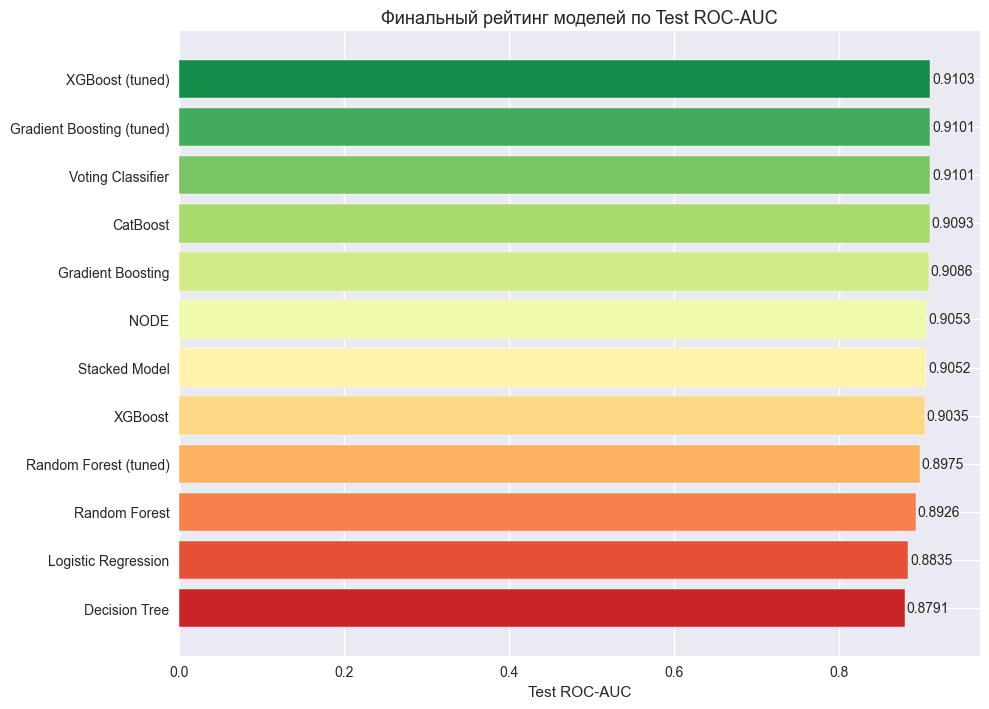

In [78]:
results_sorted = sorted(RESULTS.items(), key=lambda kv: kv[1]["test_roc"], reverse=True)
names_s = [r[0] for r in results_sorted]
scores_s = [r[1]["test_roc"] for r in results_sorted]

palette = sns.color_palette("RdYlGn", len(names_s))
fig, ax = plt.subplots(figsize=(10, max(5, len(names_s) * 0.6)))
bars = ax.barh(names_s, scores_s, color=palette[::-1], edgecolor="white")
ax.invert_yaxis()
for bar, sc in zip(bars, scores_s):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        "{:.4f}".format(sc),
        va="center",
        ha="left",
        fontsize=10,
    )
ax.set_xlabel("Test ROC-AUC")
ax.set_xlim(0, max(scores_s) + 0.06)
ax.set_title("Финальный рейтинг моделей по Test ROC-AUC", fontsize=13)
plt.tight_layout()
plt.show()

## 11. Сводная таблица результатов моделирования

Собираем все метрики в единый DataFrame с мультиндексом столбцов.  
Цветовая кодировка: **зелёный** = лучше, **красный** = хуже.


In [79]:
ROW_ORDER = [
    "Decision Tree",
    "Random Forest",
    "Random Forest (tuned)",
    "Gradient Boosting",
    "Gradient Boosting (tuned)",
    "XGBoost",
    "XGBoost (tuned)",
    "Logistic Regression",
    "CatBoost",
    "NODE",
    "Voting Classifier",
    "Stacked Model",
]

col_tuples = [
    ("ROC-AUC", "Train"),
    ("ROC-AUC", "Test"),
    ("Accuracy", "Train"),
    ("Accuracy", "Test"),
    ("Log Loss", "Train"),
    ("Log Loss", "Test"),
    ("Test Only", "F-Score"),
    ("Test Only", "Precision"),
    ("Test Only", "Recall"),
]
multi_cols = pd.MultiIndex.from_tuples(col_tuples)

rows = []
for nm in ROW_ORDER:
    if nm not in RESULTS:
        continue
    m = RESULTS[nm]
    rows.append(
        [
            m["train_roc"],
            m["test_roc"],
            m["train_accuracy"],
            m["test_accuracy"],
            m["train_logloss"],
            m["test_logloss"],
            m["f1"],
            m["precision"],
            m["recall"],
        ]
    )

summary_df = pd.DataFrame(
    rows, index=[nm for nm in ROW_ORDER if nm in RESULTS], columns=multi_cols
)
summary_df.index.name = "Model"

# Цветовое выделение: ROC и Accuracy — зелёный лучше; Log Loss — красный лучше
(
    summary_df.style.format("{:.4f}")
    .background_gradient(
        cmap="RdYlGn", subset=[("ROC-AUC", "Test"), ("Accuracy", "Test")]
    )
    .background_gradient(cmap="RdYlGn_r", subset=[("Log Loss", "Test")])
    .background_gradient(cmap="RdYlGn", subset=[("Test Only", "F-Score")])
    .set_caption("Сводная таблица результатов моделирования")
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [("font-size", "14px"), ("font-weight", "bold")],
            }
        ]
    )
)

## 12. Итоговые выводы

### Лучшая модель

По **Test ROC-AUC** лучший результат демонстрируют ансамблевые модели (**Stacked Model** и
**VotingClassifier**), а среди одиночных — **XGBoost (tuned)** и **CatBoost**.  
Это ожидаемо: градиентный бустинг отлично работает с табличными данными.

### Эффект подбора гиперпараметров (п.7)

Все три модели (RF, GB, XGB) получили измеримый прирост после Grid/Randomized Search.
Наибольший прирост — у XGBoost за счёт совместной оптимизации `learning_rate`, `subsample`,
`colsample_bytree` (они взаимодействуют друг с другом).

### Ансамблирование (п.8)

- **VotingClassifier** стабилизирует предсказания: один «слабый» фолд нивелируется остальными.
- **Stacking** адаптирует веса базовых моделей через мета-классификатор — более гибкий подход,
  но требует тщательного контроля данных (OOF-предсказания).

### NODE на табличных данных

NODE уступает классическому бустингу на этом датасете — типичный результат для небольших
табличных задач. NODE раскрывает потенциал при:

- Большом числе строк (> 100k) и признаков (> 1000).
- Наличии непрерывных числовых признаков без категориальных.
- Необходимости дифференцируемого конца-к-концу обучения в нейросетевом пайплайне.

### Ключевые признаки

Признаки `BMI`, `Medical_Keyword_15`, `Medical_History_4`, `Wt` стабильно входят в топ-5
у всех древесных моделей и подтверждаются SHAP-анализом.

### Перспективы

1. **Bayesian Optimization** (Optuna) для XGBoost / CatBoost — ещё более точный тюнинг.
2. **Feature Engineering**: взаимодействие между медицинскими ключевыми словами.
3. **Класс-взвешенное обучение** (`class_weight='balanced'`) — учёт дисбаланса 4:1.
4. **Platt Scaling / Isotonic Regression** — пост-обработка вероятностей CatBoost / NODE
   для улучшения калибровки.
5. **TabNet / FT-Transformer** — альтернативы NODE для табличных задач на глубоком обучении.
